# การวิเคราะห์ภาพรวมการจัดซื้อจัดจ้างภาครัฐ

Notebook ฉบับ Clean สำหรับวิเคราะห์ข้อมูลหลายปี โดยคงตรรกะการคำนวณ ตาราง และกราฟเดิมไว้

> วิธีใช้กับปีอื่น: เปลี่ยนค่า `YEAR` ในเซลล์ **SETUP** ด้านล่างเพียงจุดเดียว เช่น `2568` หรือ `2569` แล้วเลือก **Runtime → Run all** ใน Google Colab


> **ผลลัพธ์ตัวอย่าง:** รูปและตารางด้านล่างมาจากไฟล์ที่ผู้จัดทำรันบน Google Colab และส่งมาใน `notebook_with_results` สามารถเปิดดูได้โดยไม่ต้องรันใหม่ โค้ดคำนวณยังคงเดิม ผลเมื่อรันใหม่ขึ้นกับข้อมูลและการตั้งค่าที่ใช้
> **ไฟล์นี้ยังมีผลลัพธ์ไม่ครบ:** ผลที่บันทึกไว้เป็นปี 2569 มีกราฟ 7 รูป ช่วงแผนที่รายจังหวัดและเซลล์ถัดไปยังไม่มีกราฟบันทึกไว้ กรุณารันต่อใน Colab หากต้องการผลช่วงท้าย


## วิธีรันเวอร์ชัน GitHub

เปิด Notebook นี้ใน Google Colab แล้วเลือก **Runtime → Run all** ข้อมูลจะอ่านจาก [data_for_github](https://drive.google.com/drive/folders/1ssVrUcY4TiYee9T2B0pwgr5SwvPp_lAq) โดยดาวน์โหลดเฉพาะไฟล์ที่ใช้ลงพื้นที่ชั่วคราวของ Runtime ไม่ต้องตั้งโฟลเดอร์ผลลัพธ์หรือเชื่อม Drive ส่วนตัว

- กราฟและตารางแสดงใน Notebook ไม่มีการส่งออก CSV/PNG/SVG ไปยัง Drive หรือเครื่องของผู้อ่าน
- ไฟล์ข้อมูล ฟอนต์ แผนที่ และ CSV พักที่จำเป็นอยู่ใน Runtime เท่านั้น เซลล์สุดท้ายลบไฟล์พักและเก็บ DataFrame ไว้ให้วิเคราะห์ต่อ หากหยุดกลางทางให้รัน `cleanup_runtime()` เมื่อไม่ต้องใช้ไฟล์พักแล้ว
- รันแต่ละ Notebook ใน Runtime แยกกันเพื่อลด RAM; หาก RAM ใช้ถึง 80% โค้ดจะหยุดพร้อมคำแนะนำ แทนการฝืนประมวลผล
- กรณี Drive จำกัดการดาวน์โหลด ให้ดาวน์โหลดข้อมูลเองและระบุ `LOCAL_DATA_DIR` ในเซลล์ตั้งค่า
- สูตร เกณฑ์ ตัวกรอง และลำดับข้อมูลคงตามไฟล์ต้นฉบับ อ่านข้อแตกต่างระหว่าง Notebook และรายการไฟล์ใน [DATA_FILES.md](../DATA_FILES.md)

ผลลัพธ์เดิมที่ฝังในไฟล์ถูกล้างเพื่อให้ผู้อ่านเห็นผลจากการรันครั้งใหม่


In [4]:
# GitHub / Colab: ดาวน์โหลดข้อมูลเฉพาะที่ใช้ลงพื้นที่ชั่วคราว ไม่ต้อง Mount Drive
# เปลี่ยนเป็น Path โฟลเดอร์ข้อมูลที่มีอยู่แล้วได้ เพื่อไม่ต้องดาวน์โหลดซ้ำ
LOCAL_DATA_DIR = None
import atexit
import gc
import hashlib
import importlib.util
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

# ติดตั้งเฉพาะแพ็กเกจที่ยังไม่มี; subprocess นี้รอจนจบ ไม่มี worker ค้าง
_packages = {"pandas": "pandas>=2.2,<3", "numpy": "numpy", "matplotlib": "matplotlib", "seaborn": "seaborn", "geopandas": "geopandas", "psutil": "psutil", "gdown": "gdown", "IPython": "ipython"}
_missing_packages = [requirement for module, requirement in _packages.items() if importlib.util.find_spec(module) is None]
if _missing_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing_packages], check=True)
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from IPython.display import display

def check_memory(stage="ประมวลผล"):
    # หยุดอย่างชัดเจนเมื่อ RAM สูง แทนการฝืนจน Runtime หลุด
    if psutil.virtual_memory().percent >= 80:
        gc.collect()
        if psutil.virtual_memory().percent >= 80:
            raise MemoryError(f"RAM ใช้เกิน 80% ก่อน {stage}; กรุณา Restart runtime หรือใช้ High-RAM แล้ว Run all ใหม่")

# รัน setup ซ้ำจะปิดพื้นที่ชั่วคราวของ Notebook รอบก่อน
if "_github_runtime" in globals():
    _github_runtime.cleanup()
_github_runtime = tempfile.TemporaryDirectory(prefix="procurement_github_")
atexit.register(_github_runtime.cleanup)
RUNTIME_DIR = Path(_github_runtime.name)
DATA_DIR = RUNTIME_DIR / "inputs"
DATA_DIR.mkdir()
_initial_figure_numbers = set(plt.get_fignums())

DATA_FILES = {
    "07_lower10_project_budget_2567.csv": {
        "id": "1YQpAhUcghJ9gM6eIC6qBZGe6WcVuKyWR",
        "size": 4169
    },
    "07_lower10_project_budget_2568.csv": {
        "id": "1aNYIMOH7Da8VvVhXI1XQigBYRNWk9IHj",
        "size": 5098
    },
    "07_lower10_project_budget_2569.csv": {
        "id": "1tU1V9n2ysJmXxvmnm_SPz7n7Bhbz2B5_",
        "size": 4371
    },
    "07_top10_project_budget_2567.csv": {
        "id": "1bkMYSpLM4UKivKCHe7S8Dsho0BaLgCdJ",
        "size": 5619
    },
    "07_top10_project_budget_2568.csv": {
        "id": "1xsItnomfe9q4A9NYJ5U_lR0764mZMEE4",
        "size": 5682
    },
    "07_top10_project_budget_2569.csv": {
        "id": "1ZwOBFVQkTRAnazjoeXzr3jkpSGFl2bkI",
        "size": 6385
    },
    "2569-egp-contract-1.csv": {
        "id": "1ygmuKsvVjNpjfg0k94Olcuox8efDP3cY",
        "size": 615601896
    },
    "2569-egp-contract-2.csv": {
        "id": "1DUAh8zAtUUV4Hm2yRplCryUOQDFb3Ad8",
        "size": 542097077
    },
    "2569-egp-contract-3.csv": {
        "id": "1fD_6GqtIY7LUempYqId0qIEldcJd2moM",
        "size": 529193616
    },
    "2569-egp-contract-4.csv": {
        "id": "19C4Ak8XNMvm2IBsr7TVpfexZE_1WBke5",
        "size": 526729581
    },
    "2569-egp-contract-5.csv": {
        "id": "1nsV7vqF8Um-QWKX_Q-kEQq6Z1BFDbK_y",
        "size": 521850128
    },
    "2569-egp-contract-6.csv": {
        "id": "1-0zhDZjF2chjeXuPoSVGQWNYtp8fVIzt",
        "size": 522697146
    },
    "2569-egp-contract-7.csv": {
        "id": "1gl9sx_1ve-n7e9M_mQaj0A7mMnk2P0yb",
        "size": 517466336
    },
    "2569-egp-contract-8.csv": {
        "id": "1z0icf65DY2e7WPmc_qV5PPLdUVyT1wdR",
        "size": 455588827
    },
    "construction_contract_review_indicators_2569.csv": {
        "id": "1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ",
        "size": 247613515
    },
    "construction_contract_supplier_study_scope_2569.csv": {
        "id": "1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh",
        "size": 243311179
    },
    "priority_review_contracts_2569.csv": {
        "id": "1prDQwSgkNCFqarTx0rkFuQK12Q5J2MT_",
        "size": 108598
    },
    "project_overview_2567.csv": {
        "id": "1hEr6tXWRBgEM-uK0dOEKvzIhBdKzHtnx",
        "size": 1685455822
    },
    "project_overview_2568.csv": {
        "id": "1WVh1etQtH45AemJE4J7mBCDOOT9QmQff",
        "size": 1448461110
    },
    "project_overview_2569.csv": {
        "id": "1h3Oah1ARYenycAJnLa1DTefzjMryQuJ5",
        "size": 1227718817
    },
    "repeated_near_500k_agency_supplier_2569.csv": {
        "id": "10fT6PqZbBa5mS4GEHHEOf8_qIeASToQk",
        "size": 364037
    }
}

def data_file(name):
    # ใช้ไฟล์ในเครื่องก่อนถ้าผู้ใช้ระบุโฟลเดอร์ โดยไม่แก้ไขไฟล์ต้นฉบับ
    if LOCAL_DATA_DIR is not None:
        candidate = Path(LOCAL_DATA_DIR) / name
        if candidate.is_file():
            return candidate
    if name not in DATA_FILES:
        raise FileNotFoundError(f"ยังไม่มีข้อมูล {name} ในชุดที่แชร์ กรุณาตรวจ DATA_FILES หรือ LOCAL_DATA_DIR")
    item = DATA_FILES[name]
    target = DATA_DIR / name
    if target.is_file():
        return target
    required_bytes = int(item["size"])
    if shutil.disk_usage(DATA_DIR).free < required_bytes + 512 * 1024**2:
        raise OSError(f"พื้นที่ชั่วคราวไม่พอสำหรับ {name}")
    partial = target.with_suffix(target.suffix + ".part")
    print(f"อ่านข้อมูล {name} ({required_bytes / 1024**2:,.1f} MB)")
    try:
        result = gdown.download(id=item["id"], output=str(partial), quiet=False)
        if result is None or not partial.is_file() or partial.stat().st_size != required_bytes:
            raise IOError(f"ดาวน์โหลด {name} ไม่ครบ หรือไฟล์ใน Drive เปลี่ยนรุ่น")
        if item.get("md5"):
            digest = hashlib.md5()
            with partial.open("rb") as stream:
                for block in iter(lambda: stream.read(4 * 1024**2), b""):
                    digest.update(block)
            if digest.hexdigest() != item["md5"]:
                raise IOError(f"Checksum ไม่ตรงสำหรับ {name}")
        partial.replace(target)
    except Exception as exc:
        partial.unlink(missing_ok=True)
        raise RuntimeError(f"อ่าน {name} ไม่สำเร็จ: ตรวจสิทธิ์ Anyone with the link ของโฟลเดอร์ข้อมูล หรือดาวน์โหลดเองแล้วกำหนด LOCAL_DATA_DIR") from exc
    return target

def release_download(path):
    # ลบเฉพาะสำเนาที่ Notebook นี้ดาวน์โหลด ไม่ลบไฟล์ใน LOCAL_DATA_DIR
    path = Path(path)
    if path.parent == DATA_DIR:
        path.unlink(missing_ok=True)

def cleanup_runtime():
    # เก็บ DataFrame ผลวิเคราะห์ไว้ให้ย้อนกลับมาดูต่อได้
    for number in set(plt.get_fignums()) - _initial_figure_numbers:
        plt.close(number)
    _github_runtime.cleanup()
    gc.collect()
    print("ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM")

check_memory("เริ่ม Notebook")



In [5]:
# ============================================================
# PARAMETERS : เปลี่ยนค่า YEAR เพียงจุดเดียวเมื่อต้องการใช้ปีอื่น
# ============================================================

YEAR = 2569  # เปลี่ยนเป็น 2567, 2568, 2569 หรือปีอื่นที่มีโครงสร้างไฟล์เดียวกัน

BASE_OUTPUT_PATH = str(RUNTIME_DIR)


In [6]:
# ============================================================
# SETUP : Google Drive, Libraries, ตำแหน่งไฟล์ และฟอนต์ภาษาไทย
# ============================================================

# เชื่อมต่อ Google Drive
# GitHub: ใช้ข้อมูลจากลิงก์ที่แชร์ ไม่ต้อง Mount Drive
# Import Libraries ที่ใช้ตลอดทั้ง Notebook ไว้เพียงจุดเดียว
import gc
import os
import textwrap
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.table import Table
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator


# ============================================================
# ตำแหน่งไฟล์ตามปีงบประมาณที่กำหนดในเซลล์ PARAMETERS
# ============================================================

# อ่านข้อมูล 3 ไฟล์ของปีที่เลือกจากชุดแชร์
year_path = str(DATA_DIR)
output_path = str(RUNTIME_DIR)
figure_path = str(RUNTIME_DIR)
project_overview_file = str(data_file(f"project_overview_{YEAR}.csv"))
top10_budget_file = str(data_file(f"07_top10_project_budget_{YEAR}.csv"))
lower10_budget_file = str(data_file(f"07_lower10_project_budget_{YEAR}.csv"))

# เก็บ Path ไว้ใน Dictionary เพื่อให้ตรวจสอบไฟล์ได้ในจุดเดียว
input_files = {
    "project_overview": project_overview_file,
    "top10_project_budget": top10_budget_file,
    "lower10_project_budget": lower10_budget_file
}

# คง Alias เดิมไว้เพื่อให้ Code ส่วนเก่าที่อ้าง csv_file_path ยังทำงานได้
csv_file_path = project_overview_file

# สร้างโฟลเดอร์ผลลัพธ์หากยังไม่มี
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


def figure_files(file_stem):
    # สร้าง Path ของไฟล์ SVG และ PNG โดยเติมปีงบประมาณให้อัตโนมัติ
    svg_path = os.path.join(figure_path, f"{file_stem}_{YEAR}.svg")
    png_path = os.path.join(figure_path, f"{file_stem}_{YEAR}.png")
    return svg_path, png_path


# ============================================================
# ฟอนต์ภาษาไทยสำหรับ Google Colab
# ============================================================

font_path = str(RUNTIME_DIR / "NotoSansThai.ttf")
font_url = (
    "https://raw.githubusercontent.com/google/fonts/main/"
    "ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
)

# ดาวน์โหลดเฉพาะเมื่อยังไม่มีไฟล์ฟอนต์ใน Colab Runtime
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

font_manager.fontManager.addfont(font_path)
thai_font = font_manager.FontProperties(fname=font_path).get_name()

# ตั้งค่าการแสดงภาษาไทยและทำตัวอักษรใน SVG เป็น Vector Path
plt.rcParams["font.family"] = thai_font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["svg.fonttype"] = "path"

print(f"ปีงบประมาณที่เลือก : {YEAR}")
print("Input files:")
for input_name, input_path in input_files.items():
    print(f"- {input_name}: {input_path}")
print("Output path        :", output_path)
print("Figure path        :", figure_path)


อ่านข้อมูล project_overview_2569.csv (1,170.8 MB)


อ่านข้อมูล 07_top10_project_budget_2569.csv (0.0 MB)


อ่านข้อมูล 07_lower10_project_budget_2569.csv (0.0 MB)


ปีงบประมาณที่เลือก : 2569
Input files:
- project_overview: /tmp/procurement_github_omyreo2f/inputs/project_overview_2569.csv
- top10_project_budget: /tmp/procurement_github_omyreo2f/inputs/07_top10_project_budget_2569.csv
- lower10_project_budget: /tmp/procurement_github_omyreo2f/inputs/07_lower10_project_budget_2569.csv
Output path        : /tmp/procurement_github_omyreo2f
Figure path        : /tmp/procurement_github_omyreo2f


In [7]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# IMPORT : ข้อมูลภาพรวมการจัดซื้อจัดจ้าง
# ============================================================

# ตรวจสอบข้อมูลนำเข้าทั้ง 3 ไฟล์ก่อนโหลด project_overview ซึ่งมีขนาดใหญ่
# เพื่อให้ทราบไฟล์ที่ขาดทันทีโดยไม่เสีย RAM และเวลา Import โดยไม่จำเป็น
missing_input_files = {
    input_name: input_path
    for input_name, input_path in input_files.items()
    if not os.path.exists(input_path)
}

if missing_input_files:
    missing_file_message = "\n".join(
        f"- {input_name}: {input_path}"
        for input_name, input_path in missing_input_files.items()
    )
    raise FileNotFoundError(
        "ไม่พบข้อมูลนำเข้าที่จำเป็นสำหรับปีงบประมาณ "
        f"{YEAR}:\n{missing_file_message}\n"
        "กรุณาตรวจสอบค่า YEAR และตำแหน่งไฟล์ใน Google Drive"
    )

# โหลดเฉพาะ Features ที่ใช้ใน Notebook เพื่อควบคุมการใช้ RAM
required_columns = [
    "รหัสโครงการ",
    "ชื่อประเภทโครงการ",
    "ชื่อหน่วยงาน",
    "สังกัด",
    "วงเงินงบประมาณ (บาท)",
    "ราคากลาง (บาท)",
    "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)",
    "จังหวัด",
    "เขต/อำเภอ",
    "สถานะโครงการ",
    "dept_match_status",
    "จำนวนผู้ชนะ"
]

# กำหนดรหัสโครงการเป็น String เพราะเป็น Identifier ไม่ใช่ตัวเลขสำหรับคำนวณ
# คอลัมน์ข้อความที่มีค่าซ้ำจำนวนมากใช้ Category เพื่อลดการใช้หน่วยความจำ
column_dtypes = {
    "รหัสโครงการ": "string",
    "ชื่อประเภทโครงการ": "category",
    "ชื่อหน่วยงาน": "category",
    "สังกัด": "category",
    "จังหวัด": "category",
    "เขต/อำเภอ": "category",
    "สถานะโครงการ": "category",
    "dept_match_status": "category",
    "จำนวนผู้ชนะ": "int32"
}

required_column_set = set(required_columns)

project_overview_df = pd.read_csv(
    project_overview_file,
    usecols=lambda column: column.strip() in required_column_set,
    dtype=column_dtypes,
    low_memory=True
)

# ลบช่องว่างที่อาจแฝงอยู่หน้าหรือท้ายชื่อคอลัมน์ของข้อมูลต้นฉบับ
project_overview_df.columns = project_overview_df.columns.str.strip()

# ตรวจสอบเฉพาะ Features หลักที่ทุกส่วนวิเคราะห์ต้องใช้
missing_columns = [
    column for column in required_columns
    if column not in project_overview_df.columns
]

if missing_columns:
    raise KeyError(
        "ข้อมูลขาดคอลัมน์ที่จำเป็น: " + ", ".join(missing_columns)
    )

print(f"Import สำเร็จ: {len(project_overview_df):,} แถว")
print("✅ ตรวจพบข้อมูลนำเข้าครบทั้ง 3 ไฟล์")


Import สำเร็จ: 3,935,690 แถว
✅ ตรวจพบข้อมูลนำเข้าครบทั้ง 3 ไฟล์


## ตรวจสอบโครงสร้างข้อมูล


In [8]:
# ============================================================
# แสดง Feature + Data Type + Missing
# ============================================================

# สร้างตารางสรุปโครงสร้างของ DataFrame
feature_summary_df = pd.DataFrame({
    "Feature": project_overview_df.columns,
    "Data Type": project_overview_df.dtypes.astype(str).values,
    "จำนวน Missing": project_overview_df.isna().sum().values
})

# คำนวณร้อยละของ Missing ในแต่ละ Feature
feature_summary_df["ร้อยละ Missing"] = (
    feature_summary_df["จำนวน Missing"] / len(project_overview_df) * 100
).round(4)

display(feature_summary_df)


,Feature,Data Type,จำนวน Missing,ร้อยละ Missing
0,รหัสโครงการ,string,0,0.0000
1,ชื่อประเภทโครงการ,category,0,0.0000
2,ชื่อหน่วยงาน,category,0,0.0000
3,สังกัด,category,125586,3.1910
4,วงเงินงบประมาณ (บาท),float64,0,0.0000
5,ราคากลาง (บาท),float64,15395,0.3912
6,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงกา...,float64,0,0.0000
7,จังหวัด,category,0,0.0000
8,เขต/อำเภอ,category,0,0.0000
9,สถานะโครงการ,category,0,0.0000


## Analysis 1 — ตัวเลขภาพรวม


In [9]:
# ============================================================
# ANALYSIS 1 : ภาพรวมการจัดซื้อจัดจ้างตามปีงบประมาณที่เลือก
# ============================================================


# กำหนดชื่อคอลัมน์ไว้เป็นตัวแปร เพื่อให้ Code ด้านล่างอ่านง่าย
budget_col = "วงเงินงบประมาณ (บาท)"
agreed_col = "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)"

# นับจำนวนโครงการทั้งหมด
# ข้อมูลนี้เป็น 1 Project = 1 Row ดังนั้นจำนวนแถว = จำนวนโครงการ
total_projects = len(project_overview_df)

# รวมวงเงินงบประมาณของทุกโครงการ
total_budget = project_overview_df[budget_col].sum()

# รวมราคาที่ตกลงซื้อ / จ้างของทุกโครงการ
total_agreed = project_overview_df[agreed_col].sum()

# คำนวณส่วนต่างระหว่างวงเงินที่ตั้งไว้กับราคาที่ตกลงซื้อ / จ้าง
# หมายเหตุ: ค่านี้ไม่เรียกว่า "Saving" เพราะวงเงินงบประมาณไม่ใช่ราคากลาง
budget_agreed_gap = total_budget - total_agreed

# คำนวณว่าราคาตกลงรวมคิดเป็นกี่เปอร์เซ็นต์ของวงเงินงบประมาณรวม
agreed_budget_percent = total_agreed / total_budget * 100

# หาค่าเฉลี่ยและค่ามัธยฐานของวงเงินงบประมาณต่อโครงการ
mean_budget = project_overview_df[budget_col].mean()
median_budget = project_overview_df[budget_col].median()

# หาวงเงินงบประมาณต่ำสุดและสูงสุด
min_budget = project_overview_df[budget_col].min()
max_budget = project_overview_df[budget_col].max()

# หา "ทั้งแถว" ของโครงการที่มีวงเงินต่ำสุดและสูงสุด
# idxmin() / idxmax() หา Index แล้ว .loc ใช้ดึงข้อมูลทั้งแถวนั้น
min_project = project_overview_df.loc[project_overview_df[budget_col].idxmin()]
max_project = project_overview_df.loc[project_overview_df[budget_col].idxmax()]


In [10]:
# ============================================================
# แสดงผลตัวเลขภาพรวม
# ============================================================

print("=" * 90)
print(f"ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ {YEAR}")
print("=" * 90)

# ภาพรวมจำนวนโครงการและมูลค่า
print(f"จำนวนโครงการทั้งหมด               : {total_projects:,.0f} โครงการ")
print(f"วงเงินงบประมาณรวม                  : {total_budget:,.2f} บาท")
print(f"                                     ({total_budget / 1_000_000_000:,.2f} พันล้านบาท)")
print(f"ราคาที่ตกลงซื้อ / จ้างรวม           : {total_agreed:,.2f} บาท")
print(f"                                     ({total_agreed / 1_000_000_000:,.2f} พันล้านบาท)")

print("-" * 90)

# เปรียบเทียบวงเงินงบประมาณกับราคาที่ตกลง
print(f"ส่วนต่างวงเงินกับราคาตกลง           : {budget_agreed_gap:,.2f} บาท")
print(f"ราคาตกลงคิดเป็น                     : {agreed_budget_percent:.2f}% ของวงเงินงบประมาณรวม")

print("-" * 90)

# แสดงค่ากลางของขนาดโครงการ
print(f"งบประมาณเฉลี่ยต่อโครงการ            : {mean_budget:,.2f} บาท")
print(f"มัธยฐานงบประมาณต่อโครงการ          : {median_budget:,.2f} บาท")

print("-" * 90)

# แสดงโครงการที่มีวงเงินต่ำสุด พร้อมประเภทโครงการและหน่วยงาน
print(f"งบประมาณต่ำสุด                      : {min_budget:,.2f} บาท")
print(f"  ประเภทโครงการ                     : {min_project['ชื่อประเภทโครงการ']}")
print(f"  หน่วยงาน                           : {min_project['ชื่อหน่วยงาน']}")

print()

# แสดงโครงการที่มีวงเงินสูงสุด พร้อมประเภทโครงการและหน่วยงาน
print(f"งบประมาณสูงสุด                      : {max_budget:,.2f} บาท")
print(f"  ประเภทโครงการ                     : {max_project['ชื่อประเภทโครงการ']}")
print(f"  หน่วยงาน                           : {max_project['ชื่อหน่วยงาน']}")


ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ 2569
จำนวนโครงการทั้งหมด               : 3,935,690 โครงการ
วงเงินงบประมาณรวม                  : 1,173,086,063,986.19 บาท
                                     (1,173.09 พันล้านบาท)
ราคาที่ตกลงซื้อ / จ้างรวม           : 1,113,403,388,432.61 บาท
                                     (1,113.40 พันล้านบาท)
------------------------------------------------------------------------------------------
ส่วนต่างวงเงินกับราคาตกลง           : 59,682,675,553.58 บาท
ราคาตกลงคิดเป็น                     : 94.91% ของวงเงินงบประมาณรวม
------------------------------------------------------------------------------------------
งบประมาณเฉลี่ยต่อโครงการ            : 298,063.63 บาท
มัธยฐานงบประมาณต่อโครงการ          : 20,144.00 บาท
------------------------------------------------------------------------------------------
งบประมาณต่ำสุด                      : 73.50 บาท
  ประเภทโครงการ                     : ซื้อ
  หน่วยงาน                           : องค์การบริหารส่วนตำบลวัง

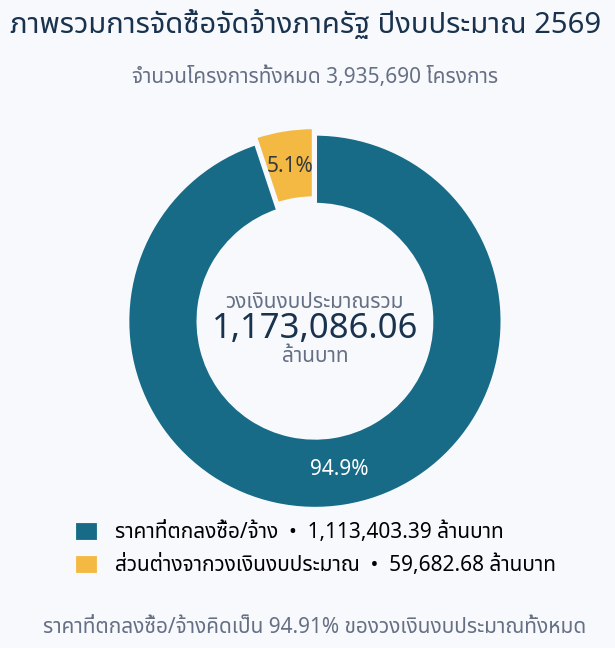

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/01_procurement_overview_donut_2569.svg

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/01_procurement_overview_donut_2569.png


In [11]:
# ============================================================
# GRAPH 1 : ภาพรวมวงเงินงบประมาณและราคาที่ตกลงซื้อ/จ้าง
# ============================================================

svg_file, png_file = figure_files("01_procurement_overview_donut")

# =========================================================
# 2) ข้อมูลการจัดซื้อจัดจ้าง
# =========================================================

# ส่วนต่างระหว่างวงเงินงบประมาณกับราคาที่ตกลง
budget_difference = budget_agreed_gap

values = [total_agreed, budget_difference]

labels = [
    "ราคาที่ตกลงซื้อ/จ้าง",
    "ส่วนต่างจากวงเงินงบประมาณ"
]

colors = ["#176B87", "#F4B942"]


# =========================================================
# 3) สร้างกราฟโดนัท
# =========================================================
fig, ax = plt.subplots(figsize=(7.5, 7), facecolor="#F7F9FC")
ax.set_facecolor("#F7F9FC")

wedges, _, percentage_texts = ax.pie(
    values,
    colors=colors,
    startangle=90,
    counterclock=False,
    explode=(0, 0.035),
    autopct=lambda pct: f"{pct:,.1f}%",
    pctdistance=0.80,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "#F7F9FC",
        "linewidth": 3
    }
)

# ปรับข้อความเปอร์เซ็นต์ให้อ่านง่าย
for i, text in enumerate(percentage_texts):
    text.set_fontsize(15)
    text.set_fontweight("bold")
    text.set_color("white" if i == 0 else "#343A40")


# =========================================================
# 4) ข้อความตรงกลางกราฟ
# =========================================================
ax.text(
    0, 0.10,
    "วงเงินงบประมาณรวม",
    ha="center",
    va="center",
    fontsize=15,
    color="#667085"
)

ax.text(
    0, -0.04,
    f"{total_budget / 1e6:,.2f}",
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color="#19324D"
)

ax.text(
    0, -0.19,
    "ล้านบาท",
    ha="center",
    va="center",
    fontsize=15,
    color="#667085"
)


# =========================================================
# 5) ชื่อกราฟและรายละเอียด
# =========================================================
fig.suptitle(
    f"ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ {YEAR}",
    fontsize=21,
    fontweight="bold",
    color="#19324D",
    y=0.96
)

ax.set_title(
    f"จำนวนโครงการทั้งหมด {total_projects:,.0f} โครงการ",
    fontsize=15,
    color="#667085",
    pad=18
)

legend_labels = [
    f"{labels[0]}  •  {total_agreed / 1e6:,.2f} ล้านบาท",
    f"{labels[1]}  •  {budget_difference / 1e6:,.2f} ล้านบาท"
]

ax.legend(
    wedges,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=1,
    frameon=False,
    fontsize=15,
    handlelength=1.2,
    handleheight=1.2
)

ax.text(
    0.5, -0.25,
    "ราคาที่ตกลงซื้อ/จ้างคิดเป็น "
    f"{total_agreed / total_budget * 100:,.2f}% ของวงเงินงบประมาณทั้งหมด",
    transform=ax.transAxes,
    ha="center",
    fontsize=15,
    color="#667085"
)

# =========================================================
# 6) ปรับ Layout และบันทึกกราฟ
# =========================================================

ax.axis("equal")
plt.subplots_adjust(
    top=0.82,
    bottom=0.22
)

# บันทึก SVG — ขยายโดยไม่แตก
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

# บันทึก PNG ความละเอียดสูง
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

# แสดงกราฟใน Colab
plt.show()
plt.close(fig)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(svg_file)

print()

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(png_file)


## Analysis 2 — สรุปตามประเภทโครงการ


In [12]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# ANALYSIS 2 : สรุปข้อมูลตามประเภทโครงการ
# ============================================================

# สร้างตารางใหม่จาก project_overview_df ทุกครั้ง
# groupby() = รวมโครงการที่มี "ชื่อประเภทโครงการ" เดียวกันไว้ด้วยกัน
project_type_df = project_overview_df.groupby("ชื่อประเภทโครงการ", dropna=False).agg(
    project_count=("รหัสโครงการ", "size"),                 # จำนวนโครงการ
    total_budget=("วงเงินงบประมาณ (บาท)", "sum"),          # วงเงินรวม
    average_budget=("วงเงินงบประมาณ (บาท)", "mean")        # วงเงินเฉลี่ย
).reset_index()

# ใช้จำนวนโครงการและวงเงินรวมจาก Analysis 1 เป็นฐานในการหาร้อยละ
# ตัวแปรทั้งสองคำนวณไว้แล้ว จึงไม่ต้องรวมข้อมูลขนาดใหญ่ซ้ำอีกครั้ง

# คำนวณสัดส่วนของแต่ละประเภทเมื่อเทียบกับข้อมูลทั้งหมด
project_type_df["project_share"] = project_type_df["project_count"] / total_projects * 100
project_type_df["budget_share"] = project_type_df["total_budget"] / total_budget * 100

# เรียงจากประเภทที่มีจำนวนโครงการมากที่สุดไปน้อยที่สุด
project_type_df = project_type_df.sort_values("project_count", ascending=False).reset_index(drop=True)

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทย หลังจากคำนวณและเรียงข้อมูลเสร็จแล้ว
project_type_df = project_type_df.rename(columns={
    "project_count": "จำนวนโครงการ",
    "total_budget": "วงเงินรวม (บาท)",
    "average_budget": "วงเงินเฉลี่ย (บาท)",
    "project_share": "สัดส่วนจำนวนโครงการ (ร้อยละ)",
    "budget_share": "สัดส่วนวงเงิน (ร้อยละ)"
})

# แสดงตาราง
display(project_type_df)


/tmp/ipykernel_1135/38152724.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  project_type_df = project_overview_df.groupby("ชื่อประเภทโครงการ", dropna=False).agg(


,ชื่อประเภทโครงการ,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท),สัดส่วนจำนวนโครงการ (ร้อยละ),สัดส่วนวงเงิน (ร้อยละ)
0,ซื้อ,2474411,4.190804e+11,1.693657e+05,62.871085,35.724606
1,จ้างทำของ/จ้างเหมาบริการ,1234754,2.027792e+11,1.642264e+05,31.373253,17.285962
2,จ้างก่อสร้าง,178978,4.759303e+11,2.659155e+06,4.547563,40.570790
3,เช่า,44746,5.907037e+10,1.320126e+06,1.136929,5.035467
4,จ้างที่ปรึกษา,1314,1.222968e+10,9.307213e+06,0.033387,1.042522
5,จ้างออกแบบ,1301,2.567512e+09,1.973491e+06,0.033056,0.218868
6,จ้างควบคุมงาน,151,1.404016e+09,9.298119e+06,0.003837,0.119686
7,จ้างออกแบบและควบคุมงานก่อสร้าง,35,2.462623e+07,7.036066e+05,0.000889,0.002099


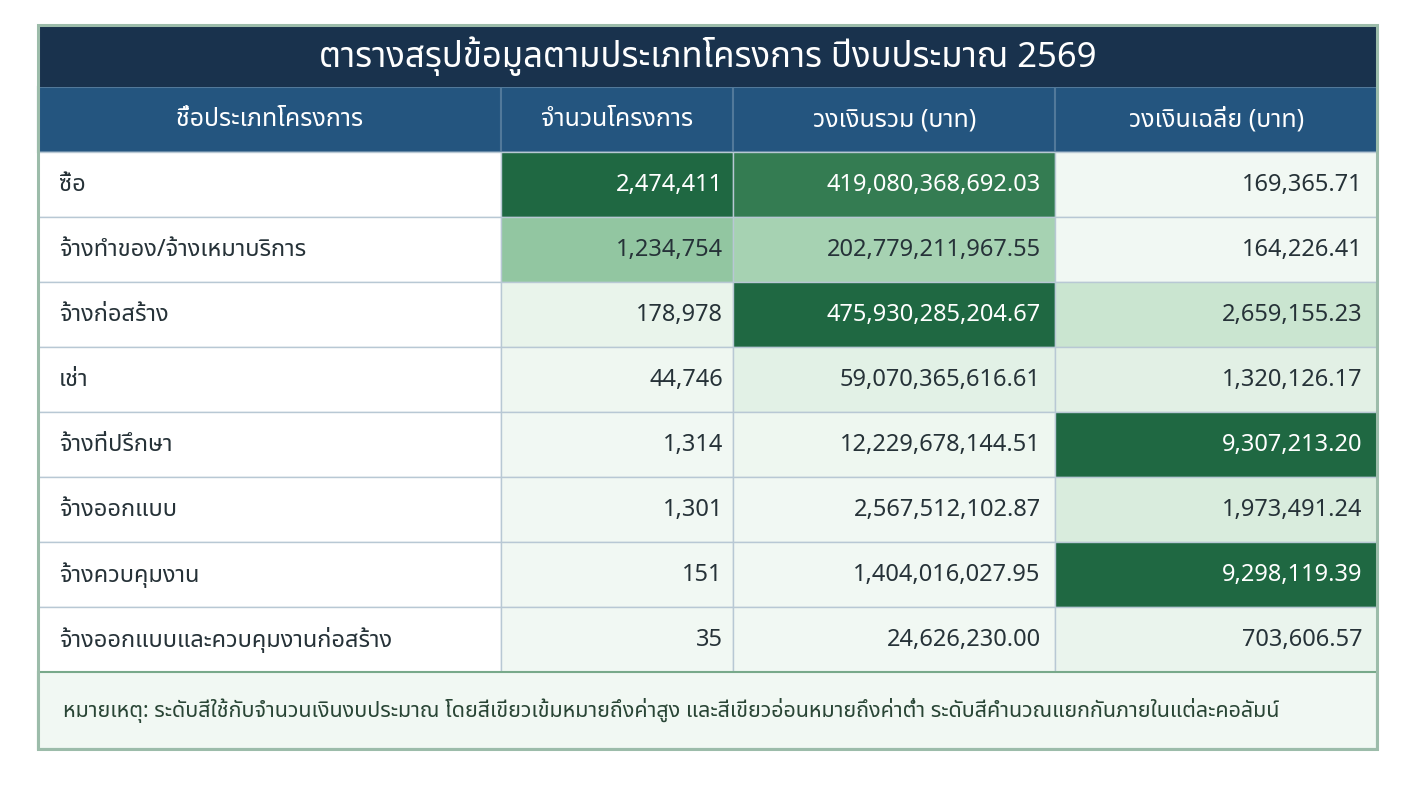

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


In [13]:
# ============================================================
# TABLE 2 : สรุปข้อมูลตามประเภทโครงการ
# ============================================================

svg_file, png_file = figure_files("03_project_type_summary_table")

# ============================================================
# 2) เตรียมข้อมูล
# ============================================================

columns_to_show = [
    "ชื่อประเภทโครงการ",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

table_export_df = project_type_df[columns_to_show].copy()

table_export_df["ชื่อประเภทโครงการ"] = (
    table_export_df["ชื่อประเภทโครงการ"]
    # แปลง Category เป็น String ก่อน จึงเติมข้อความที่ไม่อยู่ใน Category เดิมได้
    .astype("string")
    .fillna("ไม่ระบุประเภท")
)

# เรียงตามจำนวนโครงการจากมากไปน้อย
table_export_df = (
    table_export_df
    .sort_values("จำนวนโครงการ", ascending=False)
    .reset_index(drop=True)
)

numeric_columns = [
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

# ตรวจสอบให้คอลัมน์ตัวเลขเป็น Numeric
for column in numeric_columns:
    table_export_df[column] = pd.to_numeric(
        table_export_df[column],
        errors="coerce"
    ).fillna(0)

# ============================================================
# 3) จัดรูปแบบข้อความสำหรับแสดงในตาราง
# ============================================================

cell_text = []

for _, row in table_export_df.iterrows():
    cell_text.append(
        [
            row["ชื่อประเภทโครงการ"],
            f'{row["จำนวนโครงการ"]:,.0f}',
            f'{row["วงเงินรวม (บาท)"]:,.2f}',
            f'{row["วงเงินเฉลี่ย (บาท)"]:,.2f}'
        ]
    )

# ============================================================
# 4) กำหนดชุดสี
# ============================================================

title_color = "#19324D"
header_color = "#24557F"
header_border_color = "#52799A"

text_color = "#263238"
border_color = "#B8C8D4"
name_background = "#FFFFFF"
note_background = "#F1F8F3"
note_border_color = "#78A98A"

# สีเขียวอ่อน → สีเขียวเข้ม
green_scale = LinearSegmentedColormap.from_list(
    "table_green_scale",
    [
        "#F1F8F3",
        "#D9ECDD",
        "#AED7B8",
        "#75B589",
        "#438A5E",
        "#1F6842"
    ]
)

# คำนวณระดับสีแยกภายในแต่ละคอลัมน์
column_normalizers = {}

for column in numeric_columns:
    minimum = table_export_df[column].min()
    maximum = table_export_df[column].max()

    if minimum == maximum:
        maximum = minimum + 1

    column_normalizers[column] = Normalize(
        vmin=minimum,
        vmax=maximum
    )

# ============================================================
# 5) สร้างพื้นที่ตาราง
# ============================================================

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# ตำแหน่งองค์ประกอบทั้งหมด
left = 0.02
width = 0.96

title_bottom = 0.90
title_height = 0.08

table_bottom = 0.14
table_height = 0.76

note_bottom = 0.04
note_height = 0.10

# ============================================================
# 6) ส่วนชื่อเรื่อง
# ============================================================

ax.add_patch(
    Rectangle(
        (left, title_bottom),
        width,
        title_height,
        transform=ax.transAxes,
        facecolor=title_color,
        edgecolor=title_color,
        linewidth=0
    )
)

ax.text(
    0.5,
    title_bottom + title_height / 2,
    (
        f"ตารางสรุปข้อมูลตามประเภทโครงการ "
        f"ปีงบประมาณ {YEAR}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color="white"
)

# ============================================================
# 7) สร้างตาราง
# ============================================================

table = ax.table(
    cellText=cell_text,
    colLabels=columns_to_show,
    cellLoc="right",
    colLoc="center",
    colWidths=[0.36, 0.18, 0.25, 0.25],
    bbox=[
        left,
        table_bottom,
        width,
        table_height
    ]
)

table.auto_set_font_size(False)
table.set_fontsize(17)

# ============================================================
# 8) ตกแต่งหัวคอลัมน์
# ============================================================

for column_index in range(len(columns_to_show)):
    header_cell = table[(0, column_index)]

    header_cell.set_facecolor(header_color)
    header_cell.set_edgecolor(header_border_color)
    header_cell.set_linewidth(1.5)

    header_text = header_cell.get_text()
    header_text.set_color("white")
    header_text.set_fontsize(18)
    header_text.set_fontweight("bold")
    header_text.set_ha("center")
    header_text.set_va("center")

# ============================================================
# 9) ตกแต่งเซลล์ข้อมูล
# ============================================================

for row_index in range(len(table_export_df)):
    for column_index, column_name in enumerate(columns_to_show):
        cell = table[(row_index + 1, column_index)]
        cell.set_edgecolor(border_color)
        cell.set_linewidth(1.0)
        cell.PAD = 0.045

        cell_text_object = cell.get_text()
        cell_text_object.set_fontsize(17)
        cell_text_object.set_va("center")

        if column_name == "ชื่อประเภทโครงการ":
            # ชื่อประเภทเป็นพื้นสีขาวทุกแถว
            cell.set_facecolor(name_background)
            cell_text_object.set_color(text_color)
            cell_text_object.set_fontweight("semibold")
            cell_text_object.set_ha("left")

        else:
            # ไล่สีเขียวเฉพาะคอลัมน์ตัวเลข
            numeric_value = table_export_df.loc[
                row_index,
                column_name
            ]

            normalized_value = column_normalizers[
                column_name
            ](numeric_value)

            cell.set_facecolor(
                green_scale(normalized_value)
            )

            # ใช้ตัวอักษรสีขาวเมื่อพื้นหลังเข้ม
            if normalized_value >= 0.68:
                cell_text_object.set_color("white")
            else:
                cell_text_object.set_color(text_color)

            cell_text_object.set_fontweight("semibold")
            cell_text_object.set_ha("right")

# ============================================================
# 10) ส่วนหมายเหตุ — กว้างเท่ากับตาราง
# ============================================================

ax.add_patch(
    Rectangle(
        (left, note_bottom),
        width,
        note_height,
        transform=ax.transAxes,
        facecolor=note_background,
        edgecolor=note_border_color,
        linewidth=1.5
    )
)

ax.text(
    left + 0.018,
    note_bottom + note_height / 2,
    (
        "หมายเหตุ: ระดับสีใช้กับจำนวนเงินงบประมาณ "
        "โดยสีเขียวเข้มหมายถึงค่าสูง และสีเขียวอ่อนหมายถึงค่าต่ำ "
        "ระดับสีคำนวณแยกกันภายในแต่ละคอลัมน์"
    ),
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=15.5,
    color="#294535"
)

# ============================================================
# 11) เส้นขอบรอบตารางทั้งหมด
# ============================================================

ax.add_patch(
    Rectangle(
        (left, note_bottom),
        width,
        title_bottom + title_height - note_bottom,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor="#9CBCAA",
        linewidth=2.2
    )
)

# ============================================================
# 12) บันทึกไฟล์
# ============================================================

# SVG: ขยายได้โดยไม่แตก
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

# PNG: ความละเอียดสูงสำหรับใช้งานทั่วไป
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()
plt.close(fig)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


## Analysis 3 — สรุปตามจังหวัด


In [14]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# ANALYSIS 3 : สรุปข้อมูลการจัดซื้อจัดจ้างตามจังหวัด
# ============================================================

# นับโครงการที่ไม่มีข้อมูลจังหวัด
missing_province = (
    project_overview_df["จังหวัด"]
    .isna()
    .sum()
)

# ใช้ชื่อคอลัมน์ภาษาอังกฤษระหว่าง Aggregate
province_df = (
    project_overview_df
    .groupby("จังหวัด")
    .agg(
        project_count=(
            "รหัสโครงการ",
            "size"
        ),
        total_budget=(
            "วงเงินงบประมาณ (บาท)",
            "sum"
        ),
        average_budget=(
            "วงเงินงบประมาณ (บาท)",
            "mean"
        )
    )
    .reset_index()
)

# เปลี่ยนชื่อเป็นภาษาไทยด้วย String
# เพื่อหลีกเลี่ยงปัญหา Unicode จากชื่อ Keyword ภาษาไทย
province_df = province_df.rename(
    columns={
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินรวม (บาท)",
        "average_budget": "วงเงินเฉลี่ย (บาท)"
    }
)

# เรียงตามวงเงินรวมจากมากไปน้อย
province_df = (
    province_df
    .sort_values(
        "วงเงินรวม (บาท)",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"จำนวนจังหวัดที่พบในข้อมูล     : "
    f"{province_df['จังหวัด'].nunique():,} จังหวัด"
)

print(
    f"โครงการที่ไม่มีข้อมูลจังหวัด   : "
    f"{missing_province:,} โครงการ"
)


display(province_df)


จำนวนจังหวัดที่พบในข้อมูล     : 77 จังหวัด
โครงการที่ไม่มีข้อมูลจังหวัด   : 0 โครงการ


/tmp/ipykernel_1135/2576413279.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("จังหวัด")


,จังหวัด,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท)
0,กรุงเทพมหานคร,189690,4.885415e+11,2.575473e+06
1,นนทบุรี,59677,3.291231e+10,5.515075e+05
2,ชลบุรี,89219,3.075821e+10,3.447496e+05
3,เชียงใหม่,140943,3.010970e+10,2.136304e+05
4,นครราชสีมา,134738,2.858561e+10,2.121570e+05
...,...,...,...,...
72,อ่างทอง,23976,2.877924e+09,1.200336e+05
73,ตราด,17351,2.442371e+09,1.407625e+05
74,สิงห์บุรี,17791,2.359151e+09,1.326036e+05
75,ระนอง,14813,2.302878e+09,1.554633e+05


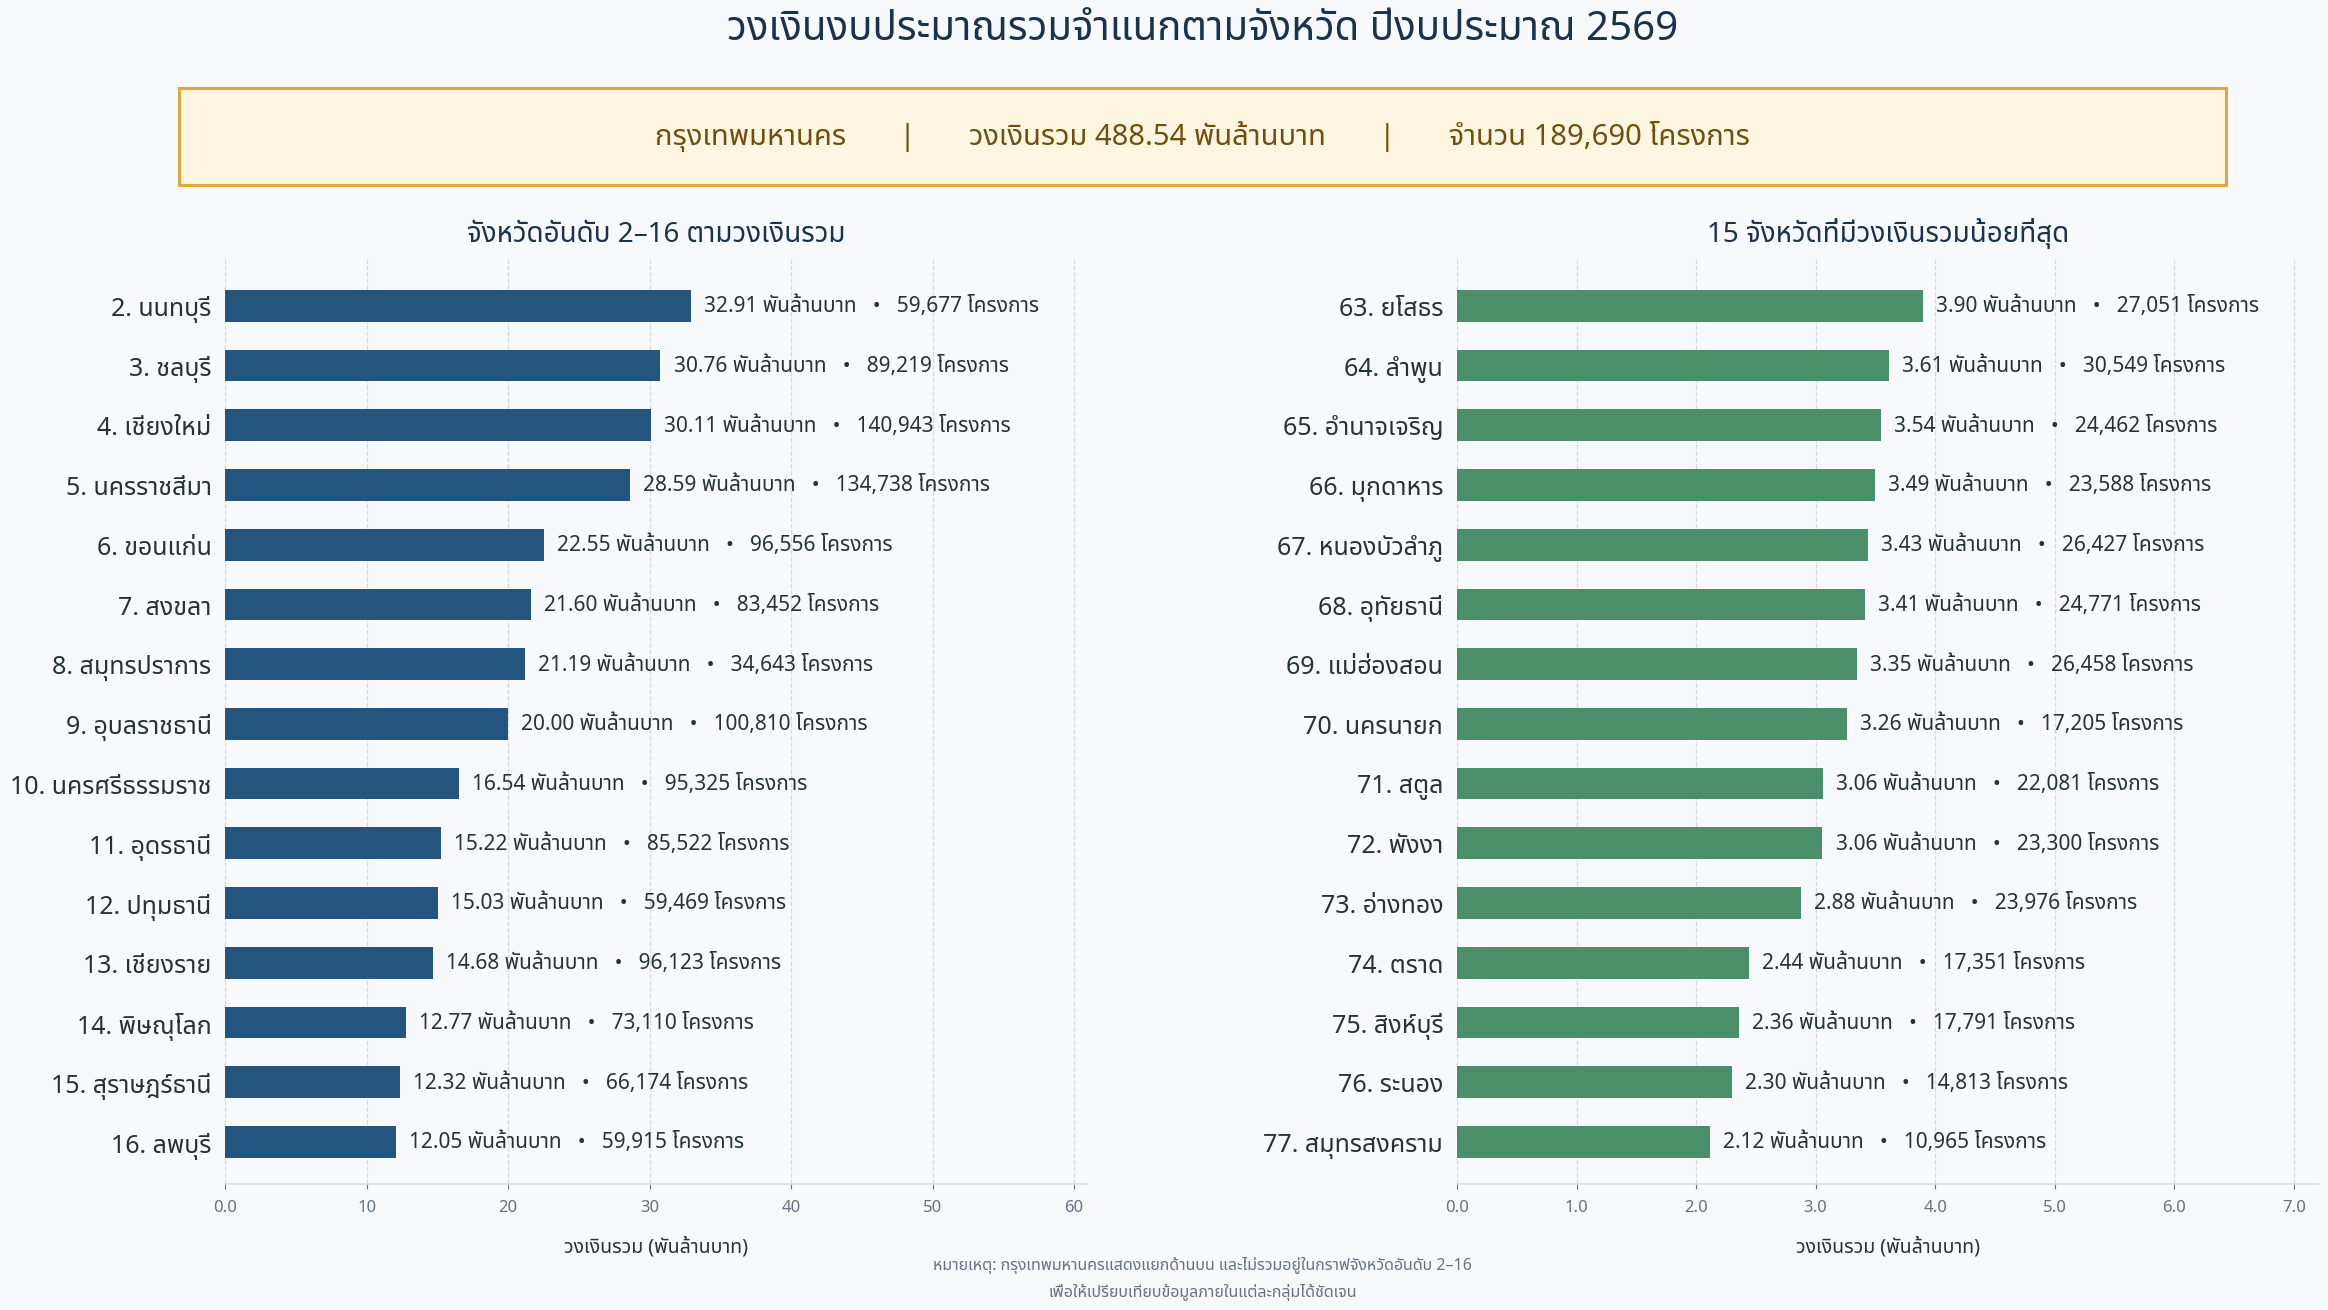

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/04_province_budget_top2_16_and_lower15_2569.svg

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/04_province_budget_top2_16_and_lower15_2569.png


In [15]:
# ============================================================
# GRAPH 3 : จังหวัดอันดับ 2–16 และ 15 จังหวัดอันดับล่าง
# รุ่นเพิ่มขนาดตัวอักษรและระยะห่าง
# ============================================================

svg_file, png_file = figure_files(
    "04_province_budget_top2_16_and_lower15"
)

# ============================================================
# 2) เตรียมข้อมูล
# ใช้ชื่อคอลัมน์ภาษาอังกฤษเพื่อป้องกันปัญหา Unicode
# ============================================================

province_plot_base = province_df.iloc[:, :4].copy()

province_plot_base.columns = [
    "province",
    "project_count",
    "total_budget",
    "average_budget"
]

for column in [
    "project_count",
    "total_budget",
    "average_budget"
]:
    province_plot_base[column] = pd.to_numeric(
        province_plot_base[column],
        errors="coerce"
    ).fillna(0)

province_ranked_df = (
    province_plot_base
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

province_ranked_df["rank"] = (
    np.arange(len(province_ranked_df)) + 1
)

province_ranked_df["budget_billion"] = (
    province_ranked_df["total_budget"]
    / 1_000_000_000
)


# ============================================================
# 3) ข้อมูลกรุงเทพมหานคร
# ============================================================

bangkok_rows = province_ranked_df.loc[
    province_ranked_df["province"].eq("กรุงเทพมหานคร")
]

if bangkok_rows.empty:
    raise ValueError(
        "ไม่พบข้อมูลกรุงเทพมหานครใน province_df"
    )

bangkok_data = bangkok_rows.iloc[0]

bangkok_budget_billion = bangkok_data[
    "budget_billion"
]

bangkok_project_count = bangkok_data[
    "project_count"
]


# ============================================================
# 4) แยกข้อมูลสำหรับแต่ละ Subplot
# ============================================================

# อันดับ 2–16 โดยตัดกรุงเทพมหานครออก
top_2_16_df = (
    province_ranked_df.loc[
        province_ranked_df["rank"].between(2, 16)
    ]
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)

# 15 จังหวัดที่มีวงเงินรวมน้อยที่สุด
lower_15_df = (
    province_ranked_df
    .nsmallest(
        15,
        "total_budget"
    )
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)


# ============================================================
# 5) กำหนดสี
# ============================================================

figure_background = "#F7F9FC"
title_color = "#19324D"
bangkok_color = "#E0A83B"

top_color = "#24557F"
lower_color = "#4B8F6A"

text_color = "#263238"
secondary_text_color = "#667085"
grid_color = "#D8E0E8"


# ============================================================
# 6) สร้าง Figure ขนาดใหญ่
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(23, 13.5),
    facecolor=figure_background
)

ax_top, ax_lower = axes

for ax in axes:
    ax.set_facecolor(figure_background)


# ============================================================
# 7) ชื่อกราฟหลัก
# ============================================================

fig.suptitle(
    (
        f"วงเงินงบประมาณรวมจำแนกตามจังหวัด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=29,
    fontweight="bold",
    color=title_color,
    y=0.975
)


# ============================================================
# 8) แถบข้อมูลกรุงเทพมหานคร
# ============================================================

bangkok_banner = Rectangle(
    (0.055, 0.845),
    0.89,
    0.072,
    transform=fig.transFigure,
    facecolor="#FFF6E1",
    edgecolor=bangkok_color,
    linewidth=2.2
)

fig.add_artist(bangkok_banner)

fig.text(
    0.50,
    0.881,
    (
        f"กรุงเทพมหานคร"
        f"       |       "
        f"วงเงินรวม {bangkok_budget_billion:,.2f} พันล้านบาท"
        f"       |       "
        f"จำนวน {bangkok_project_count:,.0f} โครงการ"
    ),
    ha="center",
    va="center",
    fontsize=21,
    fontweight="bold",
    color="#704F0A"
)


# ============================================================
# 9) ฟังก์ชันวาดกราฟ
# ============================================================

def draw_province_subplot(
    ax,
    data,
    title,
    bar_color
):
    # เพิ่มระยะห่างระหว่างแต่ละจังหวัด
    row_spacing = 1.28

    y_positions = (
        np.arange(len(data)) * row_spacing
    )

    budget_values = data["budget_billion"]

    province_labels = [
        f"{int(rank)}. {province}"
        for rank, province in zip(
            data["rank"],
            data["province"]
        )
    ]

    bars = ax.barh(
        y_positions,
        budget_values,
        height=0.68,
        color=bar_color,
        edgecolor="none",
        zorder=3
    )

    ax.set_yticks(y_positions) #############

    ax.set_yticklabels(
        province_labels,
        fontsize=18,
        fontweight="bold"
    )

    local_maximum = budget_values.max()

    # เผื่อพื้นที่ด้านขวาสำหรับข้อความ
    ax.set_xlim(
        0,
        local_maximum * 1.85
    )

    # เพิ่มพื้นที่บนและล่างของกราฟ
    ax.set_ylim(
        -0.9,
        y_positions[-1] + 1.0
    )

    # ตัวเลขท้ายแท่ง
    for bar, (_, row) in zip(
        bars,
        data.iterrows()
    ):
        value = row["budget_billion"]
        count = row["project_count"]

        ax.text(
            value + local_maximum * 0.028,
            bar.get_y() + bar.get_height() / 2,
            (
                f"{value:,.2f} พันล้านบาท"
                f"   •   {count:,.0f} โครงการ"
            ),
            ha="left",
            va="center",
            fontsize=15,              ###############
            fontweight="bold",
            color=text_color
        )

    # ชื่อ Subplot
    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        color=title_color,
        pad=13
    )

    ax.set_xlabel(
        "วงเงินรวม (พันล้านบาท)",
        fontsize=14,
        fontweight="bold",
        color=text_color,
        labelpad=15
    )

    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: (
                f"{value:,.1f}"
                if value < 10
                else f"{value:,.0f}"
            )
        )
    )

    # เส้น Grid
    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.9,
        alpha=0.35,
        color="#98A2B3",
        zorder=0
    )

    # ซ่อนเส้นกรอบที่ไม่จำเป็น
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(grid_color)
    ax.spines["bottom"].set_linewidth(1.2)

    # เพิ่มระยะห่างระหว่างชื่อจังหวัดกับกราฟ
    ax.tick_params(
        axis="y",
        length=0,
        pad=10,
        colors=text_color
    )

    ax.tick_params(
        axis="x",
        labelsize=12,
        pad=8,
        colors=secondary_text_color
    )


# ============================================================
# 10) วาด Subplot 1
# ============================================================

draw_province_subplot(
    ax=ax_top,
    data=top_2_16_df,
    title="จังหวัดอันดับ 2–16 ตามวงเงินรวม",
    bar_color=top_color
)


# ============================================================
# 11) วาด Subplot 2
# ============================================================

draw_province_subplot(
    ax=ax_lower,
    data=lower_15_df,
    title="15 จังหวัดที่มีวงเงินรวมน้อยที่สุด",
    bar_color=lower_color
)


# ============================================================
# 12) หมายเหตุด้านล่าง
# ============================================================

missing_count = (
    missing_province
    if "missing_province" in globals()
    else 0
)

fig.text(
    0.50,
    0.035,
    (
        "หมายเหตุ: กรุงเทพมหานครแสดงแยกด้านบน "
        "และไม่รวมอยู่ในกราฟจังหวัดอันดับ 2–16\n"
        "เพื่อให้เปรียบเทียบข้อมูลภายในแต่ละกลุ่มได้ชัดเจน"
    ),
    ha="center",
    va="center",
    fontsize=11.5,
    linespacing=1.7,
    color=secondary_text_color
)


# ============================================================
# 13) จัดตำแหน่งองค์ประกอบ
# ============================================================

plt.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.105,
    top=0.79,
    wspace=0.43
)


# ============================================================
# 14) บันทึก SVG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 15) บันทึก PNG ความละเอียดสูง
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 16) แสดงผล
# ============================================================

plt.show()

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(svg_file)

print()

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(png_file)


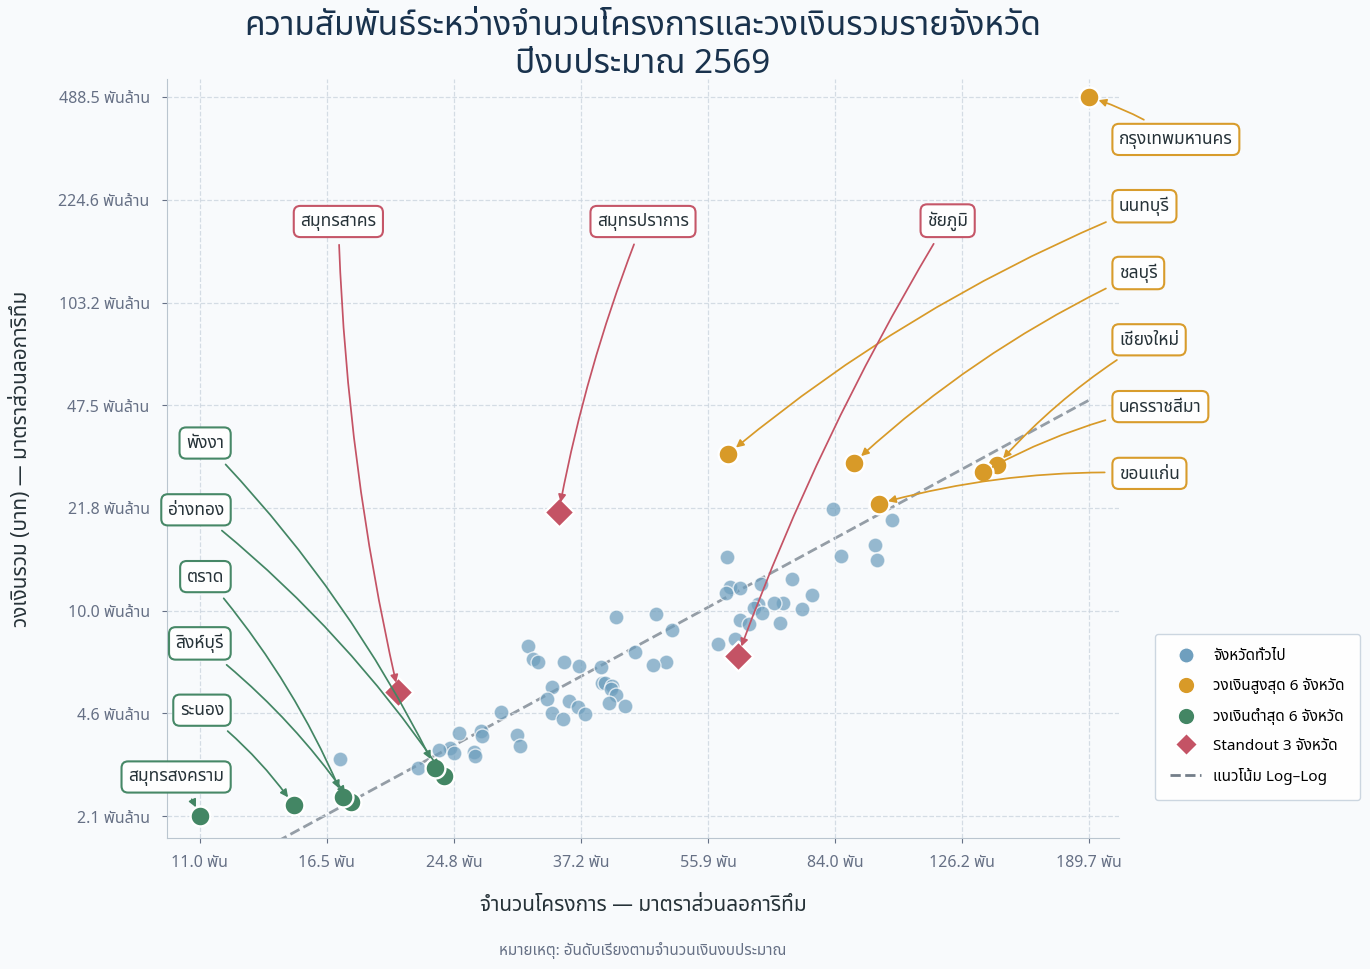

✅ SVG: /tmp/procurement_github_omyreo2f/05_province_log_scatter_2569.svg
✅ PNG: /tmp/procurement_github_omyreo2f/05_province_log_scatter_2569.png


In [16]:
# ============================================================
# GRAPH 4 : ความสัมพันธ์ระหว่างวงเงินรวมกับจำนวนโครงการตามจังหวัด
# จัดกล่องชื่อไว้นอกพื้นที่กราฟ และใช้ Log Scale ทั้งสองแกน
# ============================================================

# ปิด Figure ก่อนหน้าเพื่อลดการใช้หน่วยความจำใน Colab
plt.close("all")

TOP_N = 6
LOWER_N = 6
STANDOUT_N = 3

svg_file, png_file = figure_files("05_province_log_scatter")

# ============================================================
# เตรียมข้อมูล
# ============================================================

scatter_df = province_df.iloc[:, :4].copy()

scatter_df.columns = [
    "province",
    "project_count",
    "total_budget",
    "average_budget"
]

for column in ["project_count", "total_budget", "average_budget"]:
    scatter_df[column] = pd.to_numeric(
        scatter_df[column],
        errors="coerce"
    )

scatter_df = (
    scatter_df
    .dropna(subset=["province", "project_count", "total_budget"])
    .loc[
        lambda data:
        (data["project_count"] > 0)
        & (data["total_budget"] > 0)
    ]
    .reset_index(drop=True)
)


# ============================================================
# คำนวณแนวโน้มและหา Standout
# ============================================================

scatter_df["log_x"] = np.log10(scatter_df["project_count"])
scatter_df["log_y"] = np.log10(scatter_df["total_budget"])

slope, intercept = np.polyfit(
    scatter_df["log_x"],
    scatter_df["log_y"],
    1
)

scatter_df["predicted_log_y"] = (
    intercept + slope * scatter_df["log_x"]
)

scatter_df["absolute_residual"] = abs(
    scatter_df["log_y"]
    - scatter_df["predicted_log_y"]
)

top_df = (
    scatter_df
    .nlargest(TOP_N, "total_budget")
    .reset_index(drop=True)
)

lower_df = (
    scatter_df
    .nsmallest(LOWER_N, "total_budget")
    .reset_index(drop=True)
)

top_names = set(top_df["province"])
lower_names = set(lower_df["province"])

standout_df = (
    scatter_df.loc[
        ~scatter_df["province"].isin(top_names | lower_names)
    ]
    .nlargest(STANDOUT_N, "absolute_residual")
    .reset_index(drop=True)
)

standout_names = set(standout_df["province"])

general_df = scatter_df.loc[
    ~scatter_df["province"].isin(
        top_names | lower_names | standout_names
    )
]


# ============================================================
# สี
# ============================================================

background = "#F8FAFC"
general_color = "#6F9FBE"
top_color = "#D89A28"
lower_color = "#438664"
standout_color = "#C45365"

title_color = "#19324D"
text_color = "#263238"
secondary_color = "#667085"
grid_color = "#CBD5DF"


# ============================================================
# สร้างกราฟ
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 11.5),
    facecolor=background
)

ax.set_facecolor(background)
ax.set_xscale("log")
ax.set_yscale("log")

# จังหวัดทั่วไป
ax.scatter(
    general_df["project_count"],
    general_df["total_budget"],
    s=115,
    color=general_color,
    alpha=0.72,
    edgecolor="white",
    linewidth=1,
    zorder=2
)

# Top 6
ax.scatter(
    top_df["project_count"],
    top_df["total_budget"],
    s=205,
    color=top_color,
    edgecolor="white",
    linewidth=1.7,
    zorder=5
)

# Lower 6
ax.scatter(
    lower_df["project_count"],
    lower_df["total_budget"],
    s=205,
    color=lower_color,
    edgecolor="white",
    linewidth=1.7,
    zorder=5
)

# Standout
ax.scatter(
    standout_df["project_count"],
    standout_df["total_budget"],
    s=230,
    color=standout_color,
    marker="D",
    edgecolor="white",
    linewidth=1.7,
    zorder=6
)


# ============================================================
# เส้นแนวโน้ม
# ============================================================

min_x = scatter_df["project_count"].min()
max_x = scatter_df["project_count"].max()

min_y = scatter_df["total_budget"].min()
max_y = scatter_df["total_budget"].max()

trend_x = np.geomspace(min_x, max_x, 200)

trend_y = 10 ** (
    intercept + slope * np.log10(trend_x)
)

ax.plot(
    trend_x,
    trend_y,
    color="#737E89",
    linestyle="--",
    linewidth=2,
    alpha=0.75,
    zorder=1
)


# ============================================================
# กำหนดขอบเขตแกน
# ============================================================

ax.set_xlim(min_x * 0.90, max_x * 1.10)
ax.set_ylim(min_y * 0.85, max_y * 1.15)


# ============================================================
# ฟังก์ชันกล่องชื่อด้านซ้ายและขวา
# ============================================================

def add_side_labels(
    ax,
    data,
    side,
    y_start,
    y_end,
    box_color
):
    # เรียงตามตำแหน่งแนวตั้งของจุด
    ordered_data = (
        data
        .sort_values("total_budget", ascending=True)
        .reset_index(drop=True)
    )

    label_y_positions = np.linspace(
        y_start,
        y_end,
        len(ordered_data)
    )

    if side == "right":
        label_x = 1.0   ###############################################
        text_align = "left"
        curve = 0.08
    else:
        label_x = 0.06   ###############################################
        text_align = "right"
        curve = -0.08

    for (_, row), label_y in zip(
        ordered_data.iterrows(),
        label_y_positions
    ):
        ax.annotate(
            row["province"],

            # จุดที่ลูกศรชี้
            xy=(
                row["project_count"],
                row["total_budget"]
            ),
            xycoords="data",

            # กล่องชื่ออยู่นอกพื้นที่ Plot
            xytext=(
                label_x,
                label_y
            ),
            textcoords="axes fraction",

            ha=text_align,
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color=text_color,

            bbox={
                "boxstyle": "round,pad=0.38",
                "facecolor": "white",
                "edgecolor": box_color,
                "linewidth": 1.5,
                "alpha": 0.98
            },

            arrowprops={
                "arrowstyle": "-|>",
                "color": box_color,
                "linewidth": 1.25,
                "mutation_scale": 11,
                "shrinkA": 5,
                "shrinkB": 7,
                "connectionstyle": f"arc3,rad={curve}"
            },

            annotation_clip=False,
            zorder=8
        )


# Top 6 อยู่ด้านขวา
add_side_labels(
    ax=ax,
    data=top_df,
    side="right",
    y_start=0.48,
    y_end=0.92,
    box_color=top_color
)

# Lower 6 อยู่ด้านซ้าย
add_side_labels(
    ax=ax,        ###########################################################
    data=lower_df,
    side="left",
    y_start=0.08,
    y_end=0.52,
    box_color=lower_color
)


# ============================================================
# Standout 3 จังหวัดไว้ด้านบน
# ============================================================

standout_ordered = (
    standout_df
    .sort_values("project_count")
    .reset_index(drop=True)
)

standout_x_positions = np.linspace(
    0.18,
    0.82,
    len(standout_ordered)
)

for (_, row), label_x in zip(
    standout_ordered.iterrows(),
    standout_x_positions
):
    ax.annotate(
        row["province"],
        xy=(
            row["project_count"],
            row["total_budget"]
        ),
        xycoords="data",

        xytext=(
            label_x,
            0.8   ################################################################
        ),
        textcoords="axes fraction",

        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold",
        color=text_color,

        bbox={
            "boxstyle": "round,pad=0.38",
            "facecolor": "white",
            "edgecolor": standout_color,
            "linewidth": 1.5,
            "alpha": 0.98
        },

        arrowprops={
            "arrowstyle": "-|>",
            "color": standout_color,
            "linewidth": 1.25,
            "mutation_scale": 11,
            "shrinkA": 5,
            "shrinkB": 7,
            "connectionstyle": "arc3,rad=0.05"
        },

        annotation_clip=False,
        zorder=8
    )


# ============================================================
# Tick ตั้งแต่ Min ถึง Max
# ============================================================

x_ticks = np.geomspace(min_x, max_x, 8)
y_ticks = np.geomspace(min_y, max_y, 8)

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.yaxis.set_major_locator(FixedLocator(y_ticks))

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())


def format_count(value, position):
    if value >= 1_000_000:
        return f"{value / 1_000_000:,.2f} ล้าน"
    if value >= 1_000:
        return f"{value / 1_000:,.1f} พัน"
    return f"{value:,.0f}"


def format_budget(value, position):
    if value >= 1_000_000_000_000:
        return (
            f"{value / 1_000_000_000_000:,.2f} "
            "ล้านล้าน"
        )
    if value >= 1_000_000_000:
        return (
            f"{value / 1_000_000_000:,.1f} "
            "พันล้าน"
        )
    if value >= 1_000_000:
        return (
            f"{value / 1_000_000:,.1f} ล้าน"
        )
    return f"{value:,.0f}"


ax.xaxis.set_major_formatter(
    FuncFormatter(format_count)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_budget)
)


# ============================================================
# ชื่อกราฟ
# ============================================================

fig.suptitle(
    (
        "ความสัมพันธ์ระหว่างจำนวนโครงการและวงเงินรวมรายจังหวัด\n"
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=24,
    fontweight="bold",
    color=title_color,
    y=0.85 #################################################################
)

ax.set_xlabel(
    "จำนวนโครงการ — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=17
)

ax.set_ylabel(
    "วงเงินรวม (บาท) — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=19
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.9,
    color=grid_color,
    alpha=0.8,
    zorder=0
)

ax.tick_params(
    axis="both",
    labelsize=11.5,
    pad=9,
    colors=secondary_color
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#BAC5CF")
ax.spines["bottom"].set_color("#BAC5CF")


# ============================================================
# Legend — วางไว้นอกกราฟด้านขวาล่าง
# ============================================================

legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=general_color,
        markeredgecolor="white",
        markersize=11,
        label="จังหวัดทั่วไป"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=top_color,
        markeredgecolor="white",
        markersize=12,
        label="วงเงินสูงสุด 6 จังหวัด"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=lower_color,
        markeredgecolor="white",
        markersize=12,
        label="วงเงินต่ำสุด 6 จังหวัด"
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=standout_color,
        markeredgecolor="white",
        markersize=11,
        label="Standout 3 จังหวัด"
    ),
    Line2D(
        [0], [0],
        color="#737E89",
        linestyle="--",
        linewidth=2,
        label="แนวโน้ม Log–Log"
    )
]

ax.legend(
    handles=legend_items,
    loc="lower left",
    bbox_to_anchor=(1.03, 0.04),
    fontsize=11,
    facecolor="white",
    edgecolor=grid_color,
    framealpha=0.97,
    borderpad=1,
    labelspacing=0.9
)


# ============================================================
# หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.028,
    (
        "หมายเหตุ: อันดับเรียงตามจำนวนเงินงบประมาณ"
    ),
    ha="center",
    fontsize=11,
    color=secondary_color
)


# ============================================================
# Layout — เผื่อพื้นที่สำหรับกล่องชื่อทั้งสองด้าน
# ============================================================

plt.subplots_adjust(
    left=0.22,
    right=0.78,
    top=0.79,
    bottom=0.13
)


# ============================================================
# บันทึก SVG และ PNG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()
plt.close(fig)

print("✅ SVG:", svg_file)
print("✅ PNG:", png_file)


## Analysis 4 — สรุปตามหน่วยงาน


In [17]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# ANALYSIS 4 : สรุปข้อมูลการจัดซื้อจัดจ้างตามหน่วยงาน
# ============================================================

# จัดกลุ่มข้อมูลตาม "ชื่อหน่วยงาน"
# observed=True ป้องกันการสร้างกลุ่ม Category ที่ไม่มีข้อมูลจริง
# size() = จำนวนโครงการ เพราะข้อมูลของเราเป็น 1 Project = 1 Row
agency_df = (
    project_overview_df
    .groupby(
        "ชื่อหน่วยงาน",
        observed=True,
        dropna=False,
        sort=False
    )
    .agg(
        project_count=("รหัสโครงการ", "size"),
        total_budget=("วงเงินงบประมาณ (บาท)", "sum")
    )
    .reset_index()
)

# แปลงชื่อหน่วยงานหลัง GroupBy ซึ่งมีจำนวนแถวน้อยกว่าข้อมูลต้นฉบับมาก
# วิธีนี้ประหยัด RAM กว่าการแปลงข้อความหลายล้านแถวก่อน GroupBy
agency_df["ชื่อหน่วยงาน"] = (
    agency_df["ชื่อหน่วยงาน"]
    .astype("string")
    .str.strip()
    .fillna("ไม่ระบุชื่อหน่วยงาน")
)

# รวมชื่อหน่วยงานอีกครั้งหลังตัดช่องว่าง เพื่อป้องกันชื่อเดียวกันแยกเป็นหลายแถว
agency_df = (
    agency_df
    .groupby(
        "ชื่อหน่วยงาน",
        as_index=False,
        dropna=False,
        sort=False
    )
    .agg({
        "project_count": "sum",
        "total_budget": "sum"
    })
)

# คำนวณวงเงินเฉลี่ยจากยอดรวมและจำนวนโครงการหลังรวมชื่อที่สะกดเหมือนกันแล้ว
agency_df["average_budget"] = np.divide(
    agency_df["total_budget"],
    agency_df["project_count"],
    out=np.zeros(len(agency_df), dtype="float64"),
    where=agency_df["project_count"].to_numpy() > 0
)


# ============================================================
# หาสังกัดหลักของแต่ละหน่วยงานจาก project_overview_df
# ============================================================

# นับจำนวนครั้งของคู่ "ชื่อหน่วยงาน + สังกัด" โดยไม่สร้างสำเนาข้อมูลหลัก
# หากหน่วยงานเดียวมีหลายสังกัด จะเลือกสังกัดที่พบในโครงการมากที่สุด
agency_affiliation_counts = (
    project_overview_df
    .groupby(
        ["ชื่อหน่วยงาน", "สังกัด"],
        observed=True,
        dropna=True,
        sort=False
    )
    .size()
    .reset_index(name="จำนวนรายการสังกัด")
)

# ทำความสะอาดข้อความบนตารางสรุปขนาดเล็กแทนการแก้ข้อมูลหลายล้านแถว
for text_column in ["ชื่อหน่วยงาน", "สังกัด"]:
    agency_affiliation_counts[text_column] = (
        agency_affiliation_counts[text_column]
        .astype("string")
        .str.strip()
    )

valid_affiliation_mask = (
    agency_affiliation_counts["ชื่อหน่วยงาน"].notna()
    & agency_affiliation_counts["ชื่อหน่วยงาน"].ne("")
    & agency_affiliation_counts["สังกัด"].notna()
    & agency_affiliation_counts["สังกัด"].ne("")
)

agency_affiliation_counts = (
    agency_affiliation_counts
    .loc[valid_affiliation_mask]
    .groupby(
        ["ชื่อหน่วยงาน", "สังกัด"],
        as_index=False,
        dropna=False,
        sort=False
    )["จำนวนรายการสังกัด"]
    .sum()
)

# เรียงจำนวนที่พบจากมากไปน้อย แล้วเก็บสังกัดอันดับแรกของแต่ละหน่วยงาน
# กรณีจำนวนเท่ากัน ใช้ชื่อสังกัดเรียงตามตัวอักษรเพื่อให้ผลลัพธ์คงที่ทุกครั้ง
primary_affiliation_df = (
    agency_affiliation_counts
    .sort_values(
        ["ชื่อหน่วยงาน", "จำนวนรายการสังกัด", "สังกัด"],
        ascending=[True, False, True],
        kind="stable"
    )
    .drop_duplicates("ชื่อหน่วยงาน", keep="first")
    [["ชื่อหน่วยงาน", "สังกัด"]]
)

# ตรวจความสัมพันธ์ก่อน Merge เพื่อป้องกันจำนวนแถวเพิ่มแบบ many-to-many
if primary_affiliation_df["ชื่อหน่วยงาน"].duplicated().any():
    raise ValueError("พบชื่อหน่วยงานซ้ำในตารางสังกัดหลัก")

agency_df = agency_df.merge(
    primary_affiliation_df,
    on="ชื่อหน่วยงาน",
    how="left",
    validate="one_to_one"
)

missing_primary_affiliation = int(agency_df["สังกัด"].isna().sum())

# แปลงเป็น String ก่อน fillna เพื่อหลีกเลี่ยง Error ของ Category
agency_df["สังกัด"] = (
    agency_df["สังกัด"]
    .astype("string")
    .fillna("ไม่พบข้อมูลสังกัด")
)

# เปลี่ยนชื่อคอลัมน์และเรียงจากวงเงินรวมมากที่สุดไปน้อยที่สุด
agency_df = (
    agency_df
    .rename(columns={
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินรวม (บาท)",
        "average_budget": "วงเงินเฉลี่ย (บาท)"
    })
    .sort_values("วงเงินรวม (บาท)", ascending=False)
    .reset_index(drop=True)
)

# จัดลำดับคอลัมน์ให้สังกัดอยู่ถัดจากชื่อหน่วยงาน
agency_df = agency_df[[
    "ชื่อหน่วยงาน",
    "สังกัด",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]]

print(f"จำนวนหน่วยงานที่พบในข้อมูล : {agency_df['ชื่อหน่วยงาน'].nunique():,} หน่วยงาน")
print(f"หน่วยงานที่ไม่พบข้อมูลสังกัด : {missing_primary_affiliation:,} หน่วยงาน")

# Cleanup เฉพาะตารางสรุปชั่วคราว โดยเก็บ project_overview_df และ agency_df ไว้
del agency_affiliation_counts
del primary_affiliation_df
del valid_affiliation_mask
gc.collect()

# แสดงตาราง
display(agency_df)


จำนวนหน่วยงานที่พบในข้อมูล : 36,445 หน่วยงาน
หน่วยงานที่ไม่พบข้อมูลสังกัด : 361 หน่วยงาน


,ชื่อหน่วยงาน,สังกัด,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท)
0,กรมทางหลวง,ส่วนราชการทั่วไป,46292,1.073127e+11,2.318169e+06
1,กรมชลประทาน,ส่วนราชการทั่วไป,105973,9.257491e+10,8.735707e+05
2,กรมทางหลวงชนบท,ส่วนราชการทั่วไป,19004,4.823754e+10,2.538284e+06
3,การไฟฟ้าส่วนภูมิภาค,รัฐวิสาหกิจนอกตลาดหลักทรัพย์,23240,3.831723e+10,1.648762e+06
4,กรมโยธาธิการและผังเมือง,ส่วนราชการทั่วไป,3044,3.426838e+10,1.125768e+07
...,...,...,...,...,...
36440,โรงเรียนวัดศรีสร้อยเพชร,ส่วนราชการประเภทสถานศึกษา,2,7.050000e+02,3.525000e+02
36441,โรงเรียนบ้านโคกนาฝาย,ส่วนราชการประเภทสถานศึกษา,1,6.000000e+02,6.000000e+02
36442,โรงเรียนบ้านคลองซับน้อยสามัคคี,ส่วนราชการประเภทสถานศึกษา,1,5.000000e+02,5.000000e+02
36443,โรงเรียนบ้านคึมชาติประชาสรรค์,ส่วนราชการประเภทสถานศึกษา,1,5.000000e+02,5.000000e+02


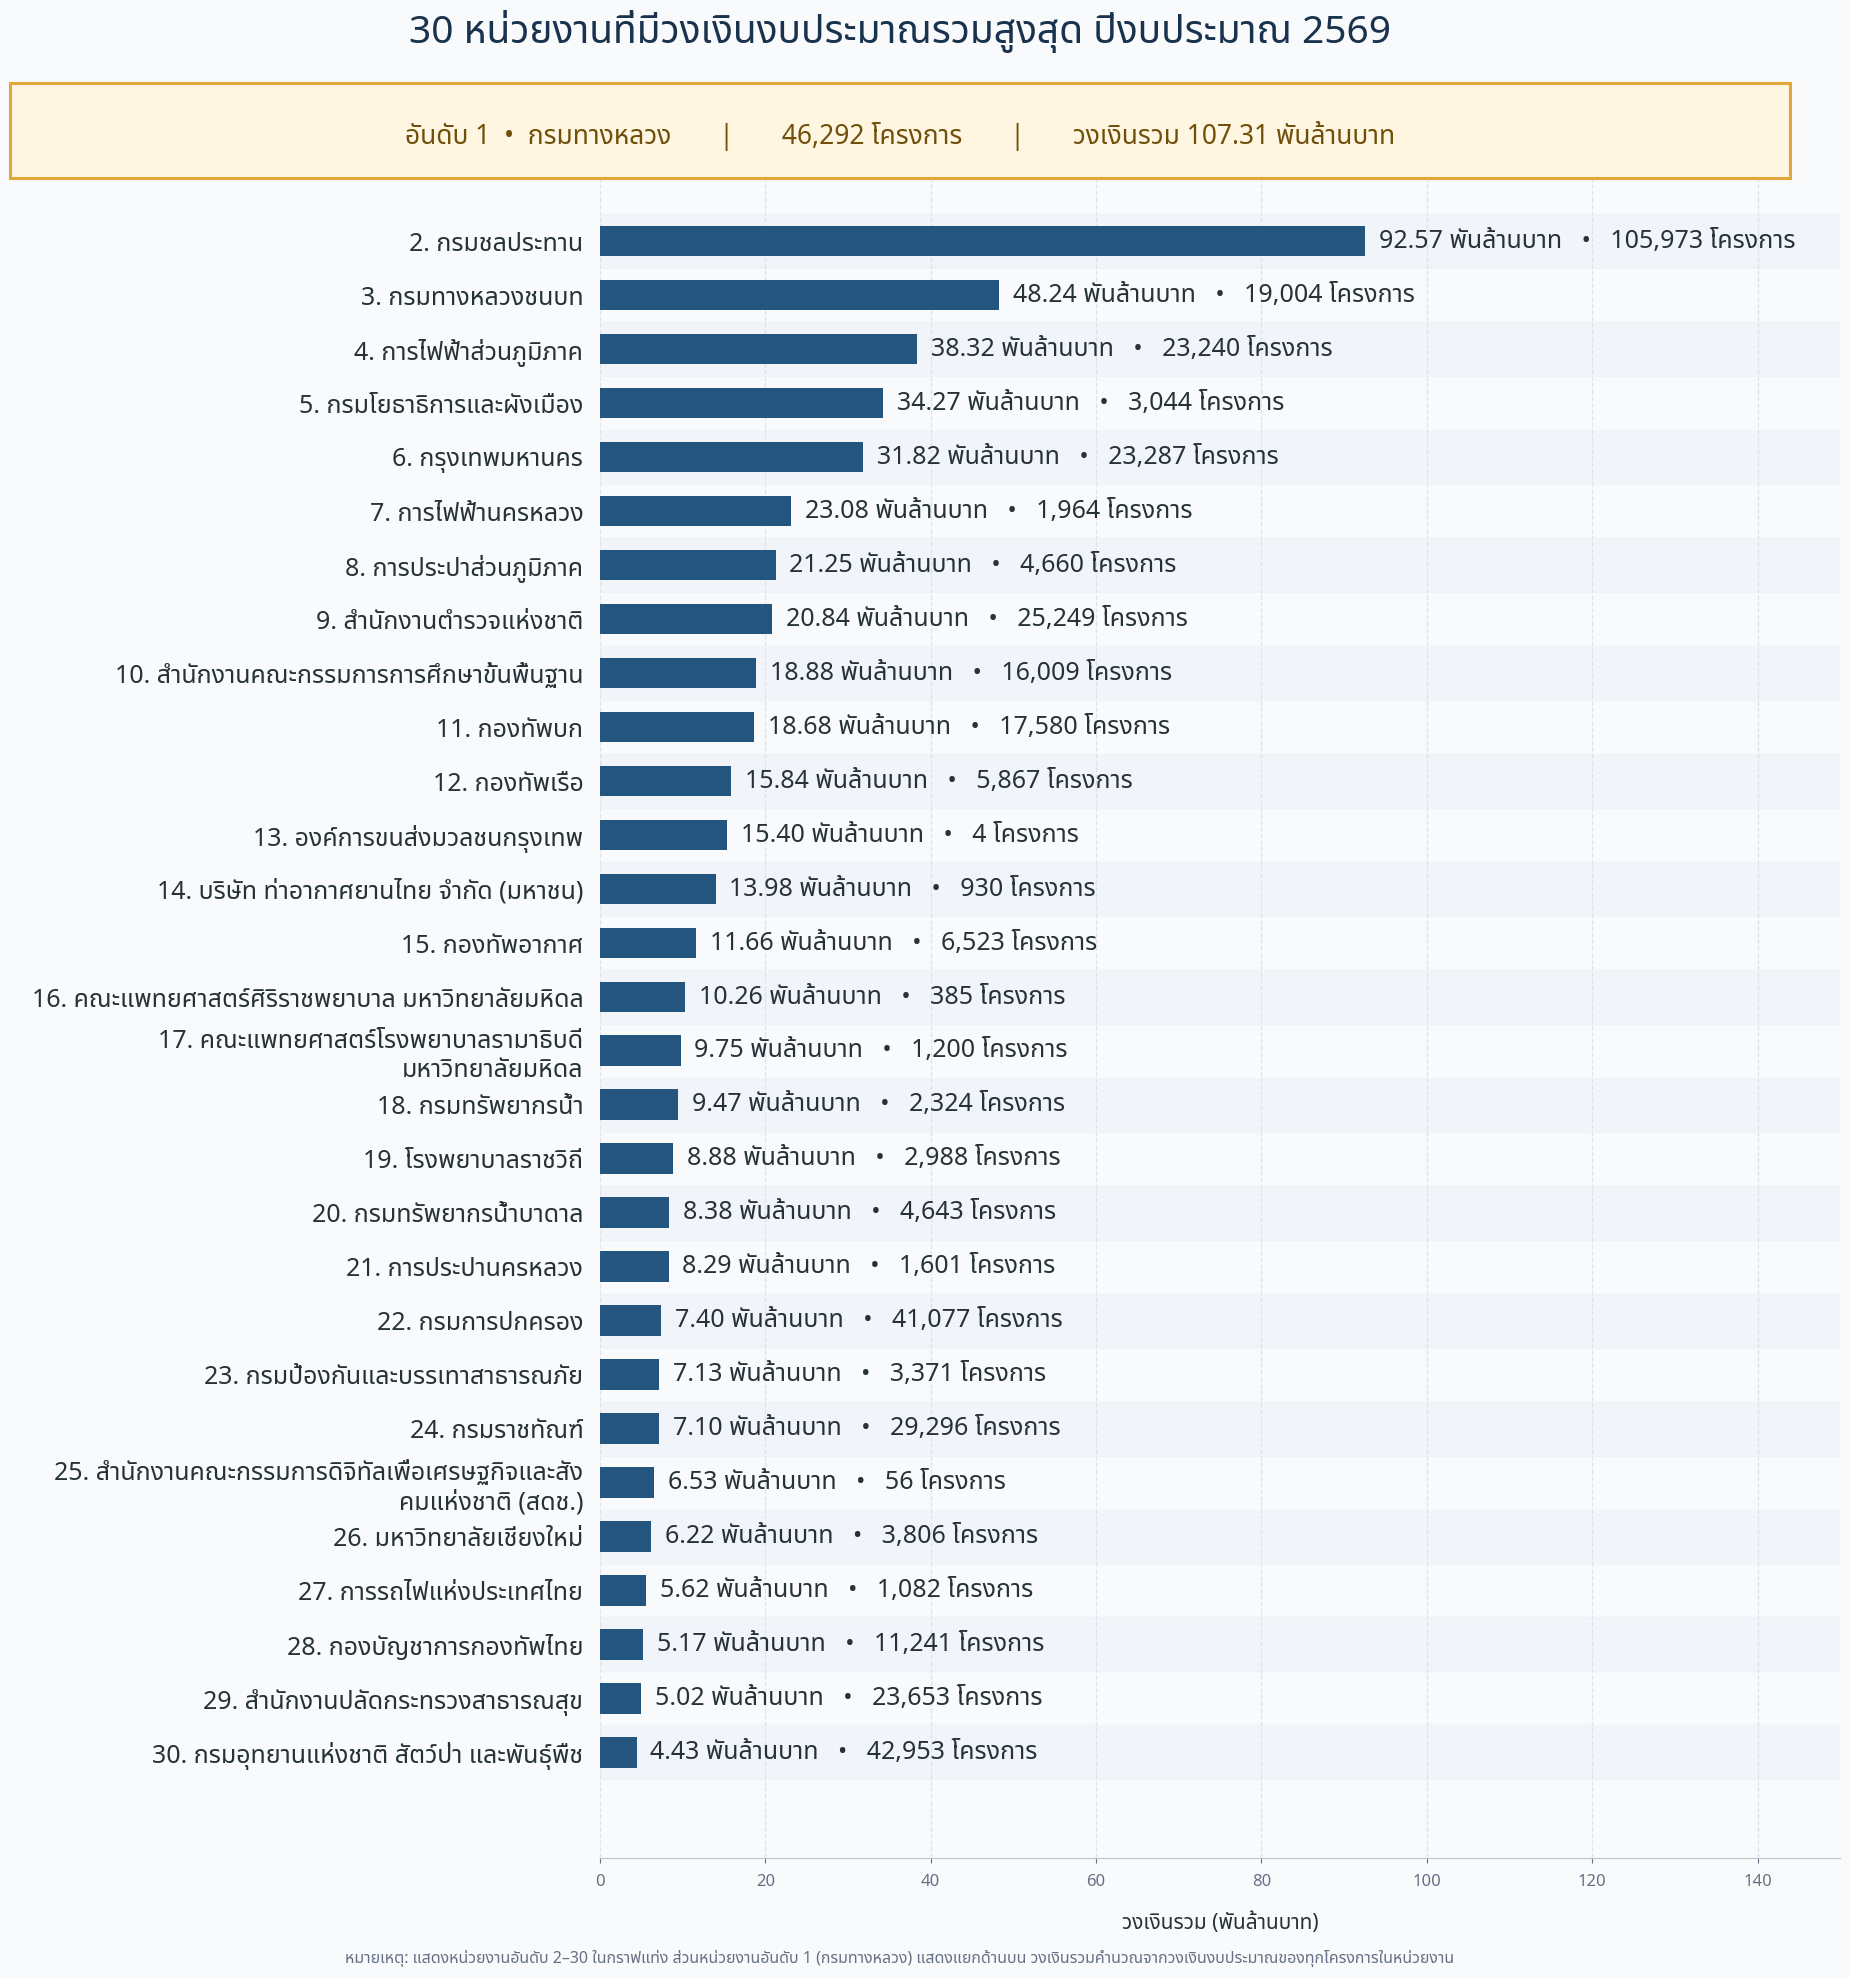

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/06_top_30_agencies_budget_2569.svg

แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
/tmp/procurement_github_omyreo2f/06_top_30_agencies_budget_2569.png


In [18]:
# ============================================================
# GRAPH 5 : 30 หน่วยงานที่มีวงเงินรวมสูงสุด
# แยกอันดับ 1 ไว้ด้านบน และ Plot อันดับ 2–30
# ============================================================

# คืนหน่วยความจำจาก Figure ก่อนหน้า
plt.close("all")

TOP_N = 30
svg_file, png_file = figure_files("06_top_30_agencies_budget")

# ============================================================
# 3) เตรียมข้อมูล
# ใช้ชื่อคอลัมน์ภาษาอังกฤษเพื่อป้องกันปัญหา Unicode
# ============================================================

# ระบุชื่อคอลัมน์โดยตรง ไม่เลือกด้วยตำแหน่ง iloc
# เพราะ agency_df มีคอลัมน์ "สังกัด" เพิ่มเข้ามา และลำดับคอลัมน์อาจเปลี่ยนได้
required_agency_plot_columns = [
    "ชื่อหน่วยงาน",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

missing_agency_plot_columns = [
    column
    for column in required_agency_plot_columns
    if column not in agency_df.columns
]

if missing_agency_plot_columns:
    raise KeyError(
        "agency_df ขาดคอลัมน์ที่กราฟ 5 ต้องใช้: "
        + ", ".join(missing_agency_plot_columns)
        + " กรุณารัน Analysis 4 เวอร์ชันล่าสุดก่อน"
    )

agency_plot_df = (
    agency_df[required_agency_plot_columns]
    .copy()
    .rename(columns={
        "ชื่อหน่วยงาน": "agency",
        "จำนวนโครงการ": "project_count",
        "วงเงินรวม (บาท)": "total_budget",
        "วงเงินเฉลี่ย (บาท)": "average_budget"
    })
)

for column in [
    "project_count",
    "total_budget",
    "average_budget"
]:
    agency_plot_df[column] = pd.to_numeric(
        agency_plot_df[column],
        errors="coerce"
    )

agency_plot_df = (
    agency_plot_df
    .dropna(
        subset=[
            "agency",
            "project_count",
            "total_budget"
        ]
    )
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

# ตรวจสอบหลังแปลงข้อมูล เพื่อไม่ให้ Error เป็น IndexError ที่ตีความยาก
if agency_plot_df.empty:
    raise ValueError(
        "กราฟ 5 ไม่มีข้อมูลหน่วยงานหลังเตรียมข้อมูล "
        "กรุณาตรวจชนิดข้อมูลของจำนวนโครงการและวงเงินรวม"
    )

if len(agency_plot_df) < 2:
    raise ValueError(
        "กราฟ 5 ต้องมีข้อมูลอย่างน้อย 2 หน่วยงาน "
        "เพื่อแยกอันดับ 1 และสร้างกราฟแท่ง"
    )

# หากปีใดมีหน่วยงานน้อยกว่า 30 ให้แสดงเท่าที่มีจริง
DISPLAY_N = min(TOP_N, len(agency_plot_df))

# เพิ่มอันดับ
agency_plot_df["rank"] = (
    np.arange(len(agency_plot_df)) + 1
)

# แปลงหน่วยเป็นพันล้านบาท
agency_plot_df["budget_billion"] = (
    agency_plot_df["total_budget"]
    / 1_000_000_000
)


# ============================================================
# 4) แยกอันดับ 1 และอันดับ 2–30
# ============================================================

number_one_agency = agency_plot_df.iloc[0]

chart_df = (
    agency_plot_df
    .iloc[1:DISPLAY_N]
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)

number_one_name = number_one_agency["agency"]
number_one_count = number_one_agency["project_count"]
number_one_budget = number_one_agency["budget_billion"]


# ============================================================
# 5) ตัดชื่อหน่วยงานที่ยาวให้ขึ้นบรรทัดใหม่
# ============================================================

def wrap_agency_name(name, width=44):
    return "\n".join(
        textwrap.wrap(
            str(name),
            width=width,
            break_long_words=True,
            break_on_hyphens=False
        )
    )


agency_labels = [
    f"{int(rank)}. {wrap_agency_name(agency)}"
    for rank, agency in zip(
        chart_df["rank"],
        chart_df["agency"]
    )
]


# ============================================================
# 6) กำหนดสี
# ============================================================

background_color = "#F8FAFC"
title_color = "#19324D"
bar_color = "#24557F"
highlight_color = "#E0A83B"

text_color = "#263238"
secondary_text_color = "#667085"
grid_color = "#D6DEE6"


# ============================================================
# 7) สร้าง Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(20, 21),
    facecolor=background_color
)

ax.set_facecolor(background_color)


# ============================================================
# 8) ชื่อกราฟหลัก
# ============================================================

fig.suptitle(
    (
        f"{DISPLAY_N} หน่วยงานที่มีวงเงินงบประมาณรวมสูงสุด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=28,
    fontweight="bold",
    color=title_color,
    y=0.95 ###########################################################################
)


# ============================================================
# 9) แถบสรุปหน่วยงานอันดับ 1
# ============================================================

summary_box = Rectangle(
    (0.055, 0.87),
    0.89,                                     #########################################
    0.045,
    transform=fig.transFigure,
    facecolor="#FFF6E1",
    edgecolor=highlight_color,
    linewidth=2.2
)

fig.add_artist(summary_box)

fig.text(
    0.5,
    0.89,                                             ##########
    (
        f"อันดับ 1  •  {number_one_name}"
        f"       |       "
        f"{number_one_count:,.0f} โครงการ"
        f"       |       "
        f"วงเงินรวม {number_one_budget:,.2f} พันล้านบาท"
    ),
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold",
    color="#704F0A"
)


# ============================================================
# 10) สร้างกราฟแท่งอันดับ 2–30
# ============================================================

row_spacing = 1.28
y_positions = np.arange(len(chart_df)) * row_spacing

bars = ax.barh(
    y_positions,
    chart_df["budget_billion"],
    height=0.72,
    color=bar_color,
    edgecolor="none",
    zorder=3
)


# ============================================================
# 11) เพิ่มพื้นหลังบาง ๆ เพื่อช่วยแยกแต่ละแถว
# ============================================================

for position, y_value in enumerate(y_positions):
    if position % 2 == 0:
        ax.axhspan(
            y_value - row_spacing / 2,
            y_value + row_spacing / 2,
            color="#EDF2F7",
            alpha=0.55,
            zorder=0
        )


# ============================================================
# 12) แสดงวงเงินและจำนวนโครงการท้ายแท่ง
# ============================================================

maximum_budget = chart_df["budget_billion"].max()

for bar, (_, row) in zip(
    bars,
    chart_df.iterrows()
):
    budget_value = row["budget_billion"]
    project_count = row["project_count"]

    ax.text(
        budget_value + maximum_budget * 0.018,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{budget_value:,.2f} พันล้านบาท"
            f"   •   {project_count:,.0f} โครงการ"
        ),
        ha="left",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=text_color,
        zorder=5
    )


# ============================================================
# 13) ชื่อหน่วยงานบนแกน Y
# ============================================================

ax.set_yticks(y_positions)

ax.set_yticklabels(
    agency_labels,
    fontsize=18,             ##############################
    fontweight="bold",
    color=text_color
)

ax.tick_params(
    axis="y",
    length=0,
    pad=12
)


# ============================================================
# 14) ชื่อ Subplot
# ============================================================


# ============================================================
# 15) ตั้งค่าแกน X
# ============================================================

ax.set_xlabel(
    "วงเงินรวม (พันล้านบาท)",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=16
)

ax.set_ylabel("")

# เผื่อพื้นที่ด้านขวาสำหรับข้อความท้ายแท่ง
ax.set_xlim(
    0,
    maximum_budget * 1.62
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8,
    colors=secondary_text_color
)


# ============================================================
# 16) Grid และเส้นขอบ
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.9,
    color=grid_color,
    alpha=0.8,
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#BAC5CF")


# ============================================================
# 17) หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.022,
    (
        f"หมายเหตุ: แสดงหน่วยงานอันดับ 2–{DISPLAY_N} ในกราฟแท่ง "
        f"ส่วนหน่วยงานอันดับ 1 ({number_one_name}) แสดงแยกด้านบน "
        "วงเงินรวมคำนวณจากวงเงินงบประมาณของทุกโครงการในหน่วยงาน"
    ),
    ha="center",
    va="center",
    fontsize=11.5,
    color=secondary_text_color
)


# ============================================================
# 18) ปรับ Layout
# ============================================================

plt.subplots_adjust(
    left=0.35,
    right=0.97,
    top=0.89,
    bottom=0.07
)


# ============================================================
# 19) บันทึก SVG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 20) บันทึก PNG ความละเอียดสูง
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 21) แสดงผลและคืนหน่วยความจำ
# ============================================================

plt.show()
plt.close(fig)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(svg_file)

print()

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(png_file)


## Analysis 6 — การกระจายของขนาดโครงการ


In [19]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# ANALYSIS 6 : การกระจายของขนาดโครงการ
# ============================================================

# กำหนด Feature ที่ใช้แบ่งขนาดโครงการ
budget_col = "วงเงินงบประมาณ (บาท)"

# กำหนดจุดแบ่งช่วงของวงเงิน
# เช่น ช่วงที่ 2 ในทางคำนวณหมายถึง มากกว่า 100,000 ถึง 500,000 บาท
size_bins = [
    -np.inf,
    100_000,
    500_000,
    1_000_000,
    10_000_000,
    100_000_000,
    np.inf
]

# กำหนดชื่อของแต่ละช่วงตามที่ต้องการแสดงในตาราง
size_labels = [
    "ไม่เกิน 100,000 บาท",
    "100,001–500,000 บาท",
    "500,001–1 ล้านบาท",
    "มากกว่า 1–10 ล้านบาท",
    "มากกว่า 10–100 ล้านบาท",
    "มากกว่า 100 ล้านบาท"
]

# สร้างสำเนาเฉพาะข้อมูลที่จำเป็น เพื่อไม่แก้ project_overview_df ต้นฉบับ
project_size_temp = project_overview_df[
    ["รหัสโครงการ", budget_col]
].copy()

# แบ่งแต่ละโครงการเข้าสู่ช่วงขนาดตามวงเงินงบประมาณ
# right=True หมายถึงค่าขอบบนรวมอยู่ในช่วงนั้น เช่น 100,000 อยู่ในช่วงแรก
project_size_temp["project_size"] = pd.cut(
    project_size_temp[budget_col],
    bins=size_bins,
    labels=size_labels,
    right=True,
    include_lowest=True
)

# สรุปจำนวนโครงการและวงเงินรวมของแต่ละช่วง
project_size_df = project_size_temp.groupby(
    "project_size",
    observed=False
).agg(
    project_count=("รหัสโครงการ", "size"),
    total_budget=(budget_col, "sum")
).reset_index()

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทยหลังคำนวณเสร็จ
project_size_df = project_size_df.rename(columns={
    "project_size": "ช่วงขนาดโครงการ",
    "project_count": "จำนวนโครงการ",
    "total_budget": "วงเงินรวม (บาท)"
})

# แสดงตาราง
display(
    project_size_df.style.format({
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินรวม (บาท)": "{:,.2f}"
    })
)

# คืน RAM ของตารางระดับโครงการชั่วคราวหลังสรุปผลเสร็จแล้ว
del project_size_temp
gc.collect()


,ช่วงขนาดโครงการ,จำนวนโครงการ,วงเงินรวม (บาท)
0,"ไม่เกิน 100,000 บาท","3,234,675","77,203,358,749.13"
1,"100,001–500,000 บาท","588,249","159,198,143,837.83"
2,"500,001–1 ล้านบาท","27,396","20,589,316,253.77"
3,มากกว่า 1–10 ล้านบาท,"71,026","254,513,491,982.41"
4,มากกว่า 10–100 ล้านบาท,"13,459","346,605,824,373.77"
5,มากกว่า 100 ล้านบาท,885,"314,975,928,789.28"


4915

RAM ก่อนเริ่มคำนวณ: 16.6%
จำนวนโครงการที่ใช้สร้างกราฟ: 3,935,690 โครงการ
ค่ามัธยฐาน: 20,144.00 บาท
ค่าเฉลี่ย: 298,063.63 บาท
ส่วนเบี่ยงเบนมาตรฐาน: 11,604,648.21 บาท


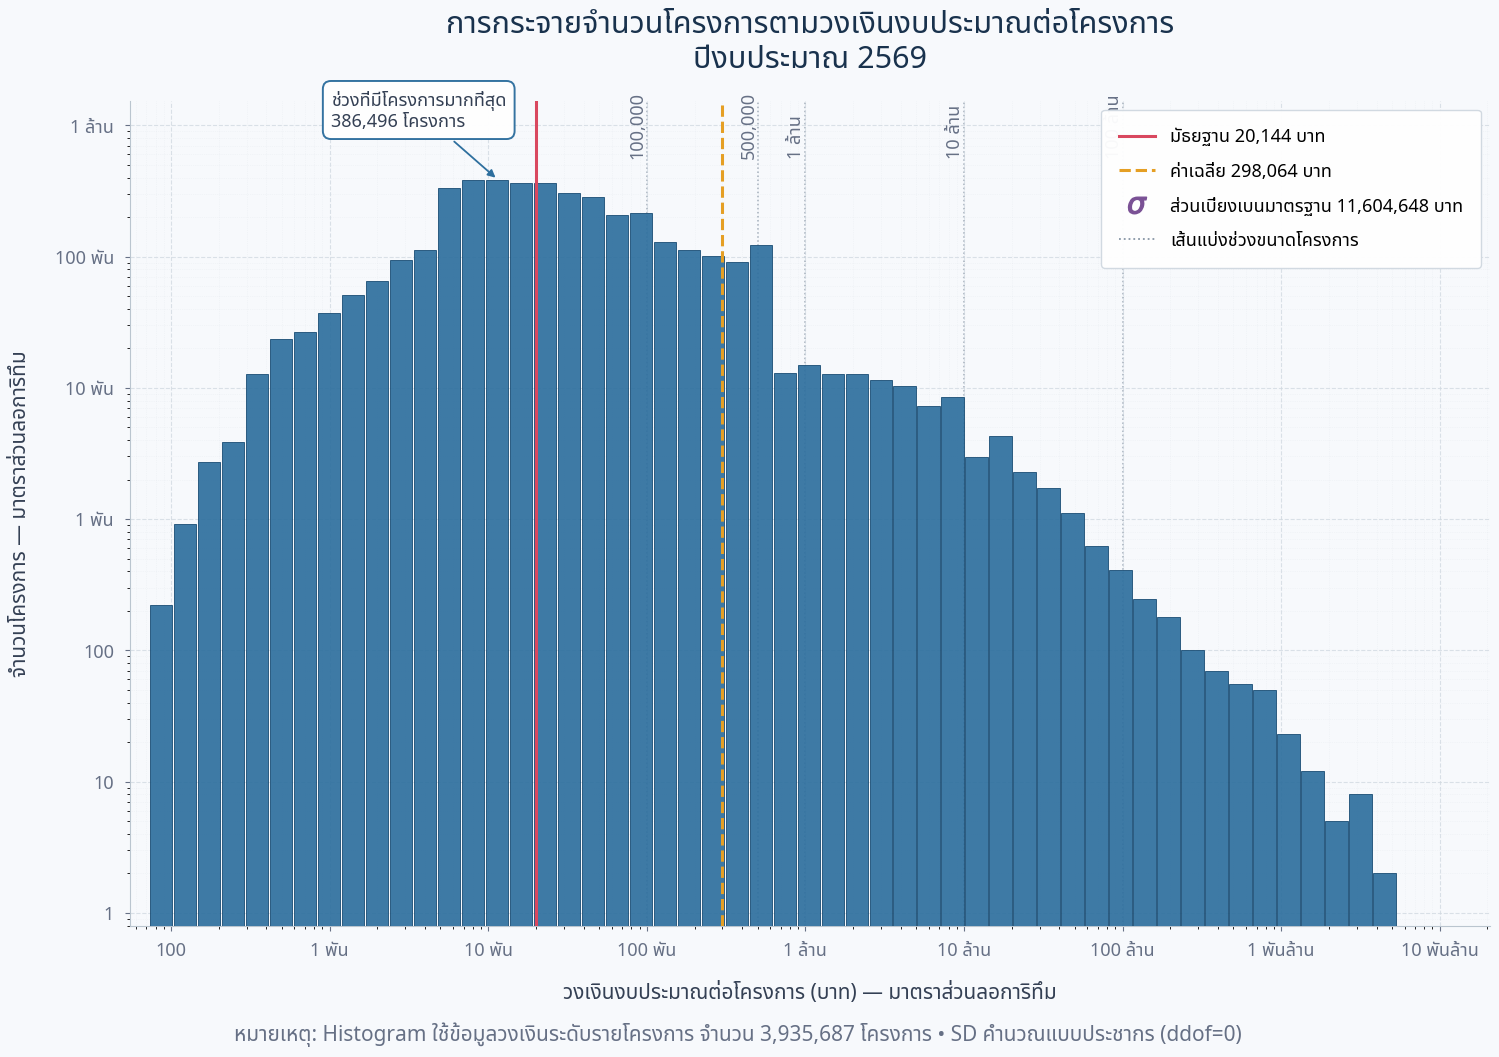


✅ Cleanup ตัวแปรชั่วคราวเรียบร้อยแล้ว


In [20]:
# ============================================================
# GRAPH 07 : การกระจายจำนวนโครงการตามวงเงินงบประมาณ
#            มาตราส่วนลอการิทึม
# ============================================================
#
# เพิ่มข้อมูลใน Legend:
# - ค่ามัธยฐาน
# - ค่าเฉลี่ย
# - ส่วนเบี่ยงเบนมาตรฐาน
# - เส้นแบ่งช่วงขนาดโครงการ
#
# SD คำนวณแบบประชากร (ddof=0)
# เนื่องจากข้อมูลครอบคลุมโครงการทั้งหมดในปีงบประมาณ
# ============================================================

import gc
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1) กำหนดค่าพื้นฐาน
# ============================================================

budget_column = "วงเงินงบประมาณ (บาท)"

year_text = (
    str(YEAR)
    if "YEAR" in globals()
    else ""
)

# จำนวน Bin ของ Histogram
NUMBER_OF_BINS = 55

# True  = แสดงและบันทึก SVG/PNG
# False = แสดงกราฟเพียงอย่างเดียว
SAVE_FIGURES = False  # แสดงกราฟอย่างเดียว
if "thai_font" in globals():
    plt.rcParams["font.family"] = thai_font

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2) ตรวจสอบ DataFrame และคอลัมน์
# ============================================================

if "project_overview_df" not in globals():
    raise NameError(
        "ไม่พบ project_overview_df\n"
        "กรุณารัน Cell Import ข้อมูลก่อน"
    )

if budget_column not in project_overview_df.columns:
    raise KeyError(
        f"ไม่พบคอลัมน์ '{budget_column}' "
        "ใน project_overview_df"
    )


# ============================================================
# 3) ตรวจสอบ RAM
# ============================================================

try:
    import psutil

    ram_usage_percent = (
        psutil.virtual_memory().percent
    )

    print(
        f"RAM ก่อนเริ่มคำนวณ: "
        f"{ram_usage_percent:.1f}%"
    )

    if ram_usage_percent >= 80:
        gc.collect()

        ram_usage_percent = (
            psutil.virtual_memory().percent
        )

        if ram_usage_percent >= 80:
            raise MemoryError(
                f"RAM ถูกใช้งาน {ram_usage_percent:.1f}%\n"
                "แนะนำให้ Restart Runtime ก่อนรัน Cell นี้"
            )

except ImportError:
    print("ไม่พบ psutil จึงข้ามการตรวจสอบ RAM")


# ============================================================
# 4) เตรียมข้อมูลงบประมาณ
# ============================================================

# เปลี่ยนวงเงินเป็นตัวเลข
budget_numeric_series = pd.to_numeric(
    project_overview_df[budget_column],
    errors="coerce"
)

# ใช้เฉพาะค่าที่เป็นตัวเลข มีค่าจำกัด และมากกว่าศูนย์
# เนื่องจาก Log Scale ไม่รองรับค่าศูนย์หรือค่าติดลบ
valid_budget_mask = (
    budget_numeric_series.notna()
    & np.isfinite(budget_numeric_series)
    & budget_numeric_series.gt(0)
)

budget_values = (
    budget_numeric_series.loc[
        valid_budget_mask
    ]
    .to_numpy(
        dtype=np.float64,
        copy=False
    )
)

if budget_values.size == 0:
    raise ValueError(
        "ไม่พบวงเงินงบประมาณที่มากกว่าศูนย์ "
        "สำหรับสร้างกราฟ Log Scale"
    )


# ============================================================
# 5) คำนวณค่าสถิติ
# ============================================================

minimum_budget_value = float(
    np.min(budget_values)
)

maximum_budget_value = float(
    np.max(budget_values)
)

median_budget_value = float(
    np.median(budget_values)
)

mean_budget_value = float(
    np.mean(budget_values)
)

# Population Standard Deviation
std_budget_value = float(
    np.std(
        budget_values,
        ddof=0
    )
)

print(
    "จำนวนโครงการที่ใช้สร้างกราฟ:",
    f"{budget_values.size:,.0f}",
    "โครงการ"
)

print(
    "ค่ามัธยฐาน:",
    f"{median_budget_value:,.2f}",
    "บาท"
)

print(
    "ค่าเฉลี่ย:",
    f"{mean_budget_value:,.2f}",
    "บาท"
)

print(
    "ส่วนเบี่ยงเบนมาตรฐาน:",
    f"{std_budget_value:,.2f}",
    "บาท"
)


# ============================================================
# 6) สร้างช่วง Histogram แบบ Logarithmic
# ============================================================

# ป้องกันกรณีข้อมูลทุกโครงการมีวงเงินเท่ากัน
if minimum_budget_value == maximum_budget_value:
    minimum_bin_value = (
        minimum_budget_value * 0.90
    )

    maximum_bin_value = (
        maximum_budget_value * 1.10
    )

else:
    minimum_bin_value = minimum_budget_value
    maximum_bin_value = maximum_budget_value

bin_edges = np.logspace(
    np.log10(minimum_bin_value),
    np.log10(maximum_bin_value),
    NUMBER_OF_BINS + 1
)

project_counts, bin_edges = np.histogram(
    budget_values,
    bins=bin_edges
)

# จุดกึ่งกลางของแต่ละ Bin บน Log Scale
bin_centers = np.sqrt(
    bin_edges[:-1]
    * bin_edges[1:]
)

bin_widths = np.diff(
    bin_edges
)

# เลือกเฉพาะ Bin ที่มีข้อมูล
positive_bin_mask = (
    project_counts > 0
)


# ============================================================
# 7) Cleanup ข้อมูลระดับโครงการก่อน Plot
# ============================================================

# หลังจากคำนวณ Histogram และสถิติแล้ว
# ไม่จำเป็นต้องเก็บ Array วงเงินระดับโครงการต่อ
del budget_numeric_series
del valid_budget_mask
del budget_values

gc.collect()


# ============================================================
# 8) กำหนดสี
# ============================================================

background_color = "#F7F9FC"
title_color = "#19324D"
text_color = "#344054"
secondary_text_color = "#667085"

bar_color = "#2E6F9E"
bar_edge_color = "#184C73"

median_color = "#D9485F"
mean_color = "#E59F24"
std_color = "#7A5195"

boundary_color = "#8795A5"
grid_color = "#D0D8E0"


# ============================================================
# 9) สร้าง Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 11),
    facecolor=background_color
)

ax.set_facecolor(
    background_color
)


# ============================================================
# 10) Plot Histogram
# ============================================================

ax.bar(
    bin_edges[:-1][positive_bin_mask],
    project_counts[positive_bin_mask],
    width=(
        bin_widths[positive_bin_mask]
        * 0.92
    ),
    align="edge",
    color=bar_color,
    edgecolor=bar_edge_color,
    linewidth=0.65,
    alpha=0.92,
    zorder=3
)

# ใช้ Log Scale ทั้งแกน X และ Y
ax.set_xscale("log")
ax.set_yscale("log")


# ============================================================
# 11) แสดงช่วงที่มีจำนวนโครงการสูงที่สุด
# ============================================================

peak_index = int(
    np.argmax(project_counts)
)

peak_count = int(
    project_counts[peak_index]
)

peak_center = float(
    bin_centers[peak_index]
)

peak_lower = float(
    bin_edges[peak_index]
)

peak_upper = float(
    bin_edges[peak_index + 1]
)

ax.annotate(
    (
        "ช่วงที่มีโครงการมากที่สุด\n"
        f"{peak_count:,.0f} โครงการ"
    ),
    xy=(
        peak_center,
        peak_count
    ),
    xytext=(-120, 35),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=13,
    fontweight="bold",
    color=text_color,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": bar_color,
        "linewidth": 1.4,
        "alpha": 0.97
    },
    arrowprops={
        "arrowstyle": "-|>",
        "color": bar_color,
        "linewidth": 1.3,
        "mutation_scale": 11
    },
    zorder=6
)


# ============================================================
# 12) เส้นค่าเฉลี่ยและค่ามัธยฐาน
# ============================================================

ax.axvline(
    median_budget_value,
    color=median_color,
    linestyle="-",
    linewidth=2.2,
    zorder=5
)

ax.axvline(
    mean_budget_value,
    color=mean_color,
    linestyle="--",
    linewidth=2.2,
    zorder=5
)


# ============================================================
# 13) เส้นแบ่งช่วงขนาดโครงการ
# ============================================================

size_boundaries = [
    (100_000, "100,000"),
    (500_000, "500,000"),
    (1_000_000, "1 ล้าน"),
    (10_000_000, "10 ล้าน"),
    (100_000_000, "100 ล้าน")
]

maximum_count = float(
    project_counts.max()
)

# เพิ่มพื้นที่ด้านบนสำหรับชื่อเส้นแบ่ง
ax.set_ylim(
    0.8,
    maximum_count * 4
)

for boundary_value, boundary_label in size_boundaries:

    # วาดเฉพาะเส้นที่อยู่ภายในช่วงข้อมูล
    if (
        minimum_budget_value
        <= boundary_value
        <= maximum_budget_value
    ):
        ax.axvline(
            boundary_value,
            color=boundary_color,
            linestyle=":",
            linewidth=1.1,
            alpha=0.75,
            zorder=1
        )

        ax.text(
            boundary_value,
            maximum_count * 1.45,
            boundary_label,
            rotation=90,
            ha="right",
            va="bottom",
            fontsize=13,
            color=secondary_text_color
        )


# ============================================================
# 14) กำหนดขอบเขตแกน X
# ============================================================

ax.set_xlim(
    minimum_budget_value * 0.75,
    maximum_budget_value * 1.35
)


# ============================================================
# 15) Function จัดรูปแบบตัวเลขบนแกน
# ============================================================

def format_budget_axis(value, position):
    """แสดงวงเงินบนแกน X ให้อ่านง่าย"""

    if value >= 1_000_000_000:
        return (
            f"{value / 1_000_000_000:g} "
            "พันล้าน"
        )

    if value >= 1_000_000:
        return (
            f"{value / 1_000_000:g} "
            "ล้าน"
        )

    if value >= 1_000:
        return (
            f"{value / 1_000:g} "
            "พัน"
        )

    return f"{value:g}"


def format_count_axis(value, position):
    """แสดงจำนวนโครงการบนแกน Y ให้อ่านง่าย"""

    if value >= 1_000_000:
        return (
            f"{value / 1_000_000:g} ล้าน"
        )

    if value >= 1_000:
        return (
            f"{value / 1_000:g} พัน"
        )

    return f"{value:g}"


ax.xaxis.set_major_formatter(
    FuncFormatter(
        format_budget_axis
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        format_count_axis
    )
)


# ============================================================
# 16) ชื่อกราฟและชื่อแกน
# ============================================================

ax.set_title(
    (
        "การกระจายจำนวนโครงการตามวงเงินงบประมาณต่อโครงการ\n"
        + (
            f"ปีงบประมาณ {year_text}"
            if year_text
            else ""
        )
    ),
    fontsize=22,
    fontweight="bold",
    color=title_color,
    pad=24
)

ax.set_xlabel(
    "วงเงินงบประมาณต่อโครงการ (บาท) — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=16
)

ax.set_ylabel(
    "จำนวนโครงการ — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=17
)


# ============================================================
# 17) Legend
# ============================================================

legend_items = [
    Line2D(
        [0], [0],
        color=median_color,
        linestyle="-",
        linewidth=2.2,
        label=(
            "มัธยฐาน "
            f"{median_budget_value:,.0f} บาท"
        )
    ),
    Line2D(
        [0], [0],
        color=mean_color,
        linestyle="--",
        linewidth=2.2,
        label=(
            "ค่าเฉลี่ย "
            f"{mean_budget_value:,.0f} บาท"
        )
    ),

    # แสดง SD เฉพาะใน Legend
    # ไม่มีการเพิ่มเส้น SD ลงบนกราฟ
    Line2D(
        [0], [0],
        color=std_color,
        marker=r"$\sigma$",
        markeredgecolor=std_color,
        markersize=13,
        linestyle="none",
        label=(
            "ส่วนเบี่ยงเบนมาตรฐาน "
            f"{std_budget_value:,.0f} บาท"
        )
    ),
    Line2D(
        [0], [0],
        color=boundary_color,
        linestyle=":",
        linewidth=1.3,
        label="เส้นแบ่งช่วงขนาดโครงการ"
    )
]

ax.legend(
    handles=legend_items,
    loc="upper right",
    fontsize=13,
    facecolor="white",
    edgecolor=grid_color,
    framealpha=0.96,
    borderpad=1,
    labelspacing=0.9
)


# ============================================================
# 18) Grid และรูปแบบแกน
# ============================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.8,
    color=grid_color,
    alpha=0.75,
    zorder=0
)

ax.grid(
    which="minor",
    linestyle=":",
    linewidth=0.5,
    color=grid_color,
    alpha=0.30,
    zorder=0
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=13,
    pad=8,
    colors=secondary_text_color
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(
    "#BAC5CF"
)

ax.spines["bottom"].set_color(
    "#BAC5CF"
)


# ============================================================
# 19) หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.025,
    (
        "หมายเหตุ: Histogram ใช้ข้อมูลวงเงินระดับรายโครงการ "
        f"จำนวน {project_counts.sum():,.0f} โครงการ • "
        "SD คำนวณแบบประชากร (ddof=0)"
    ),
    ha="center",
    fontsize=15,
    color=secondary_text_color
)


# ============================================================
# 20) ปรับ Layout
# ============================================================

plt.subplots_adjust(
    left=0.12,
    right=0.97,
    top=0.88,
    bottom=0.13
)


# ============================================================
# 21) กำหนดตำแหน่งไฟล์
# ============================================================

file_stem = (
    "07_project_budget_distribution_loglog"
)

if SAVE_FIGURES:

    if (
        "figure_files" in globals()
        and callable(figure_files)
    ):
        svg_file, png_file = (
            figure_files(file_stem)
        )

    else:
        figure_path = globals().get(
            "figure_path",
            (
                "/content/drive/MyDrive/DADS5001/"
                "project_1_dads5001/notebook/"
                "overview_output/"
                f"{year_text or 'output'}/"
                "analysis_output/figures"
            )
        )

        pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

        year_suffix = (
            f"_{year_text}"
            if year_text
            else ""
        )

        svg_file = os.path.join(
            figure_path,
            f"{file_stem}{year_suffix}.svg"
        )

        png_file = os.path.join(
            figure_path,
            f"{file_stem}{year_suffix}.png"
        )

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 22) บันทึก SVG และ PNG
# ============================================================

if SAVE_FIGURES:

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 23) แสดงผล
# ============================================================

plt.show()
plt.close(fig)

if SAVE_FIGURES:
    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
    print(svg_file)

    print()

    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
    print(png_file)


# ============================================================
# 24) Cleanup
# ============================================================

del bin_edges
del bin_centers
del bin_widths
del positive_bin_mask

gc.collect()

print("\n✅ Cleanup ตัวแปรชั่วคราวเรียบร้อยแล้ว")


## Analysis 7 — โครงการวงเงินสูงสุดและต่ำสุด


In [21]:
# ============================================================
# ANALYSIS 7 : โครงการที่มีวงเงินงบประมาณสูงสุดและต่ำสุด
# ============================================================

# กำหนดชื่อคอลัมน์ที่ใช้วิเคราะห์
budget_col = "วงเงินงบประมาณ (บาท)"

# ============================================================
# TOP 10 : โครงการที่มีวงเงินงบประมาณสูงที่สุด
# ============================================================

# เลือกเฉพาะรหัสโครงการและวงเงินงบประมาณ
# nlargest(10) = เลือก 10 โครงการที่มีวงเงินสูงที่สุด
top10_projects_df = project_overview_df[
    ["รหัสโครงการ", budget_col]
].nlargest(10, budget_col).reset_index(drop=True)

# เพิ่มอันดับ 1–10
top10_projects_df.insert(
    0,
    "อันดับ",
    range(1, len(top10_projects_df) + 1)
)

# ============================================================
# BOTTOM 10 : โครงการที่มีวงเงินงบประมาณต่ำที่สุด
# ============================================================

# nsmallest(10) = เลือก 10 โครงการที่มีวงเงินต่ำที่สุด
bottom10_projects_df = project_overview_df[
    ["รหัสโครงการ", budget_col]
].nsmallest(10, budget_col).reset_index(drop=True)

# เพิ่มอันดับ 1–10 โดยอันดับ 1 คือโครงการที่มีวงเงินต่ำที่สุด
bottom10_projects_df.insert(
    0,
    "อันดับ",
    range(1, len(bottom10_projects_df) + 1)
)

# ============================================================
# แสดงผล
# ============================================================

print("TOP 10 โครงการที่มีวงเงินงบประมาณสูงที่สุด")
display(
    top10_projects_df.style.format({
        budget_col: "{:,.2f}"
    })
)

print("\nBOTTOM 10 โครงการที่มีวงเงินงบประมาณต่ำที่สุด")
display(
    bottom10_projects_df.style.format({
        budget_col: "{:,.2f}"
    })
)


TOP 10 โครงการที่มีวงเงินงบประมาณสูงที่สุด


,อันดับ,รหัสโครงการ,วงเงินงบประมาณ (บาท)
0,1,68099218030,"15,355,600,000.00"
1,2,68049277788,"4,083,120,000.00"
2,3,67079254388,"4,000,000,000.00"
3,4,68099239630,"3,770,000,000.00"
4,5,67099642340,"3,498,760,900.00"
5,6,68069459174,"3,370,500,000.00"
6,7,68109204474,"3,300,000,000.00"
7,8,68079461181,"2,800,158,000.00"
8,9,68079531075,"2,800,000,000.00"
9,10,68109139342,"2,737,500,000.00"



BOTTOM 10 โครงการที่มีวงเงินงบประมาณต่ำที่สุด


,อันดับ,รหัสโครงการ,วงเงินงบประมาณ (บาท)
0,1,68119264990,73.50
1,2,68119263736,73.50
2,3,69089084048,100.00
3,4,69089074958,100.00
4,5,69089087016,100.00
5,6,69079515255,100.00
6,7,69089051060,100.00
7,8,69079544831,100.00
8,9,69079449576,100.00
9,10,69079404784,100.00


In [22]:
# ============================================================
# SAVE : บันทึก Top 10 และ Bottom 10 เป็น CSV
# ============================================================

top10_file = os.path.join(
    output_path,
    f"07_top10_projects_by_budget_{YEAR}.csv"
)

bottom10_file = os.path.join(
    output_path,
    f"07_bottom10_projects_by_budget_{YEAR}.csv"
)

# บันทึกเป็น UTF-8-SIG เพื่อรองรับภาษาไทยใน Excel
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")

# เก็บ project_overview_df ไว้ในหน่วยความจำตลอด Runtime
# เพื่อให้ย้อนกลับไปรัน Analysis หรือสร้างกราฟเพิ่มเติมได้โดยไม่ต้อง Import ใหม่
print("✅ เก็บ project_overview_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง")


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
✅ เก็บ project_overview_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง


In [23]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# IMPORT : Top 10 และ Lower 10 Project Budget CSV
# ============================================================

# ใช้ Path ที่สร้างจาก YEAR ใน Cell SETUP
# จึงเปลี่ยนปีได้จากตัวแปร YEAR เพียงจุดเดียว
required_budget_files = {
    "top10_project_budget": top10_budget_file,
    "lower10_project_budget": lower10_budget_file
}

# ตรวจสอบไฟล์อีกครั้ง เผื่อผู้ใช้รันเซลล์นี้แยกจากลำดับ Run all
missing_budget_files = {
    input_name: input_path
    for input_name, input_path in required_budget_files.items()
    if not os.path.exists(input_path)
}

if missing_budget_files:
    missing_file_message = "\n".join(
        f"- {input_name}: {input_path}"
        for input_name, input_path in missing_budget_files.items()
    )
    raise FileNotFoundError(
        "ไม่พบไฟล์ Top 10 / Lower 10 ที่ต้องใช้สร้างตาราง:\n"
        + missing_file_message
    )

# Import เฉพาะไฟล์ขนาดเล็ก Top 10 และ Lower 10
# กำหนดรหัสโครงการเป็น String เพราะเป็น Identifier ไม่ใช่ตัวเลขสำหรับคำนวณ
top10_budget_df = pd.read_csv(
    top10_budget_file,
    dtype={"รหัสโครงการ": "string"}
)

lower10_budget_df = pd.read_csv(
    lower10_budget_file,
    dtype={"รหัสโครงการ": "string"}
)

print("TOP 10")
display(top10_budget_df)

print("\nLOWER 10")
display(lower10_budget_df)


TOP 10


,อันดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,จังหวัด,เขต/อําเภอ,วงเงินงบประมาณ (บาท)
0,1,68099218030,ประกวดราคาเช่ารถโดยสารประจำทางปรับอากาศพลังงาน...,องค์การขนส่งมวลชนกรุงเทพ,กรุงเทพมหานคร,พระนคร,1.535560e+10
1,2,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,การไฟฟ้านครหลวง,กรุงเทพมหานคร,คลองเตย,4.083120e+09
2,3,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,กรุงเทพมหานคร,กรุงเทพมหานคร,ดินแดง,4.000000e+09
3,4,68099239630,ซื้อเครื่องบินลำเลียงสนับสนุนปฏิบัติการทางเรือ...,กองทัพเรือ,กรุงเทพมหานคร,บางกอกใหญ่,3.770000e+09
4,5,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,การประปาส่วนภูมิภาค,กรุงเทพมหานคร,หลักสี่,3.498761e+09
5,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,การไฟฟ้านครหลวง,กรุงเทพมหานคร,คลองเตย,3.370500e+09
6,7,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,สถาบันมะเร็งแห่งชาติ,กรุงเทพมหานคร,ราชเทวี,3.300000e+09
7,8,68079461181,ประกวดราคาเช่าเช่าใช้ระบบประมวลผลแบบคลาวด์ ภาย...,สำนักงานคณะกรรมการการศึกษาขั้นพื้นฐาน,กรุงเทพมหานคร,พระนคร,2.800158e+09
8,9,68079531075,ประกวดราคาจ้างก่อสร้างอุโมงค์ส่งน้ำและอาคารประ...,กรมชลประทาน,กรุงเทพมหานคร,ดุสิต,2.800000e+09
9,10,68109139342,ประกวดราคาจ้างเหมาเอกชนขนมูลฝอยจากศูนย์กำจัดมู...,กรุงเทพมหานคร,กรุงเทพมหานคร,ดินแดง,2.737500e+09



LOWER 10


,อันดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,จังหวัด,เขต/อําเภอ,วงเงินงบประมาณ (บาท)
0,1,68119264990,ซื้ออาหารเสริม (นม) ภาคเรียนที่ ๒ ปีการศึกษา ๒...,องค์การบริหารส่วนตำบลวังไทร,กำแพงเพชร,คลองขลุง,73.5
1,2,68119263736,ซื้อจัดซื้ออาหารเสริม (นม) ภาคเรียนที่ ๒ ปีการ...,องค์การบริหารส่วนตำบลวังไทร,กำแพงเพชร,คลองขลุง,73.5
2,3,69089084048,จ้างเหมาบริการ โดยวิธีเฉพาะเจาะจง,โรงพยาบาลคลองลาน,กำแพงเพชร,คลองลาน,100.0
3,4,69089074958,ซื้อน้ำมันเชื้อเพลิงและหล่อลื่น สำหรับ รถจักรย...,องค์การบริหารส่วนตำบลวัดเพลง,ราชบุรี,เมืองราชบุรี,100.0
4,5,69089087016,ซื้อน้ำมันเชื้อเพลิงและหล่อลื่น สำหรับรถจักรยา...,องค์การบริหารส่วนตำบลวัดเพลง,ราชบุรี,เมืองราชบุรี,100.0
5,6,69079515255,ซื้อธงจัดกิจกรรมวันเฉลิมพระชนมพรรษารัชการที่ 1...,โรงเรียนบ้านโคกไม้แดง,บุรีรัมย์,ละหานทราย,100.0
6,7,69089051060,ซื้อวัสดุ จำนวน 2 รายการ โดยวิธีเฉพาะเจาะจง,มหาวิทยาลัยราชภัฏเชียงราย,เชียงราย,เมืองเชียงราย,100.0
7,8,69079544831,ซื้อวัสดุกิจกรรมที่ ๔๙ กิจกรรมย่อยประชุมคณะอนุ...,กรมส่งเสริมการเกษตร,นราธิวาส,บาเจาะ,100.0
8,9,69079449576,ซื้อวัสดุสำนักงาน (กลุ่มงานนิเทศก์) โดยวิธีเฉพ...,สำนักงานคณะกรรมการการศึกษาขั้นพื้นฐาน,นครปฐม,นครชัยศรี,100.0
9,10,69079404784,จ้างเหมาทำสติ๊กเกอร์พิมพ์ไดคัทตราสัญลักษณ์ โดย...,เทศบาลตำบลทัพทัน,อุทัยธานี,ทัพทัน,100.0


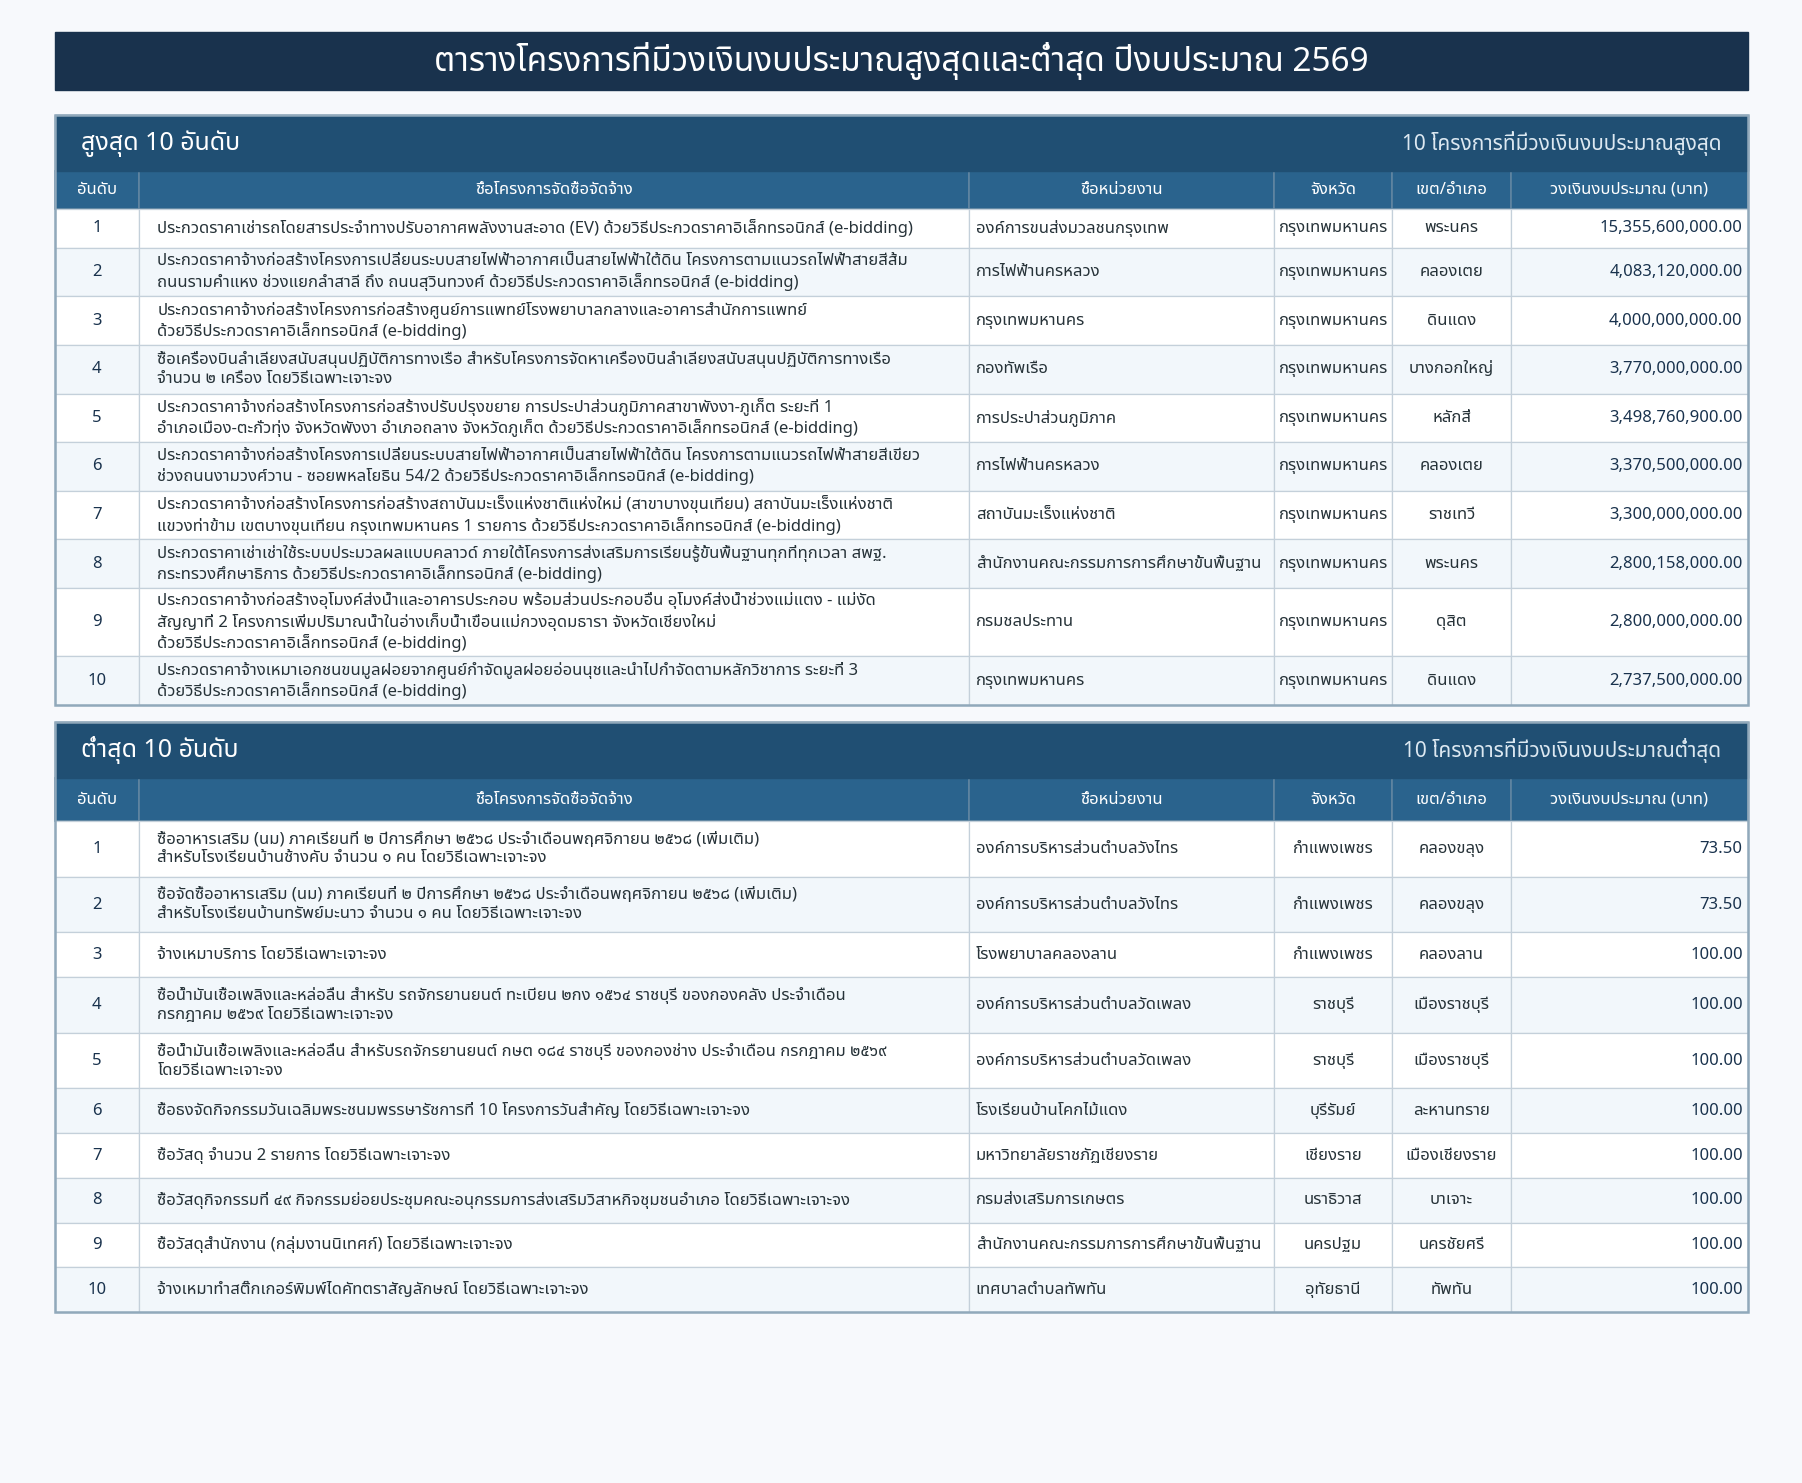

✅ SVG: /tmp/procurement_github_omyreo2f/08_top10_lower10_project_budget_table_2569.svg
✅ PNG: /tmp/procurement_github_omyreo2f/08_top10_lower10_project_budget_table_2569.png


In [24]:
# ============================================================
# TABLE 7 : Top 10 และ Lower 10
# ปรับคอลัมน์ชื่อโครงการให้กว้างและลดจำนวนบรรทัด
# ============================================================

# ปิด Figure ก่อนหน้าเพื่อลดการใช้หน่วยความจำใน Colab
plt.close("all")

svg_file, png_file = figure_files(
    "08_top10_lower10_project_budget_table"
)

# ============================================================
# 2) ค้นหาคอลัมน์
# ============================================================

def find_column(dataframe, keyword):
    for column in dataframe.columns:
        if keyword in str(column):
            return column

    raise KeyError(
        f"ไม่พบคอลัมน์ที่มีคำว่า '{keyword}'"
    )


# ============================================================
# 3) เตรียม DataFrame
# ============================================================

def prepare_project_table(dataframe):
    selected_columns = [
        find_column(dataframe, "อันดับ"),
        find_column(dataframe, "ชื่อโครงการ"),
        find_column(dataframe, "ชื่อหน่วยงาน"),
        find_column(dataframe, "จังหวัด"),
        find_column(dataframe, "เขต/"),
        find_column(dataframe, "วงเงินงบประมาณ")
    ]

    prepared_df = dataframe[
        selected_columns
    ].copy()

    prepared_df.columns = [
        "rank",
        "project_name",
        "agency",
        "province",
        "district",
        "budget"
    ]

    prepared_df["rank"] = pd.to_numeric(
        prepared_df["rank"],
        errors="coerce"
    )

    prepared_df["budget"] = pd.to_numeric(
        prepared_df["budget"],
        errors="coerce"
    )

    return (
        prepared_df
        .sort_values("rank")
        .reset_index(drop=True)
    )


top_table_df = prepare_project_table(
    top10_budget_df
)

lower_table_df = prepare_project_table(
    lower10_budget_df
)


# ============================================================
# 4) ฟังก์ชันจัดข้อความ
# ============================================================

def clean_text(value):
    if pd.isna(value):
        return "-"

    return " ".join(str(value).split())


def character_width(character):
    """
    ประมาณความกว้างของตัวอักษร
    ภาษาอังกฤษและตัวเลขกว้างกว่าตัวอักษรไทยเล็กน้อย
    """
    if character.isascii():
        return 1.35

    return 1.0


def text_width(text):
    return sum(
        character_width(character)
        for character in text
    )


def split_long_word(word, max_width):
    pieces = []
    current = ""

    for character in word:
        candidate = current + character

        if text_width(candidate) <= max_width:
            current = candidate
        else:
            if current:
                pieces.append(current)

            current = character

    if current:
        pieces.append(current)

    return pieces


def smart_wrap(
    value,
    max_width=110,
    max_lines=3
):
    """
    ตัดข้อความโดยพยายามใช้พื้นที่เต็มความกว้างของเซลล์
    และตัดตรงช่องว่างก่อน
    """
    text = clean_text(value)
    words = text.split(" ")

    lines = []
    current_line = ""

    for word in words:
        candidate = (
            word
            if not current_line
            else current_line + " " + word
        )

        if text_width(candidate) <= max_width:
            current_line = candidate
            continue

        if current_line:
            lines.append(current_line)
            current_line = ""

        # กรณีคำภาษาไทยยาวมากและไม่มีช่องว่าง
        if text_width(word) > max_width:
            word_parts = split_long_word(
                word,
                max_width
            )

            for word_part in word_parts[:-1]:
                lines.append(word_part)

            current_line = word_parts[-1]
        else:
            current_line = word

    if current_line:
        lines.append(current_line)

    # จำกัดไม่เกิน 3 บรรทัด
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "…"

    return "\n".join(lines)


def format_rank(value):
    if pd.isna(value):
        return "-"

    return f"{int(value)}"


def format_budget(value):
    if pd.isna(value):
        return "-"

    return f"{value:,.2f}"


# ============================================================
# 5) สร้างข้อความในแต่ละเซลล์
# ============================================================

def create_cell_text(dataframe):
    rows = []

    for _, row in dataframe.iterrows():
        rows.append(
            [
                format_rank(row["rank"]),

                # ใช้ความยาวประมาณ 110 หน่วยต่อบรรทัด
                smart_wrap(
                    row["project_name"],
                    max_width=110,
                    max_lines=3
                ),

                smart_wrap(
                    row["agency"],
                    max_width=38,
                    max_lines=3
                ),

                smart_wrap(
                    row["province"],
                    max_width=18,
                    max_lines=2
                ),

                smart_wrap(
                    row["district"],
                    max_width=18,
                    max_lines=2
                ),

                format_budget(row["budget"])
            ]
        )

    return rows


top_cell_text = create_cell_text(
    top_table_df
)

lower_cell_text = create_cell_text(
    lower_table_df
)


# ============================================================
# 6) หัวคอลัมน์และความกว้าง
# ============================================================

column_labels = [
    "อันดับ",
    "ชื่อโครงการจัดซื้อจัดจ้าง",
    "ชื่อหน่วยงาน",
    "จังหวัด",
    "เขต/อำเภอ",
    "วงเงินงบประมาณ (บาท)"
]

# รวมเท่ากับ 1.00
# เพิ่มคอลัมน์ชื่อโครงการเป็น 49%
column_widths = [
    0.05,   # อันดับ
    0.49,   # ชื่อโครงการ
    0.18,   # ชื่อหน่วยงาน
    0.07,   # จังหวัด
    0.07,   # เขต/อำเภอ
    0.14    # วงเงิน
]


# ============================================================
# 7) สี
# ============================================================

figure_background = "#F7F9FC"

title_color = "#19324D"
section_color = "#204F73"
header_color = "#2A638D"

header_border = "#6085A1"
cell_border = "#C4D0DA"

body_white = "#FFFFFF"
body_blue = "#F2F7FB"

text_color = "#263238"
budget_text_color = "#19324D"
secondary_text_color = "#667085"


# ============================================================
# 8) สร้าง Figure
# ลดความสูงลงจากรุ่นเดิม
# ============================================================

fig, ax = plt.subplots(
    figsize=(23, 19),
    facecolor=figure_background
)

ax.set_facecolor(figure_background)
ax.axis("off")


# ============================================================
# 9) ตำแหน่งองค์ประกอบ
# ============================================================

left = 0.025
full_width = 0.95

title_y = 0.945
title_height = 0.040

top_section_y = 0.890
section_height = 0.038

top_table_y = 0.525
table_height = 0.365

lower_section_y = 0.475
lower_table_y = 0.110

note_y = 0.035
note_height = 0.045


# ============================================================
# 10) ชื่อตารางหลัก
# ============================================================

ax.add_patch(
    Rectangle(
        (left, title_y),
        full_width,
        title_height,
        transform=ax.transAxes,
        facecolor=title_color,
        edgecolor=title_color
    )
)

ax.text(
    0.5,
    title_y + title_height / 2,
    (
        "ตารางโครงการที่มีวงเงินงบประมาณสูงสุดและต่ำสุด "
        f"ปีงบประมาณ {YEAR}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="white"
)


# ============================================================
# 11) หัวข้อ Top 10 และ Lower 10
# ============================================================

def add_section_header(y, title, subtitle):
    ax.add_patch(
        Rectangle(
            (left, y),
            full_width,
            section_height,
            transform=ax.transAxes,
            facecolor=section_color,
            edgecolor=section_color
        )
    )

    ax.text(
        left + 0.015,
        y + section_height / 2,
        title,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    ax.text(
        left + full_width - 0.015,
        y + section_height / 2,
        subtitle,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=15,
        color="#DCE8F1"
    )


add_section_header(
    top_section_y,
    "สูงสุด 10 อันดับ",
    "10 โครงการที่มีวงเงินงบประมาณสูงสุด"
)

add_section_header(
    lower_section_y,
    "ต่ำสุด 10 อันดับ",
    "10 โครงการที่มีวงเงินงบประมาณต่ำสุด"
)


# ============================================================
# 12) คำนวณความสูงของแต่ละแถว
# ============================================================

def calculate_row_heights(cell_text):
    row_weights = [1.30]

    for row in cell_text:
        maximum_lines = max(
            str(value).count("\n") + 1
            for value in row
        )

        row_weight = max(
            1.35,
            1.0 + (maximum_lines - 1) * 0.68
        )

        row_weights.append(row_weight)

    total_weight = sum(row_weights)

    return [
        weight / total_weight
        for weight in row_weights
    ]


# ============================================================
# 13) สร้างตารางแบบ Dynamic Height
# ============================================================

def draw_dynamic_table(cell_text, table_y):
    row_heights = calculate_row_heights(
        cell_text
    )

    table = Table(
        ax,
        bbox=[
            left,
            table_y,
            full_width,
            table_height
        ]
    )

    # หัวคอลัมน์
    for column_index, column_label in enumerate(
        column_labels
    ):
        cell = table.add_cell(
            row=0,
            col=column_index,
            width=column_widths[column_index],
            height=row_heights[0],
            text=column_label,
            loc="center",
            facecolor=header_color,
            edgecolor=header_border
        )

        cell.set_linewidth(1.2)
        cell.PAD = 0.022

        text = cell.get_text()
        text.set_color("white")
        text.set_fontsize(15)
        text.set_fontweight("bold")
        text.set_ha("center")
        text.set_va("center")

    # ข้อมูล
    for row_index, row_values in enumerate(
        cell_text,
        start=1
    ):
        row_color = (
            body_white
            if row_index % 2 == 1
            else body_blue
        )

        for column_index, value in enumerate(
            row_values
        ):
            if column_index in [0, 3, 4]:
                location = "center"
            elif column_index == 5:
                location = "right"
            else:
                location = "left"

            cell = table.add_cell(
                row=row_index,
                col=column_index,
                width=column_widths[column_index],
                height=row_heights[row_index],
                text=value,
                loc=location,
                facecolor=row_color,
                edgecolor=cell_border
            )

            cell.set_linewidth(0.9)
            cell.PAD = 0.022

            text = cell.get_text()
            text.set_va("center")
            text.set_linespacing(1.23)
            text.set_color(text_color)

            if column_index == 0:
                text.set_fontsize(15)
                text.set_fontweight("bold")
                text.set_color(title_color)
                text.set_ha("center")

            elif column_index == 1:
                # เพิ่มขนาดชื่อโครงการ
                text.set_fontsize(15)
                text.set_ha("left")

            elif column_index == 2:
                text.set_fontsize(15)
                text.set_ha("left")

            elif column_index in [3, 4]:
                text.set_fontsize(15)
                text.set_ha("center")

            elif column_index == 5:
                text.set_fontsize(15)
                text.set_fontweight("bold")
                text.set_color(budget_text_color)
                text.set_ha("right")

    ax.add_table(table)

    return table


top_table = draw_dynamic_table(
    top_cell_text,
    top_table_y
)

lower_table = draw_dynamic_table(
    lower_cell_text,
    lower_table_y
)


# ============================================================
# 14) เส้นขอบรอบ Section
# ============================================================

for table_y, section_y in [
    (top_table_y, top_section_y),
    (lower_table_y, lower_section_y)
]:
    ax.add_patch(
        Rectangle(
            (left, table_y),
            full_width,
            section_y + section_height - table_y,
            transform=ax.transAxes,
            facecolor="none",
            edgecolor="#91A9BB",
            linewidth=1.8
        )
    )


# ============================================================
# 15) หมายเหตุ
# ============================================================

# ax.add_patch(
#     Rectangle(
#         (left, note_y),
#         full_width,
#         note_height,
#         transform=ax.transAxes,
#         facecolor="#EAF2F8",
#         edgecolor="#9EB5C6",
#         linewidth=1.2
#     )
# )

# ax.text(
#     0.5,
#     note_y + note_height / 2,
#     (
#         "หมายเหตุ: ---- "
#     ),
#     transform=ax.transAxes,
#     ha="center",
#     va="center",
#     fontsize=15,
#     color=secondary_text_color
# )


# ============================================================
# 16) บันทึก SVG และ PNG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 17) แสดงผล
# ============================================================

plt.show()
plt.close(fig)

print("✅ SVG:", svg_file)
print("✅ PNG:", png_file)


## Analysis 8 — Map plot


In [25]:
# ============================================================
# โหลดแผนที่ประเทศไทยระดับจังหวัดจาก GeoJSON บน GitHub
# ============================================================

import geopandas as gpd

# URL ของไฟล์ GeoJSON ขอบเขต 77 จังหวัดของประเทศไทย
geojson_url = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/master/provinces.geojson"
)

# Cache ไฟล์ไว้ใน Colab Runtime เพื่อไม่ต้องดาวน์โหลดใหม่เมื่อรันซ้ำ
geojson_cache_path = str(RUNTIME_DIR / "thailand_provinces.geojson")

if not os.path.exists(geojson_cache_path):
    urllib.request.urlretrieve(geojson_url, geojson_cache_path)

# อ่านเฉพาะไฟล์ Cache ที่ตรวจสอบแล้ว
thai_map = gpd.read_file(geojson_cache_path)

# ตรวจสอบขนาดข้อมูล
print("จำนวนจังหวัด:", len(thai_map))

# ตรวจสอบชื่อ column
print("\nColumns:")
print(thai_map.columns.tolist())

# ดูข้อมูลตัวอย่าง
display(thai_map.head())


จำนวนจังหวัด: 77

Columns:
['pro_code', 'pro_th', 'pro_en', 'reg_nesdb', 'reg_royin', 'perimeter', 'area_sqkm', 'geometry']


,pro_code,pro_th,pro_en,reg_nesdb,reg_royin,perimeter,area_sqkm,geometry
0,56,พะเยา,Phayao,UpperNorth,North,442.838839,6189.635950,"MULTIPOLYGON (((100.27194 18.81875, 100.23968 ..."
1,57,เชียงราย,Chiang Rai,UpperNorth,North,668.416725,11583.012365,"MULTIPOLYGON (((99.53646 19.16314, 99.55039 19..."
2,54,แพร่,Phrae,UpperNorth,North,515.746817,6484.532497,"MULTIPOLYGON (((99.49711 17.77145, 99.48698 17..."
3,55,น่าน,Nan,UpperNorth,North,674.017891,12165.114094,"MULTIPOLYGON (((100.5524 18.03491, 100.55055 1..."
4,63,ตาก,Tak,LowwerNorth,West,1350.975407,17318.857031,"MULTIPOLYGON (((99.10549 16.0496, 99.08806 16...."


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# MAP : วงเงินงบประมาณรวมรายจังหวัด อันดับ 2–77
# พร้อมลูกศรชี้จังหวัดที่มีวงเงินสูงสุดของแต่ละภาค
#
# - ไม่รวมกรุงเทพมหานครในการคำนวณสเกลสี
# ============================================================

import unicodedata


# ============================================================
# 1) ตรวจสอบตัวแปรที่จำเป็น
# ============================================================

if "YEAR" not in globals():
    raise NameError(
        "ไม่พบตัวแปร YEAR กรุณารันเซลล์ PARAMETERS ก่อน"
    )

if "province_df" not in globals():
    raise NameError(
        "ไม่พบ province_df กรุณารันส่วน Analysis 3 ก่อน"
    )

required_province_columns = [
    "จังหวัด",
    "วงเงินรวม (บาท)"
]

missing_columns = [
    column
    for column in required_province_columns
    if column not in province_df.columns
]

if missing_columns:
    raise KeyError(
        "province_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 2) Memory-Safe Cleanup และตรวจสอบ RAM
# ============================================================

# ปิด Figure ที่อาจค้างจากกราฟก่อนหน้า
plt.close("all")
gc.collect()

try:
    import psutil

    memory_status = psutil.virtual_memory()

    print(
        f"RAM ก่อนสร้างแผนที่: "
        f"{memory_status.percent:.1f}%"
    )

    if memory_status.percent >= 80:

        gc.collect()
        memory_status = psutil.virtual_memory()

        if memory_status.percent >= 80:
            raise MemoryError(
                "RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป "
                "แนะนำให้ Restart Runtime ก่อนสร้างแผนที่"
            )

except ImportError:
    print(
        "ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ"
    )


# ============================================================
# 3) กำหนดตำแหน่งบันทึกไฟล์
# ============================================================

# ใช้ฟังก์ชันส่วนกลางเพื่อสร้างชื่อไฟล์ตาม YEAR โดยอัตโนมัติ
svg_file, png_file = figure_files(
    "09_thailand_province_budget_map_highlights"
)


# ============================================================
# 4) ใช้ GeoJSON ที่โหลดและ Cache ไว้ใน Cell ก่อนหน้า
# ============================================================

if "thai_map" not in globals():
    raise NameError(
        "ไม่พบ thai_map กรุณารัน Cell โหลดแผนที่ก่อน"
    )

required_map_columns = [
    "pro_th",
    "reg_royin",
    "geometry"
]

missing_map_columns = [
    column
    for column in required_map_columns
    if column not in thai_map.columns
]

if missing_map_columns:
    raise KeyError(
        "GeoJSON ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_map_columns)
    )

print(
    f"จำนวนจังหวัดใน GeoJSON: "
    f"{len(thai_map):,} จังหวัด"
)


# ============================================================
# 5) ฟังก์ชันปรับชื่อจังหวัดก่อน Merge
# ============================================================

def normalize_province_name(value):
    """
    ปรับชื่อจังหวัดให้อยู่ในรูปแบบเดียวกัน
    เพื่อลดปัญหาช่องว่างและ Unicode ที่แตกต่างกัน
    """

    if pd.isna(value):
        return pd.NA

    province_name = unicodedata.normalize(
        "NFC",
        str(value)
    ).strip()

    # ลบคำว่า "จังหวัด" หากอยู่ด้านหน้า
    if province_name.startswith("จังหวัด"):

        province_name = province_name.removeprefix(
            "จังหวัด"
        ).strip()

    # รองรับชื่อจังหวัดที่อาจเขียนแตกต่างกัน
    province_aliases = {
        "กรุงเทพ": "กรุงเทพมหานคร",
        "กรุงเทพฯ": "กรุงเทพมหานคร",
        "กทม.": "กรุงเทพมหานคร",
        "อยุธยา": "พระนครศรีอยุธยา"
    }

    return province_aliases.get(
        province_name,
        province_name
    )


# ============================================================
# 6) เตรียมข้อมูลงบประมาณเฉพาะคอลัมน์ที่ใช้
# ============================================================

# province_df มีเพียง 77 แถว
# เลือกเฉพาะคอลัมน์ที่จำเป็นเพื่อลดการใช้หน่วยความจำ
province_budget_small = province_df[
    [
        "จังหวัด",
        "วงเงินรวม (บาท)"
    ]
].copy()

province_budget_small["province_key"] = (
    province_budget_small["จังหวัด"]
    .map(normalize_province_name)
)

province_budget_small["total_budget"] = pd.to_numeric(
    province_budget_small["วงเงินรวม (บาท)"],
    errors="coerce"
)

province_budget_small = (
    province_budget_small[
        [
            "province_key",
            "total_budget"
        ]
    ]
    .dropna(
        subset=[
            "province_key",
            "total_budget"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7) ตัดกรุงเทพมหานครออกจากการคำนวณ
# ============================================================

excluded_province = "กรุงเทพมหานคร"

province_budget_small = (
    province_budget_small.loc[
        province_budget_small["province_key"]
        != excluded_province
    ]
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"จำนวนจังหวัดที่ใช้คำนวณสเกลสี: "
    f"{len(province_budget_small):,} จังหวัด"
)

print(
    "ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี "
    "เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก"
)


# ============================================================
# 8) เตรียมข้อมูลแผนที่เฉพาะคอลัมน์ที่ใช้
# ============================================================

map_small = thai_map[
    [
        "pro_th",
        "reg_royin",
        "geometry"
    ]
].copy()

map_small["province_key"] = (
    map_small["pro_th"]
    .map(normalize_province_name)
)

map_small["region"] = (
    map_small["reg_royin"]
    .astype("string")
    .str.strip()
)


# ============================================================
# 9) ตรวจ Duplicate Keys ก่อน Merge
# ป้องกัน Many-to-Many Row Explosion
# ============================================================

duplicate_budget_keys = (
    province_budget_small.loc[
        province_budget_small["province_key"].duplicated(
            keep=False
        ),
        "province_key"
    ]
    .dropna()
    .unique()
    .tolist()
)

duplicate_map_keys = (
    map_small.loc[
        map_small["province_key"].duplicated(
            keep=False
        ),
        "province_key"
    ]
    .dropna()
    .unique()
    .tolist()
)

if duplicate_budget_keys:
    raise ValueError(
        "พบชื่อจังหวัดซ้ำใน province_df: "
        + ", ".join(duplicate_budget_keys)
    )

if duplicate_map_keys:
    raise ValueError(
        "พบชื่อจังหวัดซ้ำใน GeoJSON: "
        + ", ".join(duplicate_map_keys)
    )


# ============================================================
# 10) ตรวจชื่อจังหวัดที่จับคู่ไม่ได้
# ============================================================

budget_provinces = set(
    province_budget_small["province_key"]
)

map_provinces = set(
    map_small["province_key"]
)

not_found_in_map = sorted(
    budget_provinces - map_provinces
)

# ไม่นับกรุงเทพมหานครเป็นจังหวัดที่ไม่มีข้อมูล
no_budget_data = sorted(
    (map_provinces - budget_provinces)
    - {excluded_province}
)

if not_found_in_map:
    print(
        "⚠️ จังหวัดในข้อมูลงบประมาณที่ไม่พบในแผนที่:",
        not_found_in_map
    )

if no_budget_data:
    print(
        "⚠️ จังหวัดในแผนที่ที่ไม่มีข้อมูลงบประมาณ:",
        no_budget_data
    )


# ============================================================
# 11) Merge ข้อมูลงบประมาณกับแผนที่
# ============================================================

thai_budget_map = map_small.merge(
    province_budget_small,
    on="province_key",
    how="left",
    validate="one_to_one"
)

thai_budget_map = gpd.GeoDataFrame(
    thai_budget_map,
    geometry="geometry",
    crs=thai_map.crs
)

matched_provinces = (
    thai_budget_map["total_budget"]
    .notna()
    .sum()
)

print(
    f"จับคู่ข้อมูลสำเร็จ: "
    f"{matched_provinces:,} จังหวัด"
)


# ============================================================
# 12) กำหนดสเกลสี
# ============================================================

positive_budget = thai_budget_map.loc[
    thai_budget_map["total_budget"] > 0,
    "total_budget"
]

if positive_budget.empty:
    raise ValueError(
        "ไม่พบวงเงินรวมที่มากกว่า 0 สำหรับสร้างแผนที่"
    )

minimum_budget = positive_budget.min()
maximum_budget = positive_budget.max()

# สีฟ้าอ่อน → น้ำเงินเข้ม
budget_cmap = LinearSegmentedColormap.from_list(
    "province_budget_blue",
    [
        "#EDF6FC",
        "#C8E1F1",
        "#8ABBD6",
        "#4D91B8",
        "#23658F",
        "#123B5D"
    ]
)

# กรุงเทพมหานครและจังหวัดที่ไม่มีข้อมูลเป็นสีเทา
budget_cmap.set_bad("#D9DEE5")

if minimum_budget == maximum_budget:
    maximum_budget = minimum_budget + 1

color_norm = Normalize(
    vmin=minimum_budget,
    vmax=maximum_budget
)

colorbar_ticks = np.linspace(
    minimum_budget,
    maximum_budget,
    num=6
)


# ============================================================
# 13) เลือกจังหวัดวงเงินสูงสุดของแต่ละภาค
# ============================================================

highlight_source = thai_budget_map.loc[
    (
        thai_budget_map["province_key"]
        != excluded_province
    )
    & thai_budget_map["total_budget"].notna()
    & thai_budget_map["region"].notna()
].copy()

# เรียงวงเงินจากมากไปน้อย
# แล้วเลือกจังหวัดอันดับแรกของแต่ละภาค
regional_highlights = (
    highlight_source
    .sort_values(
        "total_budget",
        ascending=False
    )
    .drop_duplicates(
        subset="region",
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# 14) แปลงชื่อภูมิภาคเป็นภาษาไทย
# ============================================================

region_name_mapping = {
    "north": "ภาคเหนือ",
    "northeast": "ภาคตะวันออกเฉียงเหนือ",
    "north east": "ภาคตะวันออกเฉียงเหนือ",
    "northeastern": "ภาคตะวันออกเฉียงเหนือ",
    "central": "ภาคกลาง",
    "east": "ภาคตะวันออก",
    "eastern": "ภาคตะวันออก",
    "west": "ภาคตะวันตก",
    "western": "ภาคตะวันตก",
    "south": "ภาคใต้",
    "southern": "ภาคใต้"
}


def get_thai_region_name(region_value):

    region_key = str(region_value).strip().lower()

    return region_name_mapping.get(
        region_key,
        str(region_value)
    )


regional_highlights["region_thai"] = (
    regional_highlights["region"]
    .map(get_thai_region_name)
)

print(
    f"จำนวนภูมิภาคที่พบ: "
    f"{len(regional_highlights):,} ภูมิภาค"
)


# ============================================================
# 15) สร้างแผนที่
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 13),
    facecolor="#F7F9FC"
)

ax.set_facecolor("#F7F9FC")

thai_budget_map.plot(
    column="total_budget",
    cmap=budget_cmap,
    norm=color_norm,
    linewidth=0.70,
    edgecolor="#FFFFFF",
    missing_kwds={
        "color": "#D9DEE5",
        "edgecolor": "#FFFFFF",
        "label": "ไม่รวมในการคำนวณ"
    },
    ax=ax
)

ax.set_axis_off()
ax.set_aspect("equal")


# ============================================================
# 16) กำหนดตำแหน่งกล่องข้อความนอกแผนที่
# ============================================================

# ใช้พิกัดแบบ Axes Fraction
# X < 0 หมายถึงอยู่นอกแผนที่ทางซ้าย
# X > 1 หมายถึงอยู่นอกแผนที่ทางขวา
region_box_positions = {
    "ภาคเหนือ": (-0.10, 0.83),
    "ภาคตะวันออกเฉียงเหนือ": (1.10, 0.76),
    "ภาคกลาง": (-0.12, 0.56),
    "ภาคตะวันออก": (1.12, 0.51),
    "ภาคตะวันตก": (-0.12, 0.31),
    "ภาคใต้": (1.10, 0.18)
}

# ตำแหน่งสำรองหากชื่อภูมิภาคไม่ตรงกับ Mapping
fallback_box_positions = [
    (-0.10, 0.83),
    (1.10, 0.76),
    (-0.12, 0.56),
    (1.12, 0.51),
    (-0.12, 0.31),
    (1.10, 0.18)
]

arrow_color = "#9A6700"
box_border_color = "#E1A72D"


# ============================================================
# 17) วาดเฉพาะลูกศรและกล่องข้อความ
# ไม่มีจุด Scatter
# ============================================================

for highlight_index, (_, row) in enumerate(
    regional_highlights.iterrows()
):

    region_thai = row["region_thai"]

    # ใช้จุดที่อยู่ภายในพื้นที่จังหวัดเป็นปลายลูกศร
    anchor_point = row.geometry.representative_point()

    x_position = anchor_point.x
    y_position = anchor_point.y

    box_position = region_box_positions.get(
        region_thai,
        fallback_box_positions[
            highlight_index % len(fallback_box_positions)
        ]
    )

    # จัดข้อความและความโค้งของลูกศรตามด้านของกล่อง
    if box_position[0] < 0:

        horizontal_alignment = "right"
        curve_direction = 0.10

    else:

        horizontal_alignment = "left"
        curve_direction = -0.10

    ax.annotate(
        (
            f"{region_thai}\n"
            f"{row['province_key']}\n"
            f"{row['total_budget'] / 1_000_000_000:,.2f} "
            "พันล้านบาท"
        ),

        # ปลายลูกศร
        xy=(
            x_position,
            y_position
        ),
        xycoords="data",

        # กล่องข้อความอยู่นอกพื้นที่แผนที่
        xytext=box_position,
        textcoords="axes fraction",

        ha=horizontal_alignment,
        va="center",
        fontsize=11.5,
        fontweight="bold",
        color="#19324D",
        linespacing=1.35,

        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "#FFFFFF",
            "edgecolor": box_border_color,
            "linewidth": 1.5,
            "alpha": 0.97
        },

        arrowprops={
            "arrowstyle": "-|>",
            "color": arrow_color,
            "linewidth": 1.5,
            "shrinkA": 6,
            "shrinkB": 2,
            "connectionstyle": (
                f"arc3,rad={curve_direction}"
            )
        },

        # อนุญาตให้กล่องข้อความอยู่นอก Axes
        annotation_clip=False,
        zorder=7
    )


# ============================================================
# 18) ชื่อกราฟ
# ============================================================

fig.suptitle(
    (
        "วงเงินงบประมาณรวมรายจังหวัด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=24,
    fontweight="bold",
    color="#19324D",
    y=0.965 ###########################################################
)

ax.set_title(
    (
        "จังหวัดอันดับ 2–77 • ไม่รวมกรุงเทพมหานคร\n"
        "สีเข้มหมายถึงวงเงินรวมสูง • สีอ่อนหมายถึงวงเงินรวมต่ำ"
    ),
    fontsize=14,
    color="#5E6B78",
    pad=-200,         #########################
    linespacing=1.5
)


# ============================================================
# 19) เว้นพื้นที่รอบแผนที่สำหรับกล่องข้อความ
# ============================================================

plt.subplots_adjust(
    left=0.25,
    right=0.75,
    top=0.89,
    bottom=0.17
)


# ============================================================
# 20) Colorbar แนวนอน
# ============================================================

scalar_mappable = plt.cm.ScalarMappable(
    norm=color_norm,
    cmap=budget_cmap
)

scalar_mappable.set_array([])

# Colorbar อยู่ด้านล่าง จึงไม่ทับกล่องข้อความ
colorbar_axis = fig.add_axes(
    [
        0.28,   # ตำแหน่งจากด้านซ้าย
        0.125,  # ตำแหน่งจากด้านล่าง  #############################
        0.44,   # ความกว้าง
        0.022   # ความสูง
    ]
)

colorbar = fig.colorbar(
    scalar_mappable,
    cax=colorbar_axis,
    orientation="horizontal"
)

colorbar.set_ticks(colorbar_ticks)

colorbar.ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value / 1_000_000_000:,.2f}"
    )
)

colorbar.ax.tick_params(
    labelsize=11,
    colors="#334155",
    length=4,
    pad=4
)

colorbar.outline.set_edgecolor("#9AA9B7")
colorbar.outline.set_linewidth(0.8)

colorbar.set_label(
    "วงเงินรวม (พันล้านบาท)",
    fontsize=12.5,
    fontweight="bold",
    color="#334155",
    labelpad=8
)


# ============================================================
# 21) หมายเหตุ
# ============================================================

fig.text(
    0.50,
    0.035,
    (
        "หมายเหตุ: ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี "
        "เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก\n"
        "จังหวัดที่มีลูกศรชี้คือจังหวัดที่มีวงเงินรวมสูงสุดของแต่ละภาค "
    ),
    ha="center",
    va="center",
    fontsize=11.2,
    color="#667085",
    linespacing=1.5
)


# ============================================================
# 22) แสดงตารางจังหวัดเด่นเพื่อตรวจสอบ
# ============================================================

highlight_summary = regional_highlights[
    [
        "region_thai",
        "province_key",
        "total_budget"
    ]
].copy()

highlight_summary = highlight_summary.rename(
    columns={
        "region_thai": "ภูมิภาค",
        "province_key": "จังหวัด",
        "total_budget": "วงเงินรวม (บาท)"
    }
)

display(
    highlight_summary.style.format({
        "วงเงินรวม (บาท)": "{:,.2f}"
    })
)


# ============================================================
# 23) บันทึก SVG และ PNG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

# DPI 220 เพื่อรักษาความคมชัดและควบคุม RAM
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()


# ============================================================
# 24) Cleanup
# ============================================================

plt.close(fig)

del province_budget_small
del map_small
del thai_budget_map
del positive_budget
del highlight_source
del regional_highlights
del highlight_summary
del scalar_mappable
del colorbar
del colorbar_axis
# เก็บ thai_map ไว้ใช้กับแผนที่โครงการก่อสร้างและแผนที่ Net
del fig
del ax

gc.collect()

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("✅ ปิด Figure และลบ DataFrame ชั่วคราวแล้ว")
print("✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้")


RAM ก่อนสร้างแผนที่: 16.9%
จำนวนจังหวัดใน GeoJSON: 77 จังหวัด
จำนวนจังหวัดที่ใช้คำนวณสเกลสี: 76 จังหวัด
ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก
จับคู่ข้อมูลสำเร็จ: 76 จังหวัด
จำนวนภูมิภาคที่พบ: 6 ภูมิภาค


,ภูมิภาค,จังหวัด,วงเงินรวม (บาท)
0,ภาคกลาง,นนทบุรี,"32,912,311,066.08"
1,ภาคตะวันออก,ชลบุรี,"30,758,211,317.77"
2,ภาคเหนือ,เชียงใหม่,"30,109,703,819.88"
3,ภาคตะวันออกเฉียงเหนือ,นครราชสีมา,"28,585,611,015.71"
4,ภาคใต้,สงขลา,"21,597,130,318.73"
5,ภาคตะวันตก,ราชบุรี,"11,886,660,461.95"


## สรุปวงเงินตามภาระกิจ


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# ANALYSIS 8 : สรุปวงเงินงบประมาณตามหมวดภารกิจของรัฐ
# ============================================================
#
# วิธีการ:
# 1. ใช้ agency_df ซึ่งสรุปข้อมูลระดับหน่วยงานจาก project_overview_df
# 2. ใช้ "สังกัดหลัก" ที่พบมากที่สุดของแต่ละหน่วยงานจาก Analysis 4
# 3. จำแนกหมวดจาก "สังกัด" และ "ชื่อหน่วยงาน"
# 4. รวมจำนวนโครงการและวงเงินตามหมวดภารกิจ
#
# หมายเหตุ:
# ผลลัพธ์เป็นการจำแนกตามภารกิจหลักของหน่วยงาน
# ไม่ใช่การอ่านรายละเอียดของแต่ละโครงการ
#
# ============================================================

import json


# ============================================================
# 1) ตรวจสอบตัวแปรที่จำเป็น
# ============================================================

if "YEAR" not in globals():
    raise NameError("ไม่พบตัวแปร YEAR กรุณารันเซลล์ PARAMETERS ก่อน")

if "agency_df" not in globals():
    raise NameError(
        "ไม่พบ agency_df กรุณารัน Analysis 4 "
        "ก่อนรันส่วนจำแนกหมวดภารกิจ"
    )

required_agency_columns = [
    "ชื่อหน่วยงาน",
    "สังกัด",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)"
]

missing_agency_columns = [
    column
    for column in required_agency_columns
    if column not in agency_df.columns
]

if missing_agency_columns:
    raise KeyError(
        "agency_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_agency_columns)
        + " กรุณารัน Analysis 4 เวอร์ชันล่าสุด"
    )


# ============================================================
# 2) Cleanup ผลลัพธ์ชั่วคราวจากการรันครั้งก่อน
# ============================================================

# รองรับการรันเซลล์นี้ซ้ำใน Runtime เดิม โดยไม่ลบ project_overview_df หรือ agency_df
previous_temporary_objects = [
    "department_budget_df",
    "mapping_export_df",
    "agency_text",
    "affiliation_text",
    "combined_text",
    "unclassified_mask",
    "low_confidence_mask",
    "missing_affiliation_mask",
    "duplicate_agency_mask",
    "function_budget_summary_df",
    "function_groups"
]

for object_name in previous_temporary_objects:
    globals().pop(object_name, None)

gc.collect()


# ============================================================
# 3) ตรวจสอบ RAM ก่อนเริ่มคำนวณ
# ============================================================

try:
    import psutil

    memory_status = psutil.virtual_memory()
    print(f"RAM ก่อนเริ่มจำแนกหมวดภารกิจ: {memory_status.percent:.1f}%")

    if memory_status.percent >= 80:
        print(
            "⚠️ RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป — "
            "ขั้นตอนนี้จะใช้เฉพาะ agency_df ซึ่งเป็นตารางสรุปขนาดเล็ก "
            "และจะไม่สร้างสำเนา project_overview_df"
        )

except ImportError:
    print("ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ")


# ============================================================
# 4) เตรียมข้อมูลสรุประดับหน่วยงาน
# ============================================================

# agency_df มีขนาดเล็กกว่าข้อมูลโครงการหลายล้านแถวมาก
# จึงคัดลอกเฉพาะ 4 คอลัมน์ที่จำเป็นสำหรับการจัดหมวดภารกิจ
department_budget_df = agency_df[required_agency_columns].copy()

department_budget_df["ชื่อหน่วยงาน"] = (
    department_budget_df["ชื่อหน่วยงาน"]
    .astype("string")
    .str.strip()
)

department_budget_df["สังกัด"] = (
    department_budget_df["สังกัด"]
    .astype("string")
    .str.strip()
)

department_budget_df["จำนวนโครงการ"] = pd.to_numeric(
    department_budget_df["จำนวนโครงการ"],
    errors="coerce"
).fillna(0)

department_budget_df["วงเงินรวม (บาท)"] = pd.to_numeric(
    department_budget_df["วงเงินรวม (บาท)"],
    errors="coerce"
).fillna(0)


# ============================================================
# 5) ตรวจสอบชื่อหน่วยงานก่อนจำแนก
# ============================================================

blank_agency_mask = (
    department_budget_df["ชื่อหน่วยงาน"].isna()
    | department_budget_df["ชื่อหน่วยงาน"].eq("")
)

if blank_agency_mask.any():
    raise ValueError("พบชื่อหน่วยงานว่างใน agency_df")

duplicate_agency_mask = (
    department_budget_df["ชื่อหน่วยงาน"]
    .duplicated(keep=False)
)

if duplicate_agency_mask.any():
    raise ValueError(
        "พบชื่อหน่วยงานซ้ำใน agency_df "
        "กรุณาตรวจสอบขั้นตอน Analysis 4"
    )


# ============================================================
# 6) จัดการหน่วยงานที่ไม่มีข้อมูลสังกัด
# ============================================================

missing_affiliation_mask = (
    department_budget_df["สังกัด"].isna()
    | department_budget_df["สังกัด"].eq("")
    | department_budget_df["สังกัด"].eq("ไม่พบข้อมูลสังกัด")
)

missing_affiliation_agency_count = int(missing_affiliation_mask.sum())

department_budget_df.loc[
    missing_affiliation_mask,
    "สังกัด"
] = "ไม่พบข้อมูลสังกัด"

print(
    f"หน่วยงานที่ไม่มีข้อมูลสังกัดใน project_overview: "
    f"{missing_affiliation_agency_count:,} หน่วยงาน"
)


# ============================================================
# 7) ยืนยันจำนวนแถวก่อนจำแนก
# ============================================================

if len(department_budget_df) != agency_df["ชื่อหน่วยงาน"].nunique():
    raise ValueError("จำนวนหน่วยงานไม่ตรงกันหลังเตรียมข้อมูล")

print(f"เตรียมข้อมูลสำเร็จ: {len(department_budget_df):,} หน่วยงาน")


# ============================================================
# 8) เตรียมเข้าสู่กฎจำแนกหมวดภารกิจ
# ============================================================

# ============================================================
# 9) กำหนดลำดับหมวดภารกิจและสี
# ============================================================

function_order = [
    "การเศรษฐกิจ",
    "การรักษาความสงบภายใน",
    "การป้องกันประเทศ",
    "การบริหารทั่วไปของรัฐ",
    "การสังคมสงเคราะห์",
    "การศึกษา",
    "การศาสนา วัฒนธรรมและนันทนาการ",
    "การสาธารณสุข",
    "การพัฒนาและชุมชน"
]

function_colors = {
    "การเศรษฐกิจ": "#FFD000",
    "การรักษาความสงบภายใน": "#20C777",
    "การป้องกันประเทศ": "#77DDA2",
    "การบริหารทั่วไปของรัฐ": "#566477",
    "การสังคมสงเคราะห์": "#8C6BB1",
    "การศึกษา": "#FFB000",
    "การศาสนา วัฒนธรรมและนันทนาการ": "#555555",
    "การสาธารณสุข": "#FF6D24",
    "การพัฒนาและชุมชน": "#3A9B68"
}


# ============================================================
# 10) เตรียมข้อความสำหรับจำแนก
# ============================================================

agency_text = (
    department_budget_df["ชื่อหน่วยงาน"]
    .astype("string")
    .fillna("")
)

affiliation_text = (
    department_budget_df["สังกัด"]
    .astype("string")
    .fillna("")
)

combined_text = (
    agency_text
    + " "
    + affiliation_text
)

department_budget_df["function_category"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)

department_budget_df["classification_method"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)

department_budget_df["confidence"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)


# ============================================================
# 11) ฟังก์ชันกำหนดหมวดโดยไม่เขียนทับกฎที่มีลำดับสูงกว่า
# ============================================================

def assign_function_category(
    condition,
    category,
    method,
    confidence
):

    available_mask = (
        department_budget_df[
            "function_category"
        ].isna()
    )

    final_mask = (
        condition.fillna(False)
        & available_mask
    )

    department_budget_df.loc[
        final_mask,
        "function_category"
    ] = category

    department_budget_df.loc[
        final_mask,
        "classification_method"
    ] = method

    department_budget_df.loc[
        final_mask,
        "confidence"
    ] = confidence


# ============================================================
# 12) จำแนกจากประเภทสังกัดโดยตรง
# ============================================================

assign_function_category(
    affiliation_text.eq(
        "ส่วนราชการประเภทสถานพยาบาล"
    ),
    "การสาธารณสุข",
    "จำแนกจากประเภทสังกัดโดยตรง",
    "สูง"
)

assign_function_category(
    affiliation_text.eq(
        "ส่วนราชการประเภทสถานศึกษา"
    ),
    "การศึกษา",
    "จำแนกจากประเภทสังกัดโดยตรง",
    "สูง"
)


# ============================================================
# 13) จำแนกจากชื่อหน่วยงานและสังกัด
# ============================================================

# การสาธารณสุข
health_pattern = (
    r"โรงพยาบาล|สาธารณสุข|การแพทย์|แพทยสภา|"
    r"ควบคุมโรค|อนามัย|สุขภาพ|เภสัช|วัคซีน|"
    r"วิทยาศาสตร์การแพทย์|หลักประกันสุขภาพ"
)

assign_function_category(
    combined_text.str.contains(
        health_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การสาธารณสุข",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การศึกษา
education_pattern = (
    r"โรงเรียน|มหาวิทยาลัย|วิทยาลัย|สถานศึกษา|"
    r"การศึกษา|ศึกษาธิการ|เขตพื้นที่การศึกษา|"
    r"สถาบันการศึกษา|ราชบัณฑิต"
)

assign_function_category(
    combined_text.str.contains(
        education_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การศึกษา",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การป้องกันประเทศ
defense_pattern = (
    r"กระทรวงกลาโหม|กองทัพ|ทหาร|กองบัญชาการกองทัพไทย|"
    r"กรมยุทธ|กรมสรรพาวุธ|กรมการทหาร|"
    r"สถาบันเทคโนโลยีป้องกันประเทศ|"
    r"องค์การสงเคราะห์ทหารผ่านศึก"
)

assign_function_category(
    combined_text.str.contains(
        defense_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การป้องกันประเทศ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การรักษาความสงบภายใน
public_order_pattern = (
    r"ตำรวจ|ราชทัณฑ์|เรือนจำ|คุมประพฤติ|"
    r"กรมสอบสวนคดีพิเศษ|ป้องกันและบรรเทาสาธารณภัย|"
    r"สำนักงานศาล|^ศาล|ศาลยุติธรรม|ศาลปกครอง|"
    r"อัยการ|นิติวิทยาศาสตร์|กรมบังคับคดี|"
    r"ยุติธรรม"
)

assign_function_category(
    combined_text.str.contains(
        public_order_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การรักษาความสงบภายใน",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การสังคมสงเคราะห์
social_welfare_pattern = (
    r"พัฒนาสังคม|สังคมสงเคราะห์|สวัสดิการ|"
    r"ผู้สูงอายุ|คนพิการ|เด็กและเยาวชน|"
    r"คุ้มครองเด็ก|คุ้มครองแรงงาน|ประกันสังคม|"
    r"จัดหางาน|พัฒนาฝีมือแรงงาน|สถานสงเคราะห์|"
    r"บ้านพักเด็ก|นิคมสร้างตนเอง"
)

assign_function_category(
    combined_text.str.contains(
        social_welfare_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การสังคมสงเคราะห์",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การศาสนา วัฒนธรรมและนันทนาการ
culture_pattern = (
    r"วัฒนธรรม|ศิลปากร|ศาสนา|พระพุทธศาสนา|"
    r"หอสมุด|พิพิธภัณฑ์|กีฬา|นันทนาการ|"
    r"ศิลปวัฒนธรรม|หอศิลป์"
)

assign_function_category(
    combined_text.str.contains(
        culture_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การศาสนา วัฒนธรรมและนันทนาการ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การพัฒนาและชุมชน
community_pattern = (
    r"การเคหะ|เคหะแห่งชาติ|โยธาธิการ|ผังเมือง|"
    r"การประปา|ประปา|บำบัดน้ำเสีย|จัดการน้ำเสีย|"
    r"พัฒนาชุมชน|สุขาภิบาล|สิ่งแวดล้อม|"
    r"ชุมชน|ระบายน้ำ|กำจัดขยะ|จัดการขยะ"
)

assign_function_category(
    combined_text.str.contains(
        community_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การพัฒนาและชุมชน",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การเศรษฐกิจ
economic_pattern = (
    r"ทางหลวง|ขนส่ง|ท่าเรือ|การรถไฟ|รถไฟฟ้า|"
    r"ท่าอากาศยาน|สนามบิน|ชลประทาน|ทรัพยากรน้ำ|"
    r"เกษตร|ปศุสัตว์|ประมง|ข้าว|ยาง|หม่อนไหม|"
    r"พาณิชย์|การค้า|ส่งเสริมการส่งออก|"
    r"อุตสาหกรรม|นิคมอุตสาหกรรม|เหมืองแร่|"
    r"พลังงาน|การไฟฟ้า|เชื้อเพลิง|ปิโตรเลียม|"
    r"โทรคมนาคม|ไปรษณีย์|ดิจิทัลเพื่อเศรษฐกิจ|"
    r"การท่องเที่ยว|ธนาคาร|การคลัง|สรรพากร|"
    r"สรรพสามิต|ศุลกากร|ตลาด|ส่งเสริมวิสาหกิจ|"
    r"พัฒนาธุรกิจ|เศรษฐกิจ"
)

assign_function_category(
    combined_text.str.contains(
        economic_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การเศรษฐกิจ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การบริหารทั่วไปของรัฐที่ระบุได้ชัดเจน
general_admin_pattern = (
    r"สำนักนายกรัฐมนตรี|สำนักงานปลัด|"
    r"กรมบัญชีกลาง|สำนักงานคลัง|รัฐสภา|"
    r"สำนักงานจังหวัด|ผู้ตรวจการแผ่นดิน|"
    r"คณะกรรมการการเลือกตั้ง|"
    r"คณะกรรมการป้องกันและปราบปรามการทุจริต|"
    r"สำนักงานสถิติ|สภาพัฒนาการเศรษฐกิจและสังคมแห่งชาติ"
)

assign_function_category(
    combined_text.str.contains(
        general_admin_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การบริหารทั่วไปของรัฐ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# ============================================================
# 14) Exact Overrides สำหรับแก้หน่วยงานเฉพาะราย
# ============================================================
#
# สามารถเพิ่มชื่อหน่วยงานที่ต้องการแก้ไขด้วยตนเอง เช่น:
#
# EXACT_CATEGORY_OVERRIDES = {
#     "ชื่อหน่วยงาน A": "การเศรษฐกิจ",
#     "ชื่อหน่วยงาน B": "การพัฒนาและชุมชน"
# }
#
# ค่าเริ่มต้นเป็น Dictionary ว่าง
# ============================================================

EXACT_CATEGORY_OVERRIDES = {
    # "ชื่อหน่วยงาน": "หมวดภารกิจ"
}

invalid_override_categories = sorted(
    {
        category
        for category in EXACT_CATEGORY_OVERRIDES.values()
        if category not in function_order
    }
)

if invalid_override_categories:
    raise ValueError(
        "หมวดใน EXACT_CATEGORY_OVERRIDES ไม่ถูกต้อง: "
        + ", ".join(invalid_override_categories)
    )

for agency_name, category in (
    EXACT_CATEGORY_OVERRIDES.items()
):

    override_mask = agency_text.eq(
        agency_name
    )

    department_budget_df.loc[
        override_mask,
        "function_category"
    ] = category

    department_budget_df.loc[
        override_mask,
        "classification_method"
    ] = "กำหนดด้วย Exact Override"

    department_budget_df.loc[
        override_mask,
        "confidence"
    ] = "สูง"


# ============================================================
# 15) จัดหน่วยงานที่เหลือเป็นการบริหารทั่วไป
# ============================================================
#
# ส่วนนี้ส่วนใหญ่ประกอบด้วย อบต. เทศบาล อบจ.
# และหน่วยงานที่ไม่สามารถระบุภารกิจเฉพาะจากชื่อได้
# จึงกำหนดความมั่นใจเป็น "ต่ำ"
# ============================================================

unclassified_mask = (
    department_budget_df[
        "function_category"
    ].isna()
)

department_budget_df.loc[
    unclassified_mask,
    "function_category"
] = "การบริหารทั่วไปของรัฐ"

department_budget_df.loc[
    unclassified_mask,
    "classification_method"
] = "หมวดเริ่มต้นสำหรับหน่วยงานที่ยังไม่ชัดเจน"

department_budget_df.loc[
    unclassified_mask,
    "confidence"
] = "ต่ำ"


# ============================================================
# 16) กำหนดลำดับหมวดภารกิจ
# ============================================================

department_budget_df["function_category"] = pd.Categorical(
    department_budget_df["function_category"],
    categories=function_order,
    ordered=True
)


# ============================================================
# 17) สรุปจำนวนโครงการและวงเงินตามหมวดภารกิจ
# ============================================================

function_budget_summary_df = (
    department_budget_df
    .groupby(
        "function_category",
        observed=False,
        sort=False
    )
    .agg(
        agency_count=(
            "ชื่อหน่วยงาน",
            "nunique"
        ),
        project_count=(
            "จำนวนโครงการ",
            "sum"
        ),
        total_budget=(
            "วงเงินรวม (บาท)",
            "sum"
        )
    )
    .reset_index()
)

function_budget_summary_df = (
    function_budget_summary_df.rename(
        columns={
            "function_category": "หมวดภารกิจ",
            "agency_count": "จำนวนหน่วยงาน",
            "project_count": "จำนวนโครงการ",
            "total_budget": "วงเงินรวม (บาท)"
        }
    )
)

total_function_budget = (
    function_budget_summary_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

function_budget_summary_df[
    "สัดส่วนวงเงิน (ร้อยละ)"
] = np.where(
    total_function_budget > 0,
    (
        function_budget_summary_df[
            "วงเงินรวม (บาท)"
        ]
        / total_function_budget
        * 100
    ),
    0
)


# ============================================================
# 18) ตรวจสอบยอดรวมให้ตรงกับข้อมูลต้นทาง
# ============================================================

source_project_count = int(
    round(
        department_budget_df[
            "จำนวนโครงการ"
        ].sum()
    )
)

summary_project_count = int(
    round(
        function_budget_summary_df[
            "จำนวนโครงการ"
        ].sum()
    )
)

source_budget_total = (
    department_budget_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

summary_budget_total = (
    function_budget_summary_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

budget_difference = (
    summary_budget_total
    - source_budget_total
)

budget_tolerance = max(
    1.00,
    abs(source_budget_total) * 1e-10
)

if source_project_count != summary_project_count:
    raise ValueError(
        "จำนวนโครงการหลังจำแนกไม่ตรงกับข้อมูลต้นทาง"
    )

if abs(budget_difference) > budget_tolerance:
    raise ValueError(
        "วงเงินรวมหลังจำแนกไม่ตรงกับข้อมูลต้นทาง"
    )

print("✅ จำนวนโครงการรวมตรงกับข้อมูลต้นทาง")
print("✅ วงเงินรวมตรงกับข้อมูลต้นทาง")


# ============================================================
# 19) สรุปส่วนที่มีความมั่นใจต่ำ
# ============================================================

low_confidence_mask = (
    department_budget_df["confidence"]
    .eq("ต่ำ")
)

low_confidence_agencies = int(
    low_confidence_mask.sum()
)

low_confidence_projects = int(
    round(
        department_budget_df.loc[
            low_confidence_mask,
            "จำนวนโครงการ"
        ].sum()
    )
)

low_confidence_budget = (
    department_budget_df.loc[
        low_confidence_mask,
        "วงเงินรวม (บาท)"
    ].sum()
)

print()
print(
    f"หน่วยงานความมั่นใจต่ำ : "
    f"{low_confidence_agencies:,} หน่วยงาน"
)

print(
    f"จำนวนโครงการในกลุ่มนี้ : "
    f"{low_confidence_projects:,} โครงการ"
)

print(
    f"วงเงินในกลุ่มนี้        : "
    f"{low_confidence_budget:,.2f} บาท"
)


# ============================================================
# 20) แสดงตารางสรุป
# ============================================================

display(
    function_budget_summary_df.style.format({
        "จำนวนหน่วยงาน": "{:,.0f}",
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินรวม (บาท)": "{:,.2f}",
        "สัดส่วนวงเงิน (ร้อยละ)": "{:,.2f}%"
    })
)


# ============================================================
# 21) สร้างตัวแปร function_groups สำหรับนำไป Plot
# ============================================================

function_display_names = {
    "การเศรษฐกิจ": "การเศรษฐกิจ",
    "การรักษาความสงบภายใน": "การรักษาความ\nสงบภายใน",
    "การป้องกันประเทศ": "การป้องกัน\nประเทศ",
    "การบริหารทั่วไปของรัฐ": "การบริหารทั่วไป\nของรัฐ",
    "การสังคมสงเคราะห์": "การสังคมสงเคราะห์",
    "การศึกษา": "การศึกษา",
    "การศาสนา วัฒนธรรมและนันทนาการ":
        "การศาสนา\nวัฒนธรรมและ\nนันทนาการ",
    "การสาธารณสุข": "การสาธารณสุข",
    "การพัฒนาและชุมชน": "การพัฒนาและ\nชุมชน"
}

function_groups = []

for _, row in function_budget_summary_df.iterrows():

    category = str(
        row["หมวดภารกิจ"]
    )

    function_groups.append({
        "name": function_display_names.get(
            category,
            category
        ),
        "value": float(
            row["วงเงินรวม (บาท)"]
        ),
        "color": function_colors[
            category
        ]
    })

print()
print("function_groups:")
print(
    json.dumps(
        function_groups,
        ensure_ascii=False,
        indent=4
    )
)


# ============================================================
# 22) บันทึกผลลัพธ์เป็น CSV
# ============================================================

mapping_output_file = os.path.join(
    output_path,
    f"10_department_function_mapping_{YEAR}.csv"
)

summary_output_file = os.path.join(
    output_path,
    f"10_budget_by_function_{YEAR}.csv"
)

mapping_export_df = (
    department_budget_df[
        [
            "ชื่อหน่วยงาน",
            "สังกัด",
            "function_category",
            "classification_method",
            "confidence",
            "จำนวนโครงการ",
            "วงเงินรวม (บาท)"
        ]
    ]
    .rename(
        columns={
            "function_category": "หมวดภารกิจ",
            "classification_method": "วิธีจำแนก",
            "confidence": "ระดับความมั่นใจ"
        }
    )
)

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

print()
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


# ============================================================
# 23) Cleanup
# ============================================================
#
# เก็บไว้เฉพาะ:
# - project_overview_df และ agency_df สำหรับวิเคราะห์ต่อใน Runtime เดิม
# - function_budget_summary_df และ function_groups สำหรับสร้างกราฟ
# ============================================================

# ลบเฉพาะ Object ชั่วคราวของ Analysis 8 อย่างปลอดภัย
analysis_8_temporary_objects = [
    "department_budget_df",
    "mapping_export_df",
    "agency_text",
    "affiliation_text",
    "combined_text",
    "blank_agency_mask",
    "duplicate_agency_mask",
    "missing_affiliation_mask",
    "unclassified_mask",
    "low_confidence_mask"
]

for object_name in analysis_8_temporary_objects:
    globals().pop(object_name, None)

gc.collect()

print()
print("✅ ลบ DataFrame และตัวแปรชั่วคราวของ Analysis 8 แล้ว")
print("✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้")
print("✅ เก็บ project_overview_df และ agency_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง")
print(
    "✅ เก็บ function_budget_summary_df และ "
    "function_groups ไว้สำหรับสร้างกราฟ"
)


In [ ]:
# ============================================================
# VISUALIZATION : วงเงินงบประมาณรวมตามหมวดภารกิจ (Icon Orbit)
# ใช้ข้อมูลจาก function_budget_summary_df ที่สร้างในขั้นตอนก่อนหน้า
# ============================================================

import re
from matplotlib.patches import Circle, Polygon


# ============================================================
# 1) ใช้ปี โฟลเดอร์ และรูปแบบตัวอักษรจาก Cell SETUP
# ============================================================

# YEAR, figure_path, thai_font และ SVG Font ถูกกำหนดไว้ส่วนกลางแล้ว


# ============================================================
# 2) ตรวจ RAM ก่อนสร้างกราฟ
# ============================================================

try:
    import psutil

    _mission_ram_percent = psutil.virtual_memory().percent
    print(f"RAM ที่กำลังใช้งานก่อนสร้างกราฟ: {_mission_ram_percent:.1f}%")
    if _mission_ram_percent >= 80:
        gc.collect()
        print("RAM ตั้งแต่ 80% ขึ้นไป: cleanup แล้ว และจะใช้เฉพาะตารางสรุปขนาดเล็ก")
except ImportError:
    _mission_ram_percent = None


# ============================================================
# 3) รับข้อมูลสรุป โดยไม่คัดลอก project_overview_df ขนาดใหญ่
# ============================================================

if "function_budget_summary_df" in globals():
    _mission_required = {"หมวดภารกิจ", "วงเงินรวม (บาท)"}
    _mission_missing = _mission_required.difference(function_budget_summary_df.columns)

    if _mission_missing:
        raise KeyError(
            "function_budget_summary_df ขาดคอลัมน์: "
            + ", ".join(sorted(_mission_missing))
        )

    _mission_source = function_budget_summary_df.loc[
        :, [
            column for column in (
                "หมวดภารกิจ",
                "จำนวนโครงการ",
                "วงเงินรวม (บาท)"
            )
            if column in function_budget_summary_df.columns
        ]
    ]

elif "function_groups" in globals():
    # ใช้ได้ในกรณีมีเฉพาะ list ชื่อ function_groups จากขั้นตอนก่อนหน้า
    _mission_source = pd.DataFrame(
        {
            "หมวดภารกิจ": [item["name"] for item in function_groups],
            "วงเงินรวม (บาท)": [item["value"] for item in function_groups]
        }
    )

else:
    raise NameError(
        "กรุณารัน Code จัดหมวดภารกิจก่อน เพื่อสร้าง "
        "function_budget_summary_df หรือ function_groups"
    )


def _mission_normalize_name(value):
    """ปรับชื่อให้เทียบกันได้ แม้มีเว้นวรรคหรือขึ้นบรรทัดใหม่"""
    return re.sub(r"\s+", "", str(value).strip())


# ชื่อ สี ไอคอน และข้อความที่ต้องการแสดงของทั้ง 9 หมวด
_mission_specs = [
    {
        "name": "การเศรษฐกิจ",
        "aliases": ("การเศรษฐกิจ",),
        "display": "การเศรษฐกิจ",
        "color": "#FFD000",
        "icon": "economy"
    },
    {
        "name": "การรักษาความสงบภายใน",
        "aliases": ("การรักษาความสงบภายใน",),
        "display": "การรักษาความ\nสงบภายใน",
        "color": "#20C777",
        "icon": "peace"
    },
    {
        "name": "การป้องกันประเทศ",
        "aliases": ("การป้องกันประเทศ",),
        "display": "การป้องกัน\nประเทศ",
        "color": "#77DDA2",
        "icon": "defense"
    },
    {
        "name": "การบริหารทั่วไปของรัฐ",
        "aliases": ("การบริหารทั่วไปของรัฐ", "การบริหารทั่วไป"),
        "display": "การบริหารทั่วไป\nของรัฐ",
        "color": "#566477",
        "icon": "administration"
    },
    {
        "name": "การสังคมสงเคราะห์",
        "aliases": ("การสังคมสงเคราะห์", "สังคมสงเคราะห์"),
        "display": "การสังคม\nสงเคราะห์",
        "color": "#566477",
        "icon": "welfare"
    },
    {
        "name": "การศึกษา",
        "aliases": ("การศึกษา",),
        "display": "การศึกษา",
        "color": "#FFB000",
        "icon": "education"
    },
    {
        "name": "การศาสนา วัฒนธรรมและนันทนาการ",
        "aliases": (
            "การศาสนา วัฒนธรรมและนันทนาการ",
            "การศาสนาวัฒนธรรมและนันทนาการ"
        ),
        "display": "การศาสนา วัฒนธรรม\nและนันทนาการ",
        "color": "#555555",
        "icon": "culture"
    },
    {
        "name": "การสาธารณสุข",
        "aliases": ("การสาธารณสุข", "สาธารณสุข"),
        "display": "การสาธารณสุข",
        "color": "#FF6D24",
        "icon": "health"
    },
    {
        "name": "การพัฒนาและชุมชน",
        "aliases": (
            "การพัฒนาและชุมชน",
            "การเคหะและชุมชน",
            "การเคหะและการพัฒนาชุมชน"
        ),
        "display": "การพัฒนา\nและชุมชน",
        "color": "#3A9B68",
        "icon": "housing"
    }
]

_mission_alias_to_name = {}
for _mission_spec in _mission_specs:
    for _mission_alias in _mission_spec["aliases"]:
        _mission_alias_to_name[_mission_normalize_name(_mission_alias)] = _mission_spec["name"]

_mission_budget_lookup = {spec["name"]: 0.0 for spec in _mission_specs}
_mission_count_lookup = {spec["name"]: 0 for spec in _mission_specs}
_mission_unmatched = []

# หา Index ของคอลัมน์เพียงครั้งเดียวก่อนเริ่ม Loop
_mission_columns = list(_mission_source.columns)
_mission_name_index = _mission_columns.index("หมวดภารกิจ")
_mission_budget_index = _mission_columns.index("วงเงินรวม (บาท)")
_mission_count_index = (
    _mission_columns.index("จำนวนโครงการ")
    if "จำนวนโครงการ" in _mission_columns
    else None
)

for _mission_row in _mission_source.itertuples(index=False, name=None):
    _mission_name = _mission_row[_mission_name_index]
    _mission_key = _mission_alias_to_name.get(
        _mission_normalize_name(_mission_name)
    )

    if _mission_key is None:
        _mission_unmatched.append(str(_mission_name))
        continue

    _mission_budget = pd.to_numeric(
        _mission_row[_mission_budget_index],
        errors="coerce"
    )
    if pd.notna(_mission_budget):
        _mission_budget_lookup[_mission_key] += float(_mission_budget)

    if _mission_count_index is not None:
        _mission_count = pd.to_numeric(
            _mission_row[_mission_count_index],
            errors="coerce"
        )
        if pd.notna(_mission_count):
            _mission_count_lookup[_mission_key] += int(_mission_count)

if _mission_unmatched:
    raise ValueError(
        "พบชื่อหมวดภารกิจที่ยังไม่ได้กำหนด alias: "
        + ", ".join(sorted(set(_mission_unmatched)))
    )

_mission_rows = []
for _mission_spec in _mission_specs:
    _mission_rows.append(
        {
            **_mission_spec,
            "value": _mission_budget_lookup[_mission_spec["name"]],
            "project_count": _mission_count_lookup[_mission_spec["name"]]
        }
    )

# เรียงวงกลมจากวงเงินมากไปน้อย เพื่อให้เปรียบเทียบได้สะดวกทุกปี
_mission_rows.sort(key=lambda item: item["value"], reverse=True)

_mission_total = sum(item["value"] for item in _mission_rows)
_mission_total_projects = sum(item["project_count"] for item in _mission_rows)

if _mission_total <= 0:
    raise ValueError("วงเงินรวมต้องมากกว่า 0 จึงจะสร้างกราฟได้")

for _mission_item in _mission_rows:
    _mission_item["share"] = _mission_item["value"] / _mission_total * 100


# ============================================================
# 4) ฟังก์ชันวาดไอคอน Vector ไม่ต้องใช้ไฟล์ PNG/SVG ภายนอก
# ============================================================

def _mission_star_points(x, y, outer_radius, inner_radius, points=5):
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, points * 2, endpoint=False)
    radii = np.where(np.arange(points * 2) % 2 == 0, outer_radius, inner_radius)
    return np.column_stack((x + radii * np.cos(angles), y + radii * np.sin(angles)))


def _mission_draw_icon(ax, x, y, icon_type, scale=1.0, color="white"):
    """วาดไอคอนด้วย Matplotlib เพื่อให้คมชัดทั้ง PNG และ SVG"""
    lw = max(1.0, 1.8 * scale)

    if icon_type == "economy":
        ax.add_patch(Circle((x, y), 0.30 * scale, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Circle((x, y), 0.23 * scale, fill=False, ec=color, lw=lw * 0.65, zorder=12))
        ax.text(x, y, "฿", ha="center", va="center", color=color,
                fontsize=max(15, 12 + 8 * scale), fontweight="bold", zorder=13)

    elif icon_type == "peace":
        ax.add_patch(Circle((x, y), 0.30 * scale, fill=False, ec=color, lw=lw, zorder=12))
        star = _mission_star_points(x, y, 0.19 * scale, 0.08 * scale)
        ax.add_patch(Polygon(star, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.20 * scale, x + 0.20 * scale],
                [y - 0.34 * scale, y - 0.34 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "defense":
        shield = np.array([
            [x, y + 0.34 * scale],
            [x + 0.28 * scale, y + 0.18 * scale],
            [x + 0.22 * scale, y - 0.18 * scale],
            [x, y - 0.36 * scale],
            [x - 0.22 * scale, y - 0.18 * scale],
            [x - 0.28 * scale, y + 0.18 * scale]
        ])
        ax.add_patch(Polygon(shield, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        star = _mission_star_points(x, y + 0.02 * scale, 0.12 * scale, 0.05 * scale)
        ax.add_patch(Polygon(star, closed=True, fc=color, ec=color, lw=0.5, zorder=12))

    elif icon_type == "administration":
        angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
        radii = np.where(np.arange(16) % 2 == 0, 0.34 * scale, 0.27 * scale)
        points = np.column_stack((x + radii * np.cos(angles), y + radii * np.sin(angles)))
        ax.add_patch(Polygon(points, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Circle((x, y), 0.12 * scale, fill=False, ec=color, lw=lw, zorder=12))

    elif icon_type == "welfare":
        ax.add_patch(Circle((x, y + 0.15 * scale), 0.10 * scale, fc=color, ec="none", zorder=12))
        ax.add_patch(Circle((x - 0.23 * scale, y + 0.08 * scale), 0.075 * scale, fc=color, ec="none", zorder=12))
        ax.add_patch(Circle((x + 0.23 * scale, y + 0.08 * scale), 0.075 * scale, fc=color, ec="none", zorder=12))
        ax.plot([x - 0.14 * scale, x, x + 0.14 * scale],
                [y - 0.22 * scale, y - 0.05 * scale, y - 0.22 * scale],
                color=color, lw=lw * 1.5, solid_capstyle="round", zorder=12)
        ax.plot([x - 0.34 * scale, x - 0.23 * scale, x - 0.12 * scale],
                [y - 0.18 * scale, y - 0.06 * scale, y - 0.18 * scale],
                color=color, lw=lw, solid_capstyle="round", zorder=12)
        ax.plot([x + 0.12 * scale, x + 0.23 * scale, x + 0.34 * scale],
                [y - 0.18 * scale, y - 0.06 * scale, y - 0.18 * scale],
                color=color, lw=lw, solid_capstyle="round", zorder=12)

    elif icon_type == "education":
        cap = np.array([
            [x, y + 0.24 * scale],
            [x + 0.36 * scale, y + 0.04 * scale],
            [x, y - 0.16 * scale],
            [x - 0.36 * scale, y + 0.04 * scale]
        ])
        ax.add_patch(Polygon(cap, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.20 * scale, x - 0.20 * scale, x, x + 0.20 * scale, x + 0.20 * scale],
                [y - 0.06 * scale, y - 0.25 * scale, y - 0.34 * scale,
                 y - 0.25 * scale, y - 0.06 * scale], color=color, lw=lw, zorder=12)
        ax.plot([x + 0.36 * scale, x + 0.36 * scale],
                [y + 0.04 * scale, y - 0.25 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "culture":
        roof = np.array([
            [x, y + 0.34 * scale],
            [x + 0.36 * scale, y + 0.10 * scale],
            [x - 0.36 * scale, y + 0.10 * scale]
        ])
        ax.add_patch(Polygon(roof, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.30 * scale, x + 0.30 * scale],
                [y - 0.30 * scale, y - 0.30 * scale], color=color, lw=lw, zorder=12)
        for offset in (-0.21, 0.0, 0.21):
            ax.plot([x + offset * scale, x + offset * scale],
                    [y - 0.25 * scale, y + 0.06 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "health":
        ax.add_patch(Rectangle((x - 0.10 * scale, y - 0.34 * scale),
                               0.20 * scale, 0.68 * scale,
                               fc=color, ec="none", zorder=12))
        ax.add_patch(Rectangle((x - 0.34 * scale, y - 0.10 * scale),
                               0.68 * scale, 0.20 * scale,
                               fc=color, ec="none", zorder=12))

    elif icon_type == "housing":
        roof = np.array([
            [x, y + 0.36 * scale],
            [x + 0.38 * scale, y + 0.02 * scale],
            [x + 0.28 * scale, y + 0.02 * scale],
            [x + 0.28 * scale, y - 0.32 * scale],
            [x - 0.28 * scale, y - 0.32 * scale],
            [x - 0.28 * scale, y + 0.02 * scale],
            [x - 0.38 * scale, y + 0.02 * scale]
        ])
        ax.add_patch(Polygon(roof, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Rectangle((x - 0.07 * scale, y - 0.32 * scale),
                               0.14 * scale, 0.23 * scale,
                               fill=False, ec=color, lw=lw, zorder=12))


# ============================================================
# 5) คำนวณขนาด Bubble โดยให้พื้นที่เทียบกับงบจริง
# ============================================================

_mission_values = np.array([item["value"] for item in _mission_rows], dtype=float)
_mission_max_value = _mission_values.max()
_mission_max_radius = 1.55

if _mission_max_value <= 0:
    raise ValueError("ไม่พบวงเงินที่มากกว่า 0")


def _mission_value_to_radius(value):
    """
    ให้พื้นที่วงกลมแปรผันตรงกับวงเงินงบประมาณจริง
    เพราะ area = pi * radius**2 จึงต้องใช้ square root กับค่าเงิน
    """
    if value <= 0:
        return 0.0
    return _mission_max_radius * np.sqrt(value / _mission_max_value)


for _mission_item in _mission_rows:
    _mission_item["radius"] = _mission_value_to_radius(_mission_item["value"])


# ============================================================
# 6) สร้างกราฟวงโคจรพร้อมไอคอน
# ============================================================

_mission_fig, _mission_ax = plt.subplots(figsize=(16, 16), facecolor="white")
_mission_ax.set_facecolor("white")
_mission_ax.set_aspect("equal")
_mission_ax.axis("off")

_mission_orbit_radius = 5.20
_mission_center_radius = 2.45

_mission_ax.add_patch(
    Circle(
        (0, 0),
        _mission_orbit_radius,
        fill=False,
        linestyle=(0, (4, 5)),
        linewidth=1.2,
        edgecolor="#A8B3BF",
        zorder=1
    )
)

_mission_ax.add_patch(
    Circle(
        (0, 0),
        _mission_center_radius,
        facecolor="#2FA9C4",
        edgecolor="white",
        linewidth=3,
        zorder=2
    )
)

_mission_ax.text(
    0, 0.66, "฿",
    ha="center", va="center",
    fontsize=61, fontweight="bold", color="white", zorder=4
)
_mission_ax.text(
    0, 0.02, f"{_mission_total / 1e9:,.2f}",
    ha="center", va="center",
    fontsize=25, fontweight="bold", color="white", zorder=4
)
_mission_ax.text(
    0, -0.42, "พันล้านบาท",
    ha="center", va="center",
    fontsize=17, color="white", zorder=4
)

if _mission_total_projects > 0:
    _mission_ax.text(
        0, -0.90, f"{_mission_total_projects:,.0f} โครงการ",
        ha="center", va="center",
        fontsize=15, color="#EAF8FB", zorder=4
    )

_mission_ax.text(
    0, -1.48, "วงเงินงบประมาณรวม",
    ha="center", va="center",
    fontsize=17, fontweight="bold", color="white", zorder=4
)

# เริ่มจากด้านซ้ายบนและเรียงตามเข็มนาฬิกา
_mission_angles = np.linspace(145, 145 - 360, len(_mission_rows), endpoint=False)

for _mission_angle, _mission_item in zip(_mission_angles, _mission_rows):
    _mission_rad = np.deg2rad(_mission_angle)
    _mission_x = _mission_orbit_radius * np.cos(_mission_rad)
    _mission_y = _mission_orbit_radius * np.sin(_mission_rad)
    _mission_radius = _mission_item["radius"]

    _mission_ax.add_patch(
        Circle(
            (_mission_x, _mission_y),
            _mission_radius,
            facecolor=_mission_item["color"],
            edgecolor="white",
            linewidth=2.5,
            zorder=3
        )
    )

    # ไอคอนปรับตามขนาดจริงของ Bubble และไม่กำหนดขนาดขั้นต่ำ
    # เพื่อไม่ทำให้หมวดที่มีงบน้อยดูใหญ่เกินจริง
    if _mission_radius > 0:
        _mission_icon_scale = min(_mission_radius * 0.72, 0.90)
        _mission_draw_icon(
            _mission_ax,
            _mission_x,
            _mission_y,
            _mission_item["icon"],
            scale=_mission_icon_scale,
            color="white"
        )

    # ใช้ระยะกล่องคงที่ เพื่อให้ข้อความเรียงสมดุลและไม่ชน Bubble ใหญ่
    _mission_label_distance = (
        _mission_orbit_radius + _mission_max_radius + 0.95
    )
    _mission_label_x = _mission_label_distance * np.cos(_mission_rad)
    _mission_label_y = _mission_label_distance * np.sin(_mission_rad)

    # เส้นเชื่อมจากขอบ Bubble ไปยังกล่องข้อความ
    _mission_line_start = _mission_orbit_radius + _mission_radius + 0.08
    _mission_line_end = _mission_label_distance - 0.18
    _mission_ax.plot(
        [
            _mission_line_start * np.cos(_mission_rad),
            _mission_line_end * np.cos(_mission_rad)
        ],
        [
            _mission_line_start * np.sin(_mission_rad),
            _mission_line_end * np.sin(_mission_rad)
        ],
        color=_mission_item["color"],
        linewidth=1.5,
        alpha=0.80,
        zorder=2
    )

    if _mission_label_x > 0.75:
        _mission_ha = "left"
    elif _mission_label_x < -0.75:
        _mission_ha = "right"
    else:
        _mission_ha = "center"

    _mission_ax.text(
        _mission_label_x,
        _mission_label_y,
        (
            f"{_mission_item['display']}\n"
            f"{_mission_item['value'] / 1e9:,.2f} พันล้านบาท "
            f"({_mission_item['share']:.1f}%)"
        ),
        ha=_mission_ha,
        va="center",
        fontsize=15,
        linespacing=1.35,
        fontweight="bold",
        color="#19324D",
        bbox={
            "boxstyle": "round,pad=0.48",
            "facecolor": "white",
            "edgecolor": _mission_item["color"],
            "linewidth": 1.6,
            "alpha": 0.98
        },
        zorder=14
    )


# ============================================================
# 7) ชื่อกราฟ คำอธิบาย และพื้นที่แสดงผล
# ============================================================

_mission_fig.suptitle(
    f"วงเงินงบประมาณรวมตามหมวดภารกิจ ปีงบประมาณ {YEAR}",
    fontsize=28,
    fontweight="bold",
    color="#19324D",
    y=0.975
)

_mission_fig.text(
    0.5, 0.935,
    "พื้นที่วงกลมเป็นสัดส่วนกับวงเงินงบประมาณจริง",
    ha="center", va="center",
    fontsize=16,
    color="#5F6B7A"
)

_mission_fig.text(
    0.5, 0.035,
    "หมายเหตุ: จัดกลุ่มตามภารกิจตามชื่อสังกัดของหน่วยงาน " ,
    ha="center", va="center",
    fontsize=15,
    color="#667085"
)

_mission_ax.set_xlim(-10.60, 10.60)
_mission_ax.set_ylim(-8.70, 8.70)
_mission_fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.10)


# ============================================================
# 8) บันทึกเป็น SVG และ PNG
# ============================================================

_mission_svg_file, _mission_png_file = figure_files(
    "10_budget_by_function_with_icons"
)

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()
plt.close(_mission_fig)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


# ============================================================
# 9) Cleanup เฉพาะ Object ชั่วคราวของกราฟ
# ============================================================

del _mission_source
del _mission_values, _mission_rows
gc.collect()

print("✅ ปิด Figure และ cleanup Object ชั่วคราวของกราฟแล้ว")


In [ ]:
# ============================================================
# ANALYSIS 9 : สร้าง DataFrame เฉพาะโครงการประเภทจ้างก่อสร้าง
# ============================================================

import gc

# คืนหน่วยความจำจาก Object ชั่วคราวที่ไม่ได้ใช้งาน
gc.collect()


# ============================================================
# 1) ตรวจสอบตัวแปรและคอลัมน์ที่จำเป็น
# ============================================================

if "project_overview_df" not in globals():
    raise NameError(
        "ไม่พบ project_overview_df "
        "กรุณารัน Cell Import ข้อมูลภาพรวมก่อน"
    )

required_construction_columns = [
    "รหัสโครงการ",
    "ชื่อประเภทโครงการ",
    "วงเงินงบประมาณ (บาท)"
]

missing_construction_columns = [
    column
    for column in required_construction_columns
    if column not in project_overview_df.columns
]

if missing_construction_columns:
    raise KeyError(
        "project_overview_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_construction_columns)
    )


# ============================================================
# 2) ตรวจสอบ RAM ก่อนสร้าง DataFrame ใหม่
# ============================================================

try:
    import psutil

    memory_status = psutil.virtual_memory()

    print(
        f"RAM ก่อนสร้าง Construction DataFrame: "
        f"{memory_status.percent:.1f}%"
    )

    if memory_status.percent >= 80:
        gc.collect()
        memory_status = psutil.virtual_memory()

        if memory_status.percent >= 80:
            raise MemoryError(
                "RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป "
                "แนะนำให้ Restart Runtime แล้วรันถึงขั้นตอน Import "
                "ก่อนสร้าง Construction DataFrame"
            )

except ImportError:
    print(
        "ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ"
    )


# ============================================================
# 3) กำหนดคอลัมน์ที่ต้องการเก็บ
# ============================================================

# เลือกเฉพาะคอลัมน์ที่มีอยู่จริงใน project_overview_df
# ช่วยให้โค้ดรองรับไฟล์ของปีอื่นที่มีโครงสร้างใกล้เคียงกัน
preferred_construction_columns = [
    "รหัสโครงการ",
    "ชื่อโครงการจัดซื้อจัดจ้าง",
    "ชื่อประเภทโครงการ",
    "ชื่อหน่วยงาน",
    "สังกัด",
    "จังหวัด",
    "เขต/อำเภอ",
    "วงเงินงบประมาณ (บาท)",
    "ราคากลาง (บาท)",
    "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)",
    "สถานะโครงการ",
    "จำนวนผู้ชนะ"
]

construction_columns = [
    column
    for column in preferred_construction_columns
    if column in project_overview_df.columns
]


# ============================================================
# 4) เลือกเฉพาะโครงการประเภท "จ้างก่อสร้าง"
# ============================================================

# เปรียบเทียบค่าโดยตรงเพื่อไม่ต้องแปลงข้อความหลายล้านแถว
# ซึ่งช่วยลดการใช้ RAM โดยเฉพาะเมื่อคอลัมน์เป็นชนิด Category
construction_mask = (
    project_overview_df["ชื่อประเภทโครงการ"]
    .eq("จ้างก่อสร้าง")
)

construction_project_df = (
    project_overview_df.loc[
        construction_mask,
        construction_columns
    ]
    .copy()
)

# สร้าง Index ใหม่โดยไม่สร้าง DataFrame เพิ่มอีกชุด
construction_project_df.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# 5) ตรวจสอบผลลัพธ์
# ============================================================

if construction_project_df.empty:
    available_project_types = (
        project_overview_df["ชื่อประเภทโครงการ"]
        .dropna()
        .unique()
        .tolist()
    )

    raise ValueError(
        "ไม่พบโครงการที่มีชื่อประเภทโครงการเป็น 'จ้างก่อสร้าง'\n"
        f"ประเภทโครงการที่พบ ได้แก่: {available_project_types}"
    )

construction_project_count = len(construction_project_df)

construction_total_budget = (
    construction_project_df["วงเงินงบประมาณ (บาท)"]
    .sum()
)

construction_average_budget = (
    construction_project_df["วงเงินงบประมาณ (บาท)"]
    .mean()
)

year_text = (
    f" ปีงบประมาณ {YEAR}"
    if "YEAR" in globals()
    else ""
)

print("=" * 70)
print(f"ข้อมูลโครงการประเภทจ้างก่อสร้าง{year_text}")
print("=" * 70)
print(
    f"จำนวนโครงการทั้งหมด : "
    f"{construction_project_count:,.0f} โครงการ"
)
print(
    f"วงเงินงบประมาณรวม   : "
    f"{construction_total_budget:,.2f} บาท"
)
print(
    f"วงเงินเฉลี่ย         : "
    f"{construction_average_budget:,.2f} บาทต่อโครงการ"
)
print("=" * 70)


# ============================================================
# 6) แสดงตัวอย่างข้อมูล
# ============================================================

# แสดงเพียง 20 แถวแรกเพื่อไม่ให้ Notebook แสดงผลจำนวนมากเกินไป
display(
    construction_project_df
    .head(20)
    .style
    .format({
        column: "{:,.2f}"
        for column in [
            "วงเงินงบประมาณ (บาท)",
            "ราคากลาง (บาท)",
            "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)"
        ]
        if column in construction_project_df.columns
    })
)


# ============================================================
# 7) Cleanup ตัวแปรชั่วคราว
# ============================================================

# เก็บ construction_project_df และ project_overview_df ไว้วิเคราะห์ต่อ
del construction_mask
gc.collect()

print()
print(
    "✅ สร้าง construction_project_df สำเร็จ "
    "และพร้อมใช้วิเคราะห์การกระจายตัวของโครงการก่อสร้าง"
)


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# GRAPH : แผนที่การกระจายวงเงินโครงการก่อสร้างรายจังหวัด
# ============================================================
#
# 1. ใช้ข้อมูลจาก construction_project_df
# 2. กรุงเทพมหานครแสดงเป็นสีเทา
# 3. ไม่นำวงเงินกรุงเทพมหานครมาคำนวณสเกลสี
# 4. แสดงวงเงินกรุงเทพมหานครในหมายเหตุ
# 5. ลูกศรชี้จังหวัดที่มีวงเงินสูงสุดของแต่ละภาค
# 6. บันทึกผลเป็น SVG และ PNG
# ============================================================

import gc
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1) ตรวจสอบข้อมูลที่จำเป็น
# ============================================================

if "construction_project_df" not in globals():
    raise NameError(
        "ไม่พบ construction_project_df\n"
        "กรุณารัน Cell สร้างข้อมูลเฉพาะโครงการก่อสร้างก่อน"
    )

required_columns = [
    "จังหวัด",
    "รหัสโครงการ",
    "วงเงินงบประมาณ (บาท)"
]

missing_columns = [
    column
    for column in required_columns
    if column not in construction_project_df.columns
]

if missing_columns:
    raise KeyError(
        "construction_project_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_columns)
    )

year_text = (
    str(YEAR)
    if "YEAR" in globals()
    else ""
)


# ============================================================
# 2) ตรวจสอบ RAM
# ============================================================

gc.collect()

try:
    import psutil

    memory_status = psutil.virtual_memory()

    print(
        f"RAM ก่อนสร้างแผนที่: "
        f"{memory_status.percent:.1f}%"
    )

    if memory_status.percent >= 80:
        gc.collect()
        memory_status = psutil.virtual_memory()

        if memory_status.percent >= 80:
            raise MemoryError(
                "RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป "
                "แนะนำให้ Restart Runtime ก่อนสร้างแผนที่"
            )

except ImportError:
    print(
        "ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ"
    )


# ============================================================
# 3) สรุปข้อมูลโครงการก่อสร้างตามจังหวัด
# ============================================================
#
# ใช้ชื่อคอลัมน์ภาษาอังกฤษภายในเพื่อป้องกันปัญหา
# ชื่อคอลัมน์ภาษาไทยหรือ Unicode หลังการ Merge
# ============================================================

construction_province_summary_df = (
    construction_project_df
    .groupby(
        "จังหวัด",
        observed=True,
        dropna=True,
        sort=False
    )
    .agg(
        project_count=(
            "รหัสโครงการ",
            "size"
        ),
        total_budget=(
            "วงเงินงบประมาณ (บาท)",
            "sum"
        ),
        average_budget=(
            "วงเงินงบประมาณ (บาท)",
            "mean"
        )
    )
    .reset_index()
    .rename(columns={
        "จังหวัด": "province"
    })
)

# ทำความสะอาดชื่อจังหวัดหลังจาก GroupBy
# ตารางนี้มีเพียงประมาณ 77 แถว จึงใช้ RAM น้อย
construction_province_summary_df["province"] = (
    construction_province_summary_df["province"]
    .astype("string")
    .str.strip()
)

# แปลงคอลัมน์ตัวเลขอย่างชัดเจน
numeric_summary_columns = [
    "project_count",
    "total_budget",
    "average_budget"
]

for column in numeric_summary_columns:
    construction_province_summary_df[column] = pd.to_numeric(
        construction_province_summary_df[column],
        errors="coerce"
    ).fillna(0)

# ตรวจสอบผลการสรุป
if construction_province_summary_df.empty:
    raise ValueError(
        "ไม่พบข้อมูลโครงการก่อสร้างสำหรับสรุปรายจังหวัด"
    )

if construction_province_summary_df["province"].duplicated().any():
    raise ValueError(
        "พบชื่อจังหวัดซ้ำในตารางสรุปโครงการก่อสร้าง"
    )

print(
    f"สรุปข้อมูลได้ "
    f"{len(construction_province_summary_df):,} จังหวัด"
)


# ============================================================
# 4) โหลด GeoJSON จังหวัดของประเทศไทย
# ============================================================

geojson_url = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/master/"
    "provinces.geojson"
)

thai_geo_df = gpd.read_file(
    geojson_url
)

required_geo_columns = [
    "pro_th",
    "reg_royin",
    "geometry"
]

missing_geo_columns = [
    column
    for column in required_geo_columns
    if column not in thai_geo_df.columns
]

if missing_geo_columns:
    raise KeyError(
        "GeoJSON ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_geo_columns)
    )

# เก็บเฉพาะคอลัมน์ที่ใช้และเปลี่ยนชื่อเป็นภาษาอังกฤษ
thai_geo_df = (
    thai_geo_df[
        required_geo_columns
    ]
    .copy()
    .rename(columns={
        "pro_th": "province",
        "reg_royin": "region"
    })
)

thai_geo_df["province"] = (
    thai_geo_df["province"]
    .astype("string")
    .str.strip()
)

thai_geo_df["region"] = (
    thai_geo_df["region"]
    .astype("string")
    .str.strip()
)

if thai_geo_df.crs is None:
    thai_geo_df = thai_geo_df.set_crs(
        epsg=4326,
        allow_override=True
    )

if thai_geo_df["province"].duplicated().any():
    duplicate_geo_provinces = (
        thai_geo_df.loc[
            thai_geo_df["province"].duplicated(
                keep=False
            ),
            "province"
        ]
        .drop_duplicates()
        .tolist()
    )

    raise ValueError(
        "พบจังหวัดซ้ำใน GeoJSON: "
        + ", ".join(duplicate_geo_provinces)
    )


# ============================================================
# 5) เชื่อมข้อมูลวงเงินกับ GeoJSON
# ============================================================

construction_map_df = thai_geo_df.merge(
    construction_province_summary_df,
    on="province",
    how="left",
    validate="one_to_one"
)

# ตรวจสอบคอลัมน์หลัง Merge ทันที
required_map_columns = [
    "province",
    "region",
    "geometry",
    "project_count",
    "total_budget",
    "average_budget"
]

missing_map_columns = [
    column
    for column in required_map_columns
    if column not in construction_map_df.columns
]

if missing_map_columns:
    raise KeyError(
        "ข้อมูลหลัง Merge ขาดคอลัมน์: "
        + ", ".join(missing_map_columns)
    )

# จังหวัดที่ไม่มีข้อมูลโครงการก่อสร้างให้มีค่าเป็นศูนย์
for column in [
    "project_count",
    "total_budget",
    "average_budget"
]:
    construction_map_df[column] = pd.to_numeric(
        construction_map_df[column],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 6) ตรวจสอบชื่อจังหวัดที่จับคู่ไม่สำเร็จ
# ============================================================

geojson_province_names = set(
    thai_geo_df["province"].dropna()
)

unmatched_provinces = sorted(
    set(
        construction_province_summary_df[
            "province"
        ].dropna()
    )
    - geojson_province_names
)

if unmatched_provinces:
    print(
        "⚠️ จังหวัดที่ไม่พบใน GeoJSON:",
        ", ".join(unmatched_provinces)
    )
else:
    print("✅ ชื่อจังหวัดจับคู่กับ GeoJSON สำเร็จ")


# ============================================================
# 7) แยกกรุงเทพมหานครออกจากสเกลสี
# ============================================================

bangkok_name = "กรุงเทพมหานคร"

bangkok_mask = (
    construction_map_df["province"]
    .eq(bangkok_name)
)

if not bangkok_mask.any():
    raise ValueError(
        "ไม่พบกรุงเทพมหานครใน GeoJSON"
    )

bangkok_budget = float(
    construction_map_df.loc[
        bangkok_mask,
        "total_budget"
    ].sum()
)

bangkok_projects = int(
    construction_map_df.loc[
        bangkok_mask,
        "project_count"
    ].sum()
)

# คอลัมน์นี้ใช้สำหรับระบายสีเท่านั้น
construction_map_df["budget_for_color"] = (
    construction_map_df["total_budget"]
    .astype("float64")
)

# กรุงเทพมหานครเป็น NaN จึงแสดงเป็นสีเทา
# และไม่ถูกนำไปคำนวณค่าสูงสุดของสเกลสี
construction_map_df.loc[
    bangkok_mask,
    "budget_for_color"
] = np.nan

non_bangkok_budget = (
    construction_map_df.loc[
        ~bangkok_mask,
        "budget_for_color"
    ]
    .dropna()
)

if non_bangkok_budget.empty:
    raise ValueError(
        "ไม่พบวงเงินจังหวัดอื่นนอกจากกรุงเทพมหานคร"
    )

maximum_color_budget = float(
    non_bangkok_budget.max()
)

if maximum_color_budget <= 0:
    raise ValueError(
        "วงเงินก่อสร้างสูงสุดของจังหวัดต้องมากกว่า 0"
    )


# ============================================================
# 8) เลือกจังหวัดเด่นของแต่ละภาค
# ============================================================
#
# จังหวัดเด่น หมายถึง จังหวัดที่มีวงเงินก่อสร้างรวม
# สูงที่สุดในแต่ละภูมิภาคตามคอลัมน์ region ของ GeoJSON
# ============================================================

highlight_candidates = construction_map_df.loc[
    (~bangkok_mask)
    & construction_map_df["region"].notna()
    & construction_map_df["total_budget"].gt(0)
].copy()

if highlight_candidates.empty:
    raise ValueError(
        "ไม่พบข้อมูลสำหรับเลือกจังหวัดเด่นของแต่ละภาค"
    )

regional_highlight_indices = (
    highlight_candidates
    .groupby(
        "region",
        observed=True
    )["total_budget"]
    .idxmax()
)

regional_highlight_df = (
    construction_map_df.loc[
        regional_highlight_indices
    ]
    .copy()
    .sort_values("region")
    .reset_index(drop=True)
)


# ============================================================
# 9) ชื่อภูมิภาคภาษาไทย
# ============================================================

region_name_th = {
    "North": "ภาคเหนือ",
    "Northeast": "ภาคตะวันออกเฉียงเหนือ",
    "Northeastern": "ภาคตะวันออกเฉียงเหนือ",
    "Central": "ภาคกลาง",
    "East": "ภาคตะวันออก",
    "Eastern": "ภาคตะวันออก",
    "West": "ภาคตะวันตก",
    "Western": "ภาคตะวันตก",
    "South": "ภาคใต้",
    "Southern": "ภาคใต้"
}


# ============================================================
# 10) กำหนดตำแหน่งกล่องข้อความนอกแผนที่
# ============================================================

minimum_x, minimum_y, maximum_x, maximum_y = (
    construction_map_df.total_bounds
)

left_label_x = minimum_x - 2.30
right_label_x = maximum_x + 2.30

region_label_positions = {
    "North": (
        left_label_x,
        maximum_y - 1.15
    ),
    "Northeast": (
        right_label_x,
        maximum_y - 3.10
    ),
    "Northeastern": (
        right_label_x,
        maximum_y - 3.10
    ),
    "Central": (
        left_label_x,
        maximum_y - 6.20
    ),
    "East": (
        right_label_x,
        maximum_y - 7.00
    ),
    "Eastern": (
        right_label_x,
        maximum_y - 7.00
    ),
    "West": (
        left_label_x,
        maximum_y - 8.60
    ),
    "Western": (
        left_label_x,
        maximum_y - 8.60
    ),
    "South": (
        right_label_x,
        minimum_y + 2.30
    ),
    "Southern": (
        right_label_x,
        minimum_y + 2.30
    )
}


# ============================================================
# 11) กำหนดสีและสร้าง Figure
# ============================================================

background_color = "#F7F9FC"
border_color = "#FFFFFF"
bangkok_color = "#9AA6B2"
title_color = "#19324D"
annotation_color = "#1F4E79"

color_map = plt.colormaps["YlGnBu"]

# สเกลสีคำนวณจากจังหวัดอื่น โดยไม่รวมกรุงเทพมหานคร
color_normalizer = Normalize(
    vmin=0,
    vmax=maximum_color_budget
)

fig, ax = plt.subplots(
    figsize=(15, 17),
    facecolor=background_color
)

ax.set_facecolor(
    background_color
)


# ============================================================
# 12) Plot แผนที่
# ============================================================

construction_map_df.plot(
    ax=ax,
    column="budget_for_color",
    cmap=color_map,
    norm=color_normalizer,
    edgecolor=border_color,
    linewidth=0.75,
    missing_kwds={
        "color": bangkok_color,
        "edgecolor": "#52616B",
        "linewidth": 1.20
    }
)

# เพิ่มเส้นขอบเพื่อให้แต่ละจังหวัดมองเห็นชัดขึ้น
construction_map_df.boundary.plot(
    ax=ax,
    color="#546574",
    linewidth=0.35,
    alpha=0.70
)


# ============================================================
# 13) ลูกศรชี้จังหวัดเด่นของแต่ละภาค
# ============================================================

number_of_regions = max(
    len(regional_highlight_df),
    1
)

fallback_y_values = np.linspace(
    maximum_y - 1,
    minimum_y + 1,
    number_of_regions
)

for fallback_index, (_, row) in enumerate(
    regional_highlight_df.iterrows()
):
    region_name = str(
        row["region"]
    ).strip()

    province_name = str(
        row["province"]
    ).strip()

    province_budget = float(
        row["total_budget"]
    )

    # representative_point อยู่ภายในขอบเขตจังหวัด
    # และใช้ได้ดีกับ MultiPolygon
    pointer_point = (
        row.geometry
        .representative_point()
    )

    if region_name in region_label_positions:
        label_x, label_y = (
            region_label_positions[region_name]
        )
    else:
        # ตำแหน่งสำรองสำหรับชื่อภูมิภาคที่ไม่อยู่ใน Dictionary
        use_left_side = (
            fallback_index % 2 == 0
        )

        label_x = (
            left_label_x
            if use_left_side
            else right_label_x
        )

        label_y = fallback_y_values[
            fallback_index
        ]

    horizontal_alignment = (
        "right"
        if label_x < minimum_x
        else "left"
    )

    thai_region_name = region_name_th.get(
        region_name,
        region_name
    )

    annotation_text = (
        f"{thai_region_name}\n"
        f"{province_name}\n"
        f"{province_budget / 1e9:,.2f} พันล้านบาท"
    )

    ax.annotate(
        annotation_text,
        xy=(
            pointer_point.x,
            pointer_point.y
        ),
        xytext=(
            label_x,
            label_y
        ),
        textcoords="data",
        ha=horizontal_alignment,
        va="center",
        fontsize=14,
        fontweight="bold",
        linespacing=1.30,
        color=annotation_color,
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "white",
            "edgecolor": annotation_color,
            "linewidth": 1.5,
            "alpha": 0.97
        },
        arrowprops={
            "arrowstyle": "-|>",
            "color": annotation_color,
            "linewidth": 1.6,
            "shrinkA": 5,
            "shrinkB": 4,
            "connectionstyle": "arc3,rad=0.08"
        },
        zorder=10
    )


# ============================================================
# 14) กำหนดพื้นที่แสดงผล
# ============================================================

ax.set_xlim(
    minimum_x - 4.0,
    maximum_x + 4.0
)

ax.set_ylim(
    minimum_y - 0.55,
    maximum_y + 0.55
)

ax.set_axis_off()


# ============================================================
# 15) ชื่อกราฟ
# ============================================================

title_year = (
    f" ปีงบประมาณ {year_text}"
    if year_text
    else ""
)

fig.suptitle(
    "การกระจายวงเงินโครงการก่อสร้างรายจังหวัด"
    + title_year,
    fontsize=25,
    fontweight="bold",
    color=title_color,
    y=0.965
)

ax.set_title(
    (
        "สีเข้มหมายถึงวงเงินก่อสร้างรวมสูง "
        "โดยไม่นำกรุงเทพมหานครมาคำนวณสเกลสี"
    ),
    fontsize=15,
    color="#5F6B7A",
    pad=18
)


# ============================================================
# 16) Colorbar
# ============================================================

color_bar_axis = fig.add_axes([
    0.28,   # ตำแหน่งจากซ้าย
    0.080,  # ตำแหน่งจากด้านล่าง
    0.44,   # ความกว้าง
    0.020   # ความสูง
])

scalar_map = plt.cm.ScalarMappable(
    norm=color_normalizer,
    cmap=color_map
)

scalar_map.set_array([])

color_bar = fig.colorbar(
    scalar_map,
    cax=color_bar_axis,
    orientation="horizontal"
)

color_bar.set_label(
    (
        "วงเงินก่อสร้างรวม (พันล้านบาท) "
        "— ไม่รวมกรุงเทพมหานครในสเกลสี"
    ),
    fontsize=13,
    fontweight="bold",
    color=title_color,
    labelpad=9
)

color_bar.ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value / 1e9:,.1f}"
    )
)

color_bar.ax.tick_params(
    labelsize=12,
    colors="#52616B"
)

color_bar.outline.set_edgecolor(
    "#AAB7C4"
)


# ============================================================
# 17) หมายเหตุ
# ============================================================

bangkok_note = (
    "หมายเหตุ: กรุงเทพมหานครแสดงเป็นสีเทาและไม่ถูกนำมา"
    "คำนวณช่วงของสเกลสี เนื่องจากมีวงเงินโดดเด่นกว่าจังหวัดอื่นมาก\n"
    f"กรุงเทพมหานครมีวงเงินก่อสร้างรวม "
    f"{bangkok_budget / 1e9:,.2f} พันล้านบาท "
    f"จาก {bangkok_projects:,.0f} โครงการ • "
    "ลูกศรชี้จังหวัดที่มีวงเงินก่อสร้างสูงสุดของแต่ละภาค"
)

fig.text(
    0.5,
    0.025,
    bangkok_note,
    ha="center",
    va="center",
    fontsize=13,
    linespacing=1.45,
    color="#52616B"
)


# ============================================================
# 18) ปรับ Layout
# ============================================================

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.91,
    bottom=0.13
)


# ============================================================
# 19) กำหนดตำแหน่งและชื่อไฟล์
# ============================================================

file_stem = "11_construction_budget_map_by_province"

# ใช้ figure_files() จาก Notebook หลัก หากมีอยู่แล้ว
if (
    "figure_files" in globals()
    and callable(figure_files)
):
    svg_file, png_file = figure_files(
        file_stem
    )

else:
    # กรณีรัน Code แยกจาก Notebook หลัก
    if "figure_path" not in globals():
        figure_path = "./figures"

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    year_suffix = (
        f"_{year_text}"
        if year_text
        else ""
    )

    svg_file = os.path.join(
        figure_path,
        f"{file_stem}{year_suffix}.svg"
    )

    png_file = os.path.join(
        figure_path,
        f"{file_stem}{year_suffix}.png"
    )

# ตรวจสอบให้แน่ใจว่าโฟลเดอร์ปลายทางมีอยู่
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 20) บันทึก SVG และ PNG
# ============================================================

# SVG สามารถขยายได้โดยไม่แตก
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

# PNG ความละเอียดสูง
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 21) แสดงกราฟและปิด Figure
# ============================================================

plt.show()
plt.close(fig)

print()
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


# ============================================================
# 22) แสดงตารางจังหวัดเด่นของแต่ละภาค
# ============================================================

regional_highlight_display_df = (
    regional_highlight_df[
        [
            "region",
            "province",
            "project_count",
            "total_budget"
        ]
    ]
    .rename(columns={
        "region": "ภูมิภาค",
        "province": "จังหวัด",
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินก่อสร้างรวม (บาท)"
    })
    .sort_values(
        "วงเงินก่อสร้างรวม (บาท)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    regional_highlight_display_df.style.format({
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินก่อสร้างรวม (บาท)": "{:,.2f}"
    })
)


# ============================================================
# 23) Cleanup ตัวแปรชั่วคราว
# ============================================================

# เก็บ construction_province_summary_df และ construction_map_df
# ไว้สำหรับตรวจสอบหรือสร้างกราฟเพิ่มเติม
del thai_geo_df
del highlight_candidates
del regional_highlight_indices
del regional_highlight_df
del non_bangkok_budget
del scalar_map
del fallback_y_values

gc.collect()

print()
print("✅ สร้างแผนที่งบก่อสร้างรายจังหวัดสำเร็จ")
print("✅ กรุงเทพมหานครไม่ถูกนำมาคำนวณสเกลสี")
print("✅ ปิด Figure และลบตัวแปรชั่วคราวแล้ว")
print("✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้")


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# CALCULATE : สร้าง construction_net_province_df
# ============================================================
#
# คำนวณราคากลาง ราคาตกลง และ Net
# ของโครงการก่อสร้างแยกตามจังหวัด
#
# Net Amount =
# ราคาตกลงรวม - ราคากลางรวม
#
# Net Percentage =
# Net Amount / ราคากลางรวม × 100
#
# Data Coverage =
# จำนวนโครงการที่ใช้เปรียบเทียบราคาได้
# / จำนวนโครงการก่อสร้างทั้งหมด × 100
# ============================================================

import gc

import numpy as np
import pandas as pd


# ============================================================
# 1) กำหนดชื่อคอลัมน์
# ============================================================

project_type_column = "ชื่อประเภทโครงการ"
province_column = "จังหวัด"
reference_price_column = "ราคากลาง (บาท)"

agreed_price_column = (
    "ราคาที่ตกลงซื้อ / จ้าง "
    "ซึ่งรวมทุกสัญญาในโครงการ (บาท)"
)

# กำหนดประเภทโครงการที่ต้องการวิเคราะห์
construction_project_type = "จ้างก่อสร้าง"


# ============================================================
# 2) ตรวจสอบ RAM ก่อนเตรียมข้อมูล
# ============================================================

try:
    import psutil

    ram_usage_percent = (
        psutil.virtual_memory().percent
    )

    print(
        f"RAM ก่อนคำนวณ Net: "
        f"{ram_usage_percent:.1f}%"
    )

    if ram_usage_percent >= 80:
        gc.collect()

        ram_usage_percent = (
            psutil.virtual_memory().percent
        )

        if ram_usage_percent >= 80:
            raise MemoryError(
                f"RAM ถูกใช้งาน {ram_usage_percent:.1f}%\n"
                "แนะนำให้ Restart Runtime ก่อนรัน Cell นี้"
            )

except ImportError:
    print("ไม่พบ psutil จึงข้ามการตรวจสอบ RAM")


# ============================================================
# 3) เลือกแหล่งข้อมูลโครงการก่อสร้าง
# ============================================================

required_price_columns = [
    province_column,
    reference_price_column,
    agreed_price_column
]

if "construction_project_df" in globals():

    # ใช้ข้อมูลโครงการก่อสร้างที่สร้างไว้แล้ว
    missing_columns = [
        column
        for column in required_price_columns
        if column not in construction_project_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "construction_project_df ขาดคอลัมน์: "
            + ", ".join(missing_columns)
        )

    # โหลดเฉพาะ 3 คอลัมน์ที่ใช้ เพื่อลดการใช้ RAM
    construction_price_temp = (
        construction_project_df[
            required_price_columns
        ]
        .copy()
    )

    construction_source_name = (
        "construction_project_df"
    )

else:

    # หากยังไม่มี construction_project_df
    # ให้กรองจาก project_overview_df อัตโนมัติ
    if "project_overview_df" not in globals():
        raise NameError(
            "ไม่พบทั้ง construction_project_df "
            "และ project_overview_df\n"
            "กรุณารัน Cell Import ข้อมูลก่อน"
        )

    required_overview_columns = [
        project_type_column,
        province_column,
        reference_price_column,
        agreed_price_column
    ]

    missing_columns = [
        column
        for column in required_overview_columns
        if column not in project_overview_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "project_overview_df ขาดคอลัมน์: "
            + ", ".join(missing_columns)
        )

    # สร้าง Series ชื่อประเภทชั่วคราว
    construction_type_series = (
        project_overview_df[
            project_type_column
        ]
        .astype("string")
        .str.strip()
    )

    construction_type_mask = (
        construction_type_series.eq(
            construction_project_type
        )
    )

    construction_row_count = int(
        construction_type_mask.sum()
    )

    if construction_row_count == 0:
        available_project_types = (
            construction_type_series
            .dropna()
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

        raise ValueError(
            f"ไม่พบประเภท '{construction_project_type}'\n"
            "ประเภทที่พบในข้อมูล ได้แก่:\n"
            + "\n".join(
                map(str, available_project_types)
            )
        )

    # เลือกเฉพาะแถวก่อสร้างและ 3 คอลัมน์ที่ใช้
    construction_price_temp = (
        project_overview_df.loc[
            construction_type_mask,
            required_price_columns
        ]
        .copy()
    )

    construction_source_name = (
        "project_overview_df "
        f"(กรองประเภท {construction_project_type})"
    )

    # ลบ Series และ Mask ขนาดใหญ่ทันที
    del construction_type_series
    del construction_type_mask

    gc.collect()


# ============================================================
# 4) เปลี่ยนชื่อคอลัมน์ภายในเป็นภาษาอังกฤษ
# ============================================================
#
# ใช้ภาษาอังกฤษภายในเพื่อหลีกเลี่ยงปัญหา
# Unicode ของชื่อคอลัมน์ภาษาไทย
# ============================================================

construction_price_temp = (
    construction_price_temp
    .rename(columns={
        province_column: "province",
        reference_price_column: "reference_price",
        agreed_price_column: "agreed_price"
    })
)


# ============================================================
# 5) ทำความสะอาดชื่อจังหวัด
# ============================================================

construction_price_temp["province"] = (
    construction_price_temp["province"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

missing_province_count = int(
    construction_price_temp[
        "province"
    ]
    .isna()
    .sum()
)

# ตัดเฉพาะโครงการที่ไม่มีข้อมูลจังหวัด
construction_price_temp = (
    construction_price_temp
    .dropna(subset=["province"])
)


# ============================================================
# 6) เปลี่ยนข้อมูลราคาเป็นตัวเลข
# ============================================================

construction_price_temp["reference_price"] = (
    pd.to_numeric(
        construction_price_temp[
            "reference_price"
        ],
        errors="coerce"
    )
)

construction_price_temp["agreed_price"] = (
    pd.to_numeric(
        construction_price_temp[
            "agreed_price"
        ],
        errors="coerce"
    )
)

# เปลี่ยนค่า Infinity เป็น NaN
construction_price_temp[
    [
        "reference_price",
        "agreed_price"
    ]
] = (
    construction_price_temp[
        [
            "reference_price",
            "agreed_price"
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 7) นับจำนวนโครงการก่อสร้างทั้งหมดรายจังหวัด
# ============================================================

construction_total_count_df = (
    construction_price_temp
    .groupby(
        "province",
        observed=True
    )
    .size()
    .rename(
        "total_project_count"
    )
    .reset_index()
)


# ============================================================
# 8) เลือกโครงการที่ใช้เปรียบเทียบราคาได้
# ============================================================
#
# ต้องมีทั้งราคากลางและราคาตกลง
# และราคาทั้งสองต้องไม่ติดลบ
# ============================================================

valid_price_mask = (
    construction_price_temp[
        "reference_price"
    ].notna()
    & construction_price_temp[
        "agreed_price"
    ].notna()
    & construction_price_temp[
        "reference_price"
    ].ge(0)
    & construction_price_temp[
        "agreed_price"
    ].ge(0)
)

valid_construction_price_df = (
    construction_price_temp.loc[
        valid_price_mask,
        [
            "province",
            "reference_price",
            "agreed_price"
        ]
    ]
)

if valid_construction_price_df.empty:
    raise ValueError(
        "ไม่พบโครงการก่อสร้างที่มีทั้งราคากลาง "
        "และราคาตกลงสำหรับคำนวณ Net"
    )


# ============================================================
# 9) รวมราคากลางและราคาตกลงรายจังหวัด
# ============================================================

construction_valid_summary_df = (
    valid_construction_price_df
    .groupby(
        "province",
        observed=True
    )
    .agg(
        valid_project_count=(
            "reference_price",
            "size"
        ),
        reference_price_total=(
            "reference_price",
            "sum"
        ),
        agreed_price_total=(
            "agreed_price",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 10) รวมจำนวนโครงการทั้งหมดกับข้อมูลราคา
# ============================================================

construction_net_province_df = (
    construction_total_count_df
    .merge(
        construction_valid_summary_df,
        on="province",
        how="left",
        validate="one_to_one"
    )
)

# จังหวัดที่ไม่มีโครงการซึ่งเปรียบเทียบราคาได้
# ให้จำนวนโครงการที่ใช้คำนวณเป็น 0
construction_net_province_df[
    "valid_project_count"
] = (
    construction_net_province_df[
        "valid_project_count"
    ]
    .fillna(0)
    .astype("int64")
)

construction_net_province_df[
    "total_project_count"
] = (
    construction_net_province_df[
        "total_project_count"
    ]
    .fillna(0)
    .astype("int64")
)


# ============================================================
# 11) คำนวณ Net Amount
# ============================================================

construction_net_province_df[
    "net_amount"
] = (
    construction_net_province_df[
        "agreed_price_total"
    ]
    - construction_net_province_df[
        "reference_price_total"
    ]
)


# ============================================================
# 12) คำนวณ Net Percentage
# ============================================================
#
# เป็นร้อยละจากยอดรวมรายจังหวัด:
#
# (ราคาตกลงรวม - ราคากลางรวม)
# -------------------------------- × 100
#          ราคากลางรวม
# ============================================================

valid_reference_total_mask = (
    construction_net_province_df[
        "reference_price_total"
    ].notna()
    & construction_net_province_df[
        "reference_price_total"
    ].gt(0)
    & construction_net_province_df[
        "net_amount"
    ].notna()
)

construction_net_province_df[
    "net_percentage"
] = np.where(
    valid_reference_total_mask,
    (
        construction_net_province_df[
            "net_amount"
        ]
        / construction_net_province_df[
            "reference_price_total"
        ]
        * 100
    ),
    np.nan
)


# ============================================================
# 13) คำนวณความครอบคลุมของข้อมูลราคา
# ============================================================

valid_total_project_mask = (
    construction_net_province_df[
        "total_project_count"
    ].gt(0)
)

construction_net_province_df[
    "data_coverage_percentage"
] = np.where(
    valid_total_project_mask,
    (
        construction_net_province_df[
            "valid_project_count"
        ]
        / construction_net_province_df[
            "total_project_count"
        ]
        * 100
    ),
    np.nan
)


# ============================================================
# 14) ป้องกันค่า Infinity
# ============================================================

percentage_columns = [
    "net_percentage",
    "data_coverage_percentage"
]

construction_net_province_df[
    percentage_columns
] = (
    construction_net_province_df[
        percentage_columns
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 15) เรียงจังหวัดตาม Net จากมากไปน้อย
# ============================================================

construction_net_province_df = (
    construction_net_province_df
    .sort_values(
        "net_amount",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 16) ตรวจสอบผลลัพธ์
# ============================================================

required_output_columns = [
    "province",
    "total_project_count",
    "valid_project_count",
    "reference_price_total",
    "agreed_price_total",
    "net_amount",
    "net_percentage",
    "data_coverage_percentage"
]

missing_output_columns = [
    column
    for column in required_output_columns
    if column not in construction_net_province_df.columns
]

if missing_output_columns:
    raise KeyError(
        "ผลการคำนวณขาดคอลัมน์: "
        + ", ".join(missing_output_columns)
    )

# ตรวจสอบว่าสูตร Net ถูกต้อง
net_formula_check = np.allclose(
    construction_net_province_df[
        "net_amount"
    ].fillna(0),
    (
        construction_net_province_df[
            "agreed_price_total"
        ]
        - construction_net_province_df[
            "reference_price_total"
        ]
    ).fillna(0),
    rtol=1e-10,
    atol=0.01
)

if not net_formula_check:
    raise ValueError(
        "ตรวจพบว่า net_amount ไม่ตรงกับสูตร "
        "agreed_price_total - reference_price_total"
    )

# ตรวจสอบ Coverage ต้องอยู่ระหว่าง 0 ถึง 100
invalid_coverage_mask = (
    construction_net_province_df[
        "data_coverage_percentage"
    ].notna()
    & (
        construction_net_province_df[
            "data_coverage_percentage"
        ].lt(0)
        | construction_net_province_df[
            "data_coverage_percentage"
        ].gt(100)
    )
)

if invalid_coverage_mask.any():
    raise ValueError(
        "พบ data_coverage_percentage "
        "อยู่นอกช่วง 0–100%"
    )


# ============================================================
# 17) แสดงสรุป
# ============================================================

total_construction_projects = int(
    construction_net_province_df[
        "total_project_count"
    ].sum()
)

total_valid_price_projects = int(
    construction_net_province_df[
        "valid_project_count"
    ].sum()
)

valid_net_province_count = int(
    construction_net_province_df[
        "net_amount"
    ].notna()
    .sum()
)

print("✅ สร้าง construction_net_province_df สำเร็จ")
print(f"แหล่งข้อมูล: {construction_source_name}")

print(
    "จำนวนโครงการก่อสร้าง:",
    f"{total_construction_projects:,.0f}",
    "โครงการ"
)

print(
    "โครงการที่ใช้เปรียบเทียบราคา:",
    f"{total_valid_price_projects:,.0f}",
    "โครงการ"
)

print(
    "จังหวัดที่คำนวณ Net ได้:",
    f"{valid_net_province_count:,.0f}",
    "จังหวัด"
)

print(
    "โครงการที่ไม่มีข้อมูลจังหวัด:",
    f"{missing_province_count:,.0f}",
    "โครงการ"
)


# ============================================================
# 18) แสดงตัวอย่างตาราง
# ============================================================

construction_net_preview_df = (
    construction_net_province_df
    .head(10)
    .rename(columns={
        "province":
            "จังหวัด",

        "total_project_count":
            "จำนวนโครงการก่อสร้างทั้งหมด",

        "valid_project_count":
            "จำนวนโครงการที่ใช้คำนวณราคา",

        "reference_price_total":
            "ราคากลางรวม (บาท)",

        "agreed_price_total":
            "ราคาตกลงรวม (บาท)",

        "net_amount":
            "Net (บาท)",

        "net_percentage":
            "Net (ร้อยละ)",

        "data_coverage_percentage":
            "ความครอบคลุมข้อมูล (ร้อยละ)"
    })
)

display(
    construction_net_preview_df.style.format({
        "จำนวนโครงการก่อสร้างทั้งหมด":
            "{:,.0f}",

        "จำนวนโครงการที่ใช้คำนวณราคา":
            "{:,.0f}",

        "ราคากลางรวม (บาท)":
            "{:,.2f}",

        "ราคาตกลงรวม (บาท)":
            "{:,.2f}",

        "Net (บาท)":
            "{:+,.2f}",

        "Net (ร้อยละ)":
            "{:+,.4f}%",

        "ความครอบคลุมข้อมูล (ร้อยละ)":
            "{:,.4f}%"
    })
)


# ============================================================
# 19) Cleanup ตัวแปรชั่วคราว
# ============================================================

# เก็บ construction_net_province_df
# ไว้ให้ Cell บันทึก CSV และ Cell สร้างแผนที่ใช้ต่อ

del construction_price_temp
del construction_total_count_df
del valid_construction_price_df
del construction_valid_summary_df
del valid_price_mask
del valid_reference_total_mask
del valid_total_project_mask
del invalid_coverage_mask
del construction_net_preview_df

gc.collect()

print(
    "\n✅ construction_net_province_df "
    "พร้อมสำหรับ Cell บันทึก CSV"
)


In [ ]:
# ============================================================
# SAVE : บันทึกข้อมูล Net โครงการก่อสร้างรายจังหวัดเป็น CSV
# ============================================================
#
# Net Amount =
# ราคาตกลงรวม - ราคากลางรวม
#
# Net Percentage =
# Net Amount / ราคากลางรวม × 100
#
# ค่าเป็นบวก = ราคาตกลงสูงกว่าราคากลาง
# ค่าเป็นลบ  = ราคาตกลงต่ำกว่าราคากลาง
# ============================================================

import gc
import os

import numpy as np
import pandas as pd


# ============================================================
# 1) ตรวจสอบตัวแปรที่จำเป็น
# ============================================================

if "construction_net_province_df" not in globals():
    raise NameError(
        "ไม่พบ construction_net_province_df\n"
        "กรุณารัน Cell คำนวณ Net "
        "โครงการก่อสร้างรายจังหวัดก่อน"
    )

if "output_path" not in globals():
    raise NameError(
        "ไม่พบ output_path\n"
        "กรุณารัน Cell SETUP ของ Notebook ก่อน"
    )

if "YEAR" not in globals():
    raise NameError(
        "ไม่พบ YEAR\n"
        "กรุณารัน Cell PARAMETERS ก่อน"
    )


# ============================================================
# 2) ตรวจสอบคอลัมน์พื้นฐานก่อนคำนวณ
# ============================================================

base_required_columns = [
    "province",
    "total_project_count",
    "valid_project_count",
    "reference_price_total",
    "agreed_price_total"
]

missing_base_columns = [
    column
    for column in base_required_columns
    if column not in construction_net_province_df.columns
]

if missing_base_columns:
    raise KeyError(
        "construction_net_province_df "
        "ขาดคอลัมน์พื้นฐานที่จำเป็น: "
        + ", ".join(missing_base_columns)
    )


# ============================================================
# 3) ตรวจสอบและจัดชนิดข้อมูลตัวเลข
# ============================================================

numeric_columns = [
    "total_project_count",
    "valid_project_count",
    "reference_price_total",
    "agreed_price_total"
]

for column in numeric_columns:
    construction_net_province_df[column] = (
        pd.to_numeric(
            construction_net_province_df[column],
            errors="coerce"
        )
    )


# ============================================================
# 4) คำนวณ Net Amount ใหม่
# ============================================================

construction_net_province_df["net_amount"] = (
    construction_net_province_df[
        "agreed_price_total"
    ]
    - construction_net_province_df[
        "reference_price_total"
    ]
)


# ============================================================
# 5) คำนวณ Net Percentage
# ============================================================
#
# ใช้เฉพาะจังหวัดที่ราคากลางรวมมากกว่า 0
# เพื่อป้องกันการหารด้วยศูนย์
# ============================================================

valid_reference_mask = (
    construction_net_province_df[
        "reference_price_total"
    ].gt(0)
    & construction_net_province_df[
        "reference_price_total"
    ].notna()
    & construction_net_province_df[
        "net_amount"
    ].notna()
)

construction_net_province_df[
    "net_percentage"
] = np.where(
    valid_reference_mask,
    (
        construction_net_province_df[
            "net_amount"
        ]
        / construction_net_province_df[
            "reference_price_total"
        ]
        * 100
    ),
    np.nan
)

# ป้องกันค่า Infinity กรณีข้อมูลผิดปกติ
construction_net_province_df[
    "net_percentage"
] = (
    construction_net_province_df[
        "net_percentage"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 6) คำนวณความครอบคลุมของข้อมูลราคา
# ============================================================
#
# Data Coverage =
# จำนวนโครงการที่มีทั้งราคากลางและราคาตกลง
# ÷ จำนวนโครงการก่อสร้างทั้งหมด × 100
# ============================================================

valid_total_count_mask = (
    construction_net_province_df[
        "total_project_count"
    ].gt(0)
)

construction_net_province_df[
    "data_coverage_percentage"
] = np.where(
    valid_total_count_mask,
    (
        construction_net_province_df[
            "valid_project_count"
        ]
        / construction_net_province_df[
            "total_project_count"
        ]
        * 100
    ),
    np.nan
)

construction_net_province_df[
    "data_coverage_percentage"
] = (
    construction_net_province_df[
        "data_coverage_percentage"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# 7) ตรวจสอบความสมเหตุสมผลของผลลัพธ์
# ============================================================

if (
    construction_net_province_df[
        "net_percentage"
    ]
    .dropna()
    .empty
):
    raise ValueError(
        "ไม่สามารถคำนวณ net_percentage ได้\n"
        "กรุณาตรวจสอบว่า reference_price_total "
        "มีค่ามากกว่า 0 หรือไม่"
    )

# Coverage ไม่ควรต่ำกว่า 0 หรือสูงกว่า 100
invalid_coverage_mask = (
    construction_net_province_df[
        "data_coverage_percentage"
    ].notna()
    & (
        construction_net_province_df[
            "data_coverage_percentage"
        ].lt(0)
        | construction_net_province_df[
            "data_coverage_percentage"
        ].gt(100)
    )
)

if invalid_coverage_mask.any():
    invalid_provinces = (
        construction_net_province_df.loc[
            invalid_coverage_mask,
            "province"
        ]
        .astype("string")
        .tolist()
    )

    raise ValueError(
        "พบ Data Coverage นอกช่วง 0–100% "
        "ในจังหวัด: "
        + ", ".join(invalid_provinces)
    )


# ============================================================
# 8) ตรวจสอบคอลัมน์ทั้งหมดก่อน Export
# ============================================================

required_net_columns = [
    "province",
    "total_project_count",
    "valid_project_count",
    "reference_price_total",
    "agreed_price_total",
    "net_amount",
    "net_percentage",
    "data_coverage_percentage"
]

missing_net_columns = [
    column
    for column in required_net_columns
    if column not in construction_net_province_df.columns
]

if missing_net_columns:
    raise KeyError(
        "construction_net_province_df "
        "ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_net_columns)
    )

print("✅ คำนวณ Net Percentage เรียบร้อยแล้ว")


# ============================================================
# 9) เตรียมตารางสำหรับ Export
# ============================================================

# DataFrame มีเพียงประมาณ 77 แถว
# จึงสามารถสร้างสำเนาขนาดเล็กได้อย่างปลอดภัย
construction_net_export_df = (
    construction_net_province_df[
        required_net_columns
    ]
    .copy()
    .rename(columns={
        "province":
            "จังหวัด",

        "total_project_count":
            "จำนวนโครงการก่อสร้างทั้งหมด",

        "valid_project_count":
            "จำนวนโครงการที่ใช้คำนวณราคา",

        "reference_price_total":
            "ราคากลางรวม (บาท)",

        "agreed_price_total":
            "ราคาตกลงรวม (บาท)",

        "net_amount":
            "Net ราคาตกลงเทียบราคากลาง (บาท)",

        "net_percentage":
            "Net ราคาตกลงเทียบราคากลาง (ร้อยละ)",

        "data_coverage_percentage":
            "ความครอบคลุมของข้อมูลราคา (ร้อยละ)"
    })
)


# ============================================================
# 10) จัดชนิดข้อมูลก่อนบันทึก
# ============================================================

count_columns = [
    "จำนวนโครงการก่อสร้างทั้งหมด",
    "จำนวนโครงการที่ใช้คำนวณราคา"
]

for column in count_columns:
    construction_net_export_df[column] = (
        pd.to_numeric(
            construction_net_export_df[column],
            errors="coerce"
        )
        .fillna(0)
        .round()
        .astype("int64")
    )

money_columns = [
    "ราคากลางรวม (บาท)",
    "ราคาตกลงรวม (บาท)",
    "Net ราคาตกลงเทียบราคากลาง (บาท)"
]

for column in money_columns:
    construction_net_export_df[column] = (
        pd.to_numeric(
            construction_net_export_df[column],
            errors="coerce"
        )
        .round(2)
    )

percentage_columns = [
    "Net ราคาตกลงเทียบราคากลาง (ร้อยละ)",
    "ความครอบคลุมของข้อมูลราคา (ร้อยละ)"
]

for column in percentage_columns:
    construction_net_export_df[column] = (
        pd.to_numeric(
            construction_net_export_df[column],
            errors="coerce"
        )
        .round(4)
    )


# ============================================================
# 11) เรียงจังหวัดตาม Net Amount
# ============================================================

construction_net_export_df = (
    construction_net_export_df
    .sort_values(
        "Net ราคาตกลงเทียบราคากลาง (บาท)",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 12) กำหนดตำแหน่งไฟล์
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

construction_net_csv_file = os.path.join(
    output_path,
    f"12_construction_net_by_province_{YEAR}.csv"
)


# ============================================================
# 13) บันทึก CSV
# ============================================================

# UTF-8-SIG ช่วยให้ Excel แสดงภาษาไทยได้ถูกต้อง
pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 14) แสดงผลและตรวจสอบตัวเลข
# ============================================================

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(
    "จำนวนจังหวัด:",
    f"{len(construction_net_export_df):,}"
)
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")

display(
    construction_net_export_df
    .head(10)
    .style
    .format({
        "จำนวนโครงการก่อสร้างทั้งหมด":
            "{:,.0f}",

        "จำนวนโครงการที่ใช้คำนวณราคา":
            "{:,.0f}",

        "ราคากลางรวม (บาท)":
            "{:,.2f}",

        "ราคาตกลงรวม (บาท)":
            "{:,.2f}",

        "Net ราคาตกลงเทียบราคากลาง (บาท)":
            "{:+,.2f}",

        "Net ราคาตกลงเทียบราคากลาง (ร้อยละ)":
            "{:+,.4f}%",

        "ความครอบคลุมของข้อมูลราคา (ร้อยละ)":
            "{:,.4f}%"
    })
)


# ============================================================
# 15) แสดงสรุปจำนวนจังหวัด
# ============================================================

valid_net_percentage_count = (
    construction_net_province_df[
        "net_percentage"
    ]
    .notna()
    .sum()
)

missing_net_percentage_count = (
    construction_net_province_df[
        "net_percentage"
    ]
    .isna()
    .sum()
)

print()
print(
    "จังหวัดที่คำนวณ Net Percentage ได้:",
    f"{valid_net_percentage_count:,}"
)

print(
    "จังหวัดที่คำนวณไม่ได้:",
    f"{missing_net_percentage_count:,}"
)


# ============================================================
# 16) Cleanup
# ============================================================

# เก็บ construction_net_province_df ไว้ใช้วิเคราะห์ต่อ
# โดย DataFrame นี้มี net_percentage เพิ่มแล้ว

del construction_net_export_df
del valid_reference_mask
del valid_total_count_mask
del invalid_coverage_mask

gc.collect()

print("✅ Cleanup ตาราง Export ชั่วคราวแล้ว")


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# GRAPH : แผนที่ Net ราคาตกลงเทียบกับราคากลาง
#         สำหรับโครงการก่อสร้างรายจังหวัด
#
# ลูกศรแสดง:
#   1. จังหวัดที่มี Net มากที่สุดของแต่ละภาค
#   2. จังหวัดที่มี Net น้อยที่สุดของแต่ละภาค
#
# Net เป็นบวก  = ราคาตกลงสูงกว่าราคากลาง → สีแดง
# Net เป็นลบ   = ราคาตกลงต่ำกว่าราคากลาง → สีเขียว
# Net ใกล้ศูนย์ = ราคาตกลงใกล้ราคากลาง   → สีขาว
#
# กรุงเทพมหานครแสดงเป็นสีเทาและไม่รวมในสเกลสี
# ============================================================

import gc
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import FuncFormatter


# ============================================================
# ============================================================
# 1) ใช้ข้อมูล Net ที่คำนวณไว้จาก Cell ก่อนหน้า
# ============================================================
#
# ไม่คำนวณ construction_net_province_df ซ้ำใน Cell กราฟ
# เพื่อป้องกันการเขียนทับคอลัมน์ net_percentage และลดการใช้ RAM
# ============================================================

year_text = (
    str(YEAR)
    if "YEAR" in globals()
    else ""
)

if "construction_net_province_df" not in globals():
    raise NameError(
        "ไม่พบ construction_net_province_df\n"
        "กรุณารัน Cell CALCULATE : สร้าง "
        "construction_net_province_df ก่อน"
    )

required_net_columns = [
    "province",
    "total_project_count",
    "valid_project_count",
    "reference_price_total",
    "agreed_price_total",
    "net_amount",
    "net_percentage",
    "data_coverage_percentage"
]

missing_net_columns = [
    column
    for column in required_net_columns
    if column not in construction_net_province_df.columns
]

if missing_net_columns:
    raise KeyError(
        "construction_net_province_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_net_columns)
    )


# ============================================================
# 2) ตรวจสอบ RAM ก่อนประมวลผล
# ============================================================

try:
    import psutil

    ram_usage_percent = psutil.virtual_memory().percent

    print(
        f"RAM ก่อนเริ่มสร้างแผนที่: "
        f"{ram_usage_percent:.1f}%"
    )

    if ram_usage_percent >= 80:
        gc.collect()

        ram_usage_percent = psutil.virtual_memory().percent

        if ram_usage_percent >= 80:
            raise MemoryError(
                f"RAM ถูกใช้งาน {ram_usage_percent:.1f}%\n"
                "แนะนำให้ Restart Runtime ก่อนรัน Cell นี้"
            )

except ImportError:
    print("ไม่พบ psutil จึงข้ามการตรวจสอบ RAM")


# ============================================================
# 3) เตรียม GeoJSON แผนที่ประเทศไทย
# ============================================================
#
# ใช้ thai_map ที่โหลดและตรวจสอบไว้แล้วเมื่อมีอยู่
# หากรัน Cell นี้แยก ระบบจึงค่อยโหลดจาก GitHub เป็นวิธีสำรอง
# ============================================================

required_geo_columns = [
    "pro_th",
    "reg_royin",
    "geometry"
]

if "thai_map" in globals():
    missing_geo_columns = [
        column
        for column in required_geo_columns
        if column not in thai_map.columns
    ]

    if missing_geo_columns:
        raise KeyError(
            "thai_map ขาดคอลัมน์ที่จำเป็น: "
            + ", ".join(missing_geo_columns)
        )

    thai_geo_df = thai_map[required_geo_columns].copy()

else:
    geojson_url = (
        "https://raw.githubusercontent.com/"
        "chingchai/OpenGISData-Thailand/"
        "master/provinces.geojson"
    )

    thai_geo_df = gpd.read_file(geojson_url)

    missing_geo_columns = [
        column
        for column in required_geo_columns
        if column not in thai_geo_df.columns
    ]

    if missing_geo_columns:
        raise KeyError(
            "GeoJSON ขาดคอลัมน์ที่จำเป็น: "
            + ", ".join(missing_geo_columns)
        )

    thai_geo_df = thai_geo_df[required_geo_columns].copy()

thai_geo_df = thai_geo_df.rename(columns={
    "pro_th": "province",
    "reg_royin": "region"
})

thai_geo_df["province"] = (
    thai_geo_df["province"]
    .astype("string")
    .str.strip()
)

thai_geo_df["region"] = (
    thai_geo_df["region"]
    .astype("string")
    .str.strip()
)


# 4) รวมข้อมูล Net กับแผนที่
# ============================================================

construction_net_map_df = thai_geo_df.merge(
    construction_net_province_df,
    on="province",
    how="left",
    validate="one_to_one"
)

construction_net_map_df = gpd.GeoDataFrame(
    construction_net_map_df,
    geometry="geometry",
    crs=thai_geo_df.crs
)

construction_net_map_df["net_amount"] = (
    pd.to_numeric(
        construction_net_map_df["net_amount"],
        errors="coerce"
    )
)


# ============================================================
# 5) แยกกรุงเทพมหานครออกจากสเกลสี
# ============================================================

bangkok_mask = (
    construction_net_map_df["province"]
    .fillna("")
    .str.replace(" ", "", regex=False)
    .isin([
        "กรุงเทพมหานคร",
        "กรุงเทพฯ",
        "กรุงเทพ"
    ])
)

construction_net_map_df["net_for_color"] = (
    construction_net_map_df["net_amount"]
    .where(~bangkok_mask)
)

bangkok_net_series = (
    construction_net_map_df.loc[
        bangkok_mask,
        "net_amount"
    ]
    .dropna()
)

bangkok_net = (
    float(bangkok_net_series.sum())
    if not bangkok_net_series.empty
    else np.nan
)


# ============================================================
# 6) เลือกจังหวัดที่มี Net มากสุดและน้อยสุดของแต่ละภาค
# ============================================================

extreme_candidates_df = (
    construction_net_map_df.loc[
        (~bangkok_mask)
        & construction_net_map_df["region"].notna()
        & construction_net_map_df["net_amount"].notna()
        & construction_net_map_df.geometry.notna()
        & (~construction_net_map_df.geometry.is_empty)
    ]
    .copy()
)

if extreme_candidates_df.empty:
    raise ValueError(
        "ไม่พบจังหวัดที่สามารถนำมาเปรียบเทียบ "
        "Net รายภาคได้"
    )

# จังหวัดที่มี Net มากที่สุดของแต่ละภาค
regional_max_indices = (
    extreme_candidates_df
    .groupby(
        "region",
        observed=True
    )["net_amount"]
    .idxmax()
)

regional_max_df = (
    extreme_candidates_df.loc[
        regional_max_indices
    ]
    .copy()
)

regional_max_df["extreme_type"] = "max"
regional_max_df["extreme_text"] = "มากสุดของภาค"

# จังหวัดที่มี Net น้อยที่สุดของแต่ละภาค
regional_min_indices = (
    extreme_candidates_df
    .groupby(
        "region",
        observed=True
    )["net_amount"]
    .idxmin()
)

regional_min_df = (
    extreme_candidates_df.loc[
        regional_min_indices
    ]
    .copy()
)

regional_min_df["extreme_type"] = "min"
regional_min_df["extreme_text"] = "น้อยสุดของภาค"

# รวมจังหวัดมากสุดและน้อยสุดไว้ในตารางเดียว
regional_extreme_df = pd.concat(
    [
        regional_max_df,
        regional_min_df
    ],
    ignore_index=True
)

regional_extreme_df = (
    regional_extreme_df
    .sort_values(
        [
            "region",
            "extreme_type"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7) กำหนดชื่อภาคภาษาไทย
# ============================================================

region_name_th = {
    "North": "ภาคเหนือ",
    "Northeast": "ภาคตะวันออกเฉียงเหนือ",
    "Northeastern": "ภาคตะวันออกเฉียงเหนือ",
    "Central": "ภาคกลาง",
    "East": "ภาคตะวันออก",
    "Eastern": "ภาคตะวันออก",
    "West": "ภาคตะวันตก",
    "Western": "ภาคตะวันตก",
    "South": "ภาคใต้",
    "Southern": "ภาคใต้"
}


# ============================================================
# 8) กำหนดสเกลสีแบบสมมาตรรอบศูนย์
# ============================================================

valid_color_values = (
    construction_net_map_df["net_for_color"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)

if valid_color_values.empty:
    raise ValueError(
        "ไม่พบค่า Net สำหรับสร้างสเกลสี"
    )

symmetric_net_limit = float(
    valid_color_values.abs().max()
)

# ป้องกันกรณี Net ทุกจังหวัดเป็นศูนย์
if (
    not np.isfinite(symmetric_net_limit)
    or symmetric_net_limit <= 0
):
    symmetric_net_limit = 1.0

negative_color = "#168A45"
neutral_color = "#F7F7F7"
positive_color = "#D73027"
missing_color = "#ADB5BD"
background_color = "#F7F9FC"
title_color = "#19324D"

net_color_map = LinearSegmentedColormap.from_list(
    "construction_net_extreme_map",
    [
        negative_color,
        neutral_color,
        positive_color
    ],
    N=256
)

net_normalizer = TwoSlopeNorm(
    vmin=-symmetric_net_limit,
    vcenter=0,
    vmax=symmetric_net_limit
)


# ============================================================
# 9) กำหนดตำแหน่งกล่องข้อความนอกแผนที่
# ============================================================

minimum_x, minimum_y, maximum_x, maximum_y = (
    construction_net_map_df.total_bounds
)

left_label_x = minimum_x - 2.80
right_label_x = maximum_x + 2.80

region_label_positions = {
    "North": {
        "max": (
            left_label_x,
            maximum_y - 0.70
        ),
        "min": (
            left_label_x,
            maximum_y - 2.20
        )
    },
    "Northeast": {
        "max": (
            right_label_x,
            maximum_y - 2.00
        ),
        "min": (
            right_label_x,
            maximum_y - 3.60
        )
    },
    "Northeastern": {
        "max": (
            right_label_x,
            maximum_y - 2.00
        ),
        "min": (
            right_label_x,
            maximum_y - 3.60
        )
    },
    "Central": {
        "max": (
            left_label_x,
            maximum_y - 5.20
        ),
        "min": (
            left_label_x,
            maximum_y - 6.80
        )
    },
    "East": {
        "max": (
            right_label_x,
            maximum_y - 5.40
        ),
        "min": (
            right_label_x,
            maximum_y - 7.00
        )
    },
    "Eastern": {
        "max": (
            right_label_x,
            maximum_y - 5.40
        ),
        "min": (
            right_label_x,
            maximum_y - 7.00
        )
    },
    "West": {
        "max": (
            left_label_x,
            maximum_y - 8.00
        ),
        "min": (
            left_label_x,
            maximum_y - 9.50
        )
    },
    "Western": {
        "max": (
            left_label_x,
            maximum_y - 8.00
        ),
        "min": (
            left_label_x,
            maximum_y - 9.50
        )
    },
    "South": {
        "max": (
            right_label_x,
            minimum_y + 3.40
        ),
        "min": (
            right_label_x,
            minimum_y + 1.60
        )
    },
    "Southern": {
        "max": (
            right_label_x,
            minimum_y + 3.40
        ),
        "min": (
            right_label_x,
            minimum_y + 1.60
        )
    }
}


# ============================================================
# 10) สร้าง Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 18),
    facecolor=background_color
)

ax.set_facecolor(
    background_color
)


# ============================================================
# 11) Plot แผนที่
# ============================================================

construction_net_map_df.plot(
    ax=ax,
    column="net_for_color",
    cmap=net_color_map,
    norm=net_normalizer,
    edgecolor="#FFFFFF",
    linewidth=0.80,
    missing_kwds={
        "color": missing_color,
        "edgecolor": "#586675",
        "linewidth": 0.90
    }
)

# เพิ่มเส้นขอบจังหวัด
construction_net_map_df.boundary.plot(
    ax=ax,
    color="#596977",
    linewidth=0.38,
    alpha=0.75
)

# วาดกรุงเทพมหานครทับด้วยสีเทา
if bangkok_mask.any():
    construction_net_map_df.loc[
        bangkok_mask
    ].plot(
        ax=ax,
        color="#747F8A",
        edgecolor="#263238",
        linewidth=1.30
    )


# ============================================================
# 12) สร้างลูกศรและกล่องข้อความ
# ============================================================

# กำหนดตำแหน่งสำรอง หากชื่อภาคไม่ตรงกับ Dictionary
fallback_regions = (
    regional_extreme_df["region"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

fallback_y_values = np.linspace(
    maximum_y - 1.00,
    minimum_y + 1.00,
    max(len(fallback_regions), 1)
)

fallback_region_y = dict(
    zip(
        fallback_regions,
        fallback_y_values
    )
)

for _, row in regional_extreme_df.iterrows():

    region_name = str(
        row["region"]
    ).strip()

    province_name = str(
        row["province"]
    ).strip()

    extreme_type = str(
        row["extreme_type"]
    )

    extreme_text = str(
        row["extreme_text"]
    )

    province_net = float(
        row["net_amount"]
    )

    # เปลี่ยนชื่อภาคเป็นภาษาไทย
    thai_region_name = region_name_th.get(
        region_name,
        region_name
    )

    # ใช้จุดภายในพื้นที่จังหวัดเป็นปลายลูกศร
    pointer_point = (
        row.geometry
        .representative_point()
    )

    # ใช้ตำแหน่งกล่องที่กำหนดไว้ตามภูมิภาค
    region_positions = (
        region_label_positions.get(
            region_name
        )
    )

    if region_positions is not None:
        label_x, label_y = (
            region_positions[extreme_type]
        )

    else:
        region_number = (
            fallback_regions.index(
                region_name
            )
        )

        use_left_side = (
            region_number % 2 == 0
        )

        label_x = (
            left_label_x
            if use_left_side
            else right_label_x
        )

        base_y = (
            fallback_region_y[
                region_name
            ]
        )

        label_y = (
            base_y + 0.55
            if extreme_type == "max"
            else base_y - 0.55
        )

    horizontal_alignment = (
        "right"
        if label_x < minimum_x
        else "left"
    )

    # สีของกล่องอ้างอิงจากเครื่องหมายของ Net
    if province_net > 0:
        annotation_color = positive_color

    elif province_net < 0:
        annotation_color = negative_color

    else:
        annotation_color = "#566477"

    # แสดงชื่อจังหวัด ภาค สถานะ และจำนวนเงิน Net
    annotation_text = (
        f"{province_name} ({thai_region_name})\n"
        f"{extreme_text}\n"
        f"Net {province_net / 1e6:+,.2f} ล้านบาท" ##########################
    )

    # แยกความโค้งของลูกศรสองประเภท
    arrow_curve = (
        0.08
        if extreme_type == "max"
        else -0.08
    )

    ax.annotate(
        annotation_text,
        xy=(
            pointer_point.x,
            pointer_point.y
        ),
        xytext=(
            label_x,
            label_y
        ),
        textcoords="data",
        ha=horizontal_alignment,
        va="center",
        fontsize=15,
        fontweight="bold",
        linespacing=1.30,
        color=annotation_color,
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "white",
            "edgecolor": annotation_color,
            "linewidth": 1.70,
            "alpha": 0.98
        },
        arrowprops={
            "arrowstyle": "-|>",
            "color": annotation_color,
            "linewidth": 1.70,
            "shrinkA": 5,
            "shrinkB": 3,
            "connectionstyle": (
                f"arc3,rad={arrow_curve}"
            )
        },
        zorder=20,
        annotation_clip=False
    )


# ============================================================
# 13) ชื่อกราฟ
# ============================================================

title_year = (
    f" ปีงบประมาณ {year_text}"
    if year_text
    else ""
)

fig.suptitle(
    "แผนที่ผลต่างราคาที่ตกลงซื้อ/จ้างเทียบกับราคากลาง\n"
    f"โครงการก่อสร้างรายจังหวัด{title_year}",
    fontsize=23,
    fontweight="bold",
    color=title_color,
    y=0.965
)

ax.set_title(
    "ลูกศรแสดงจังหวัดที่มี Net มากที่สุดและน้อยที่สุดของแต่ละภาค",
    fontsize=16,
    color="#566477",
    pad=18
)


# ============================================================
# 14) สร้าง Colorbar
# ============================================================

scalar_mapper = ScalarMappable(
    norm=net_normalizer,
    cmap=net_color_map
)

scalar_mapper.set_array([])

colorbar = fig.colorbar(
    scalar_mapper,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.025,
    shrink=0.64,
    aspect=35
)

colorbar.set_label(
    "Net ราคาตกลงเทียบกับราคากลาง (พันล้านบาท)",
    fontsize=15,
    fontweight="bold",
    color=title_color,
    labelpad=10
)

colorbar.ax.tick_params(
    labelsize=13,
    colors="#566477"
)

colorbar.ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value / 1e9:+,.1f}"
    )
)


# ============================================================
# 15) สร้างหมายเหตุ
# ============================================================

if np.isfinite(bangkok_net):
    bangkok_note = (
        "กรุงเทพมหานครไม่รวมในสเกลสี "
        f"(Net {bangkok_net / 1e9:+,.2f} พันล้านบาท)"
    )

else:
    bangkok_note = (
        "กรุงเทพมหานครไม่รวมในสเกลสี "
        "และไม่มีข้อมูล Net ที่คำนวณได้"
    )

fig.text(
    0.50,
    0.035,
    (
        f"หมายเหตุ: {bangkok_note}\n"
        "Net = ราคาที่ตกลงซื้อ/จ้างรวม − ราคากลางรวม\n"
        "คำว่า “มากสุด/น้อยสุดของภาค” "
        "เป็นการเปรียบเทียบภายในภาค "
        "ไม่ได้ยืนยันว่าโครงการมีความผิดปกติ"
    ),
    ha="center",
    va="bottom",
    fontsize=13.5,
    color="#566477",
    linespacing=1.45
)


# ============================================================
# 16) จัดพื้นที่แผนที่และกล่องข้อความ
# ============================================================

ax.set_xlim(
    minimum_x - 4.20,
    maximum_x + 4.20
)

ax.set_ylim(
    minimum_y - 0.60,
    maximum_y + 0.50
)

ax.set_axis_off()

fig.subplots_adjust(
    left=0.04,
    right=0.96,
    top=0.90,
    bottom=0.12
)


# ============================================================
# 17) กำหนดตำแหน่งและชื่อไฟล์
# ============================================================

file_stem = (
    "12_construction_net_max_min_by_region"
)

# ใช้ Function เดิมของ Notebook หากมีอยู่
if (
    "figure_files" in globals()
    and callable(figure_files)
):
    svg_file, png_file = (
        figure_files(file_stem)
    )

else:
    figure_path = globals().get(
        "figure_path",
        (
            "/content/drive/MyDrive/DADS5001/"
            "project_1_dads5001/notebook/"
            "overview_output/"
            f"{year_text or 'output'}/"
            "analysis_output/figures"
        )
    )

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    year_suffix = (
        f"_{year_text}"
        if year_text
        else ""
    )

    svg_file = os.path.join(
        figure_path,
        f"{file_stem}{year_suffix}.svg"
    )

    png_file = os.path.join(
        figure_path,
        f"{file_stem}{year_suffix}.png"
    )

# ตรวจสอบและสร้างโฟลเดอร์ปลายทาง
svg_directory = os.path.dirname(
    os.path.abspath(svg_file)
)

png_directory = os.path.dirname(
    os.path.abspath(png_file)
)

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 18) บันทึกภาพ SVG และ PNG
# ============================================================

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()
plt.close(fig)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(svg_file)

print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
print(png_file)


# ============================================================
# 19) แสดงตารางจังหวัดที่ลูกศรชี้
# ============================================================

regional_extreme_display_df = (
    regional_extreme_df[
        [
            "region",
            "province",
            "extreme_text",
            "net_amount"
        ]
    ]
    .copy()
)

regional_extreme_display_df["region"] = (
    regional_extreme_display_df["region"]
    .map(region_name_th)
    .fillna(
        regional_extreme_display_df["region"]
    )
)

regional_extreme_display_df = (
    regional_extreme_display_df
    .rename(columns={
        "region": "ภาค",
        "province": "จังหวัด",
        "extreme_text": "สถานะ",
        "net_amount": "Net (บาท)"
    })
    .reset_index(drop=True)
)

display(
    regional_extreme_display_df.style.format({
        "Net (บาท)": "{:+,.2f}"
    })
)


# ============================================================
# 20) Cleanup ตัวแปรชั่วคราว
# ============================================================

del extreme_candidates_df
del regional_max_df
del regional_min_df
del regional_max_indices
del regional_min_indices
del valid_color_values
del scalar_mapper
del thai_geo_df

gc.collect()

print("\n✅ Cleanup ตัวแปรชั่วคราวเรียบร้อยแล้ว")


In [ ]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# GRAPH : การจัดอันดับวงเงินโครงการก่อสร้างรายจังหวัด
# ============================================================
#
# ส่วนบน     : สรุปกรุงเทพมหานคร
# กราฟซ้าย  : จังหวัดวงเงินก่อสร้างอันดับ 2–16
# กราฟขวา   : 15 จังหวัดที่มีวงเงินก่อสร้างน้อยที่สุด
#
# หลังแท่งกราฟแสดง:
#   - วงเงินก่อสร้างรวม
#   - จำนวนโครงการก่อสร้าง
#
# หมายเหตุ:
# ใช้ชื่อคอลัมน์ภาษาอังกฤษระหว่างคำนวณ เพื่อป้องกันปัญหา
# Unicode ของคำว่า "จำนวนโครงการ"
# ============================================================

import gc
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.ticker import FuncFormatter


# ============================================================
# 1) กำหนดค่าพื้นฐาน
# ============================================================

province_source_col = "จังหวัด"
project_id_source_col = "รหัสโครงการ"
budget_source_col = "วงเงินงบประมาณ (บาท)"

year_text = (
    str(YEAR)
    if "YEAR" in globals()
    else ""
)

# True  = แสดงกราฟและบันทึก SVG/PNG
# False = แสดงกราฟเพียงอย่างเดียว
SAVE_FIGURES = False  # แสดงกราฟอย่างเดียว
# ใช้ฟอนต์ภาษาไทยเดิมของ Notebook
if "thai_font" in globals():
    plt.rcParams["font.family"] = thai_font

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2) ตรวจสอบข้อมูล
# ============================================================

if "construction_project_df" not in globals():
    raise NameError(
        "ไม่พบ construction_project_df\n"
        "กรุณารัน Cell ที่สร้างข้อมูลเฉพาะโครงการก่อสร้างก่อน"
    )

required_columns = [
    province_source_col,
    project_id_source_col,
    budget_source_col
]

missing_columns = [
    column
    for column in required_columns
    if column not in construction_project_df.columns
]

if missing_columns:
    raise KeyError(
        "construction_project_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 3) ตรวจสอบ RAM
# ============================================================

try:
    import psutil

    ram_usage_percent = (
        psutil.virtual_memory().percent
    )

    print(
        f"RAM ก่อนเริ่มสร้างกราฟ: "
        f"{ram_usage_percent:.1f}%"
    )

    if ram_usage_percent >= 80:
        gc.collect()

        ram_usage_percent = (
            psutil.virtual_memory().percent
        )

        if ram_usage_percent >= 80:
            raise MemoryError(
                f"RAM ถูกใช้งาน {ram_usage_percent:.1f}%\n"
                "แนะนำให้ Restart Runtime ก่อนรัน Cell นี้"
            )

except ImportError:
    print("ไม่พบ psutil จึงข้ามการตรวจสอบ RAM")


# ============================================================
# 4) เตรียมข้อมูลเฉพาะคอลัมน์ที่ต้องใช้
# ============================================================

construction_province_temp = (
    construction_project_df[
        [
            province_source_col,
            project_id_source_col,
            budget_source_col
        ]
    ]
    .copy()
)

# เปลี่ยนชื่อคอลัมน์ภายในเป็นภาษาอังกฤษ
construction_province_temp = (
    construction_province_temp
    .rename(columns={
        province_source_col: "province",
        project_id_source_col: "project_id",
        budget_source_col: "budget"
    })
)

# ทำความสะอาดชื่อจังหวัด
construction_province_temp["province"] = (
    construction_province_temp["province"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

# เปลี่ยนวงเงินเป็นตัวเลข
construction_province_temp["budget"] = (
    pd.to_numeric(
        construction_province_temp["budget"],
        errors="coerce"
    )
)

# ตัดเฉพาะแถวที่ไม่มีชื่อจังหวัด
construction_province_temp = (
    construction_province_temp
    .dropna(subset=["province"])
)


# ============================================================
# 5) สรุปข้อมูลรายจังหวัด
# ============================================================

construction_province_ranking_df = (
    construction_province_temp
    .groupby(
        "province",
        observed=True
    )
    .agg(
        project_count=(
            "project_id",
            "size"
        ),
        total_budget=(
            "budget",
            "sum"
        ),
        average_budget=(
            "budget",
            "mean"
        )
    )
    .reset_index()
)

# ตรวจสอบคอลัมน์หลัง Groupby
expected_summary_columns = {
    "province",
    "project_count",
    "total_budget",
    "average_budget"
}

missing_summary_columns = (
    expected_summary_columns.difference(
        construction_province_ranking_df.columns
    )
)

if missing_summary_columns:
    raise KeyError(
        "ตารางสรุปขาดคอลัมน์: "
        + ", ".join(
            sorted(missing_summary_columns)
        )
    )

# เปลี่ยนคอลัมน์ตัวเลขให้เป็นชนิดตัวเลข
construction_province_ranking_df[
    "project_count"
] = pd.to_numeric(
    construction_province_ranking_df[
        "project_count"
    ],
    errors="coerce"
).fillna(0).astype("int64")

construction_province_ranking_df[
    "total_budget"
] = pd.to_numeric(
    construction_province_ranking_df[
        "total_budget"
    ],
    errors="coerce"
).fillna(0)

construction_province_ranking_df[
    "average_budget"
] = pd.to_numeric(
    construction_province_ranking_df[
        "average_budget"
    ],
    errors="coerce"
)

# เรียงตามวงเงินก่อสร้างรวมจากมากไปน้อย
construction_province_ranking_df = (
    construction_province_ranking_df
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

# สร้างอันดับจริง
construction_province_ranking_df["rank"] = (
    np.arange(
        1,
        len(construction_province_ranking_df) + 1
    )
)


# ============================================================
# 6) แยกกรุงเทพมหานคร
# ============================================================

bangkok_mask = (
    construction_province_ranking_df["province"]
    .fillna("")
    .str.replace(" ", "", regex=False)
    .isin([
        "กรุงเทพมหานคร",
        "กรุงเทพฯ",
        "กรุงเทพ"
    ])
)

bangkok_summary_df = (
    construction_province_ranking_df.loc[
        bangkok_mask
    ]
    .copy()
)

other_provinces_df = (
    construction_province_ranking_df.loc[
        ~bangkok_mask
    ]
    .copy()
)

if other_provinces_df.empty:
    raise ValueError(
        "ไม่พบข้อมูลจังหวัดอื่นนอกเหนือจากกรุงเทพมหานคร"
    )


# ============================================================
# 7) เลือกจังหวัดสำหรับกราฟ
# ============================================================

# 15 จังหวัดวงเงินสูงสุดหลังตัดกรุงเทพมหานคร
construction_top15_province_df = (
    other_provinces_df
    .head(15)
    .copy()
)

# 15 จังหวัดวงเงินน้อยที่สุด
# เรียงจากมากไปน้อยภายในกลุ่มอันดับล่าง
construction_lower15_province_df = (
    other_provinces_df
    .tail(15)
    .sort_values(
        "total_budget",
        ascending=False
    )
    .copy()
)

if construction_top15_province_df.empty:
    raise ValueError(
        "ไม่มีข้อมูลเพียงพอสำหรับกราฟอันดับสูง"
    )

if construction_lower15_province_df.empty:
    raise ValueError(
        "ไม่มีข้อมูลเพียงพอสำหรับกราฟอันดับล่าง"
    )


# ============================================================
# 8) สร้างข้อความชื่อจังหวัดและอันดับ
# ============================================================

construction_top15_province_df[
    "province_label"
] = (
    construction_top15_province_df["rank"]
    .astype("int64")
    .astype("string")
    + ". "
    + construction_top15_province_df["province"]
)

construction_lower15_province_df[
    "province_label"
] = (
    construction_lower15_province_df["rank"]
    .astype("int64")
    .astype("string")
    + ". "
    + construction_lower15_province_df["province"]
)


# ============================================================
# 9) กำหนดสี
# ============================================================

background_color = "#F7F9FC"
title_color = "#19324D"
subtitle_color = "#566477"

top_bar_color = "#2E6F9E"
top_edge_color = "#184C73"

lower_bar_color = "#E5AE35"
lower_edge_color = "#A66F08"

grid_color = "#D8E0E8"

kpi_background_color = "#EAF2F8"
kpi_edge_color = "#2E6F9E"


# ============================================================
# 10) Function จัดรูปแบบตัวเลข
# ============================================================

def format_budget_label(value):
    """แปลงวงเงินเป็นหน่วยที่อ่านง่าย"""

    if pd.isna(value):
        return "ไม่มีข้อมูล"

    value = float(value)

    if abs(value) >= 1e9:
        return f"{value / 1e9:,.2f} พันล้านบาท"

    if abs(value) >= 1e6:
        return f"{value / 1e6:,.2f} ล้านบาท"

    if abs(value) >= 1e3:
        return f"{value / 1e3:,.2f} พันบาท"

    return f"{value:,.2f} บาท"


def billion_axis_formatter(value, position):
    """แสดงแกน X เป็นหน่วยพันล้านบาท"""

    return f"{value / 1e9:,.1f}"


def add_bar_labels(
    axis,
    chart_df,
    label_color
):
    """แสดงวงเงินและจำนวนโครงการหลังแท่ง"""

    maximum_budget = float(
        chart_df["total_budget"].max()
    )

    label_offset = (
        maximum_budget * 0.018
        if maximum_budget > 0
        else 0.02
    )

    for bar, (_, row) in zip(
        axis.patches,
        chart_df.iterrows()
    ):
        budget_value = float(
            row["total_budget"]
        )

        project_count = int(
            row["project_count"]
        )

        label_text = (
            f"{format_budget_label(budget_value)}\n"
            f"{project_count:,.0f} โครงการ"
        )

        axis.text(
            budget_value + label_offset,
            bar.get_y() + bar.get_height() / 2,
            label_text,
            ha="left",
            va="center",
            fontsize=13.5,
            fontweight="bold",
            color=label_color,
            linespacing=1.25,
            clip_on=False
        )


def style_ranking_axis(
    axis,
    chart_df,
    chart_title,
    bar_color,
    edge_color
):
    """สร้างและจัดรูปแบบกราฟแท่งแนวนอน"""

    axis.barh(
        chart_df["province_label"],
        chart_df["total_budget"],
        color=bar_color,
        edgecolor=edge_color,
        linewidth=1.0,
        height=0.66
    )

    # ให้จังหวัดวงเงินสูงกว่าอยู่ด้านบน
    axis.invert_yaxis()

    axis.set_title(
        chart_title,
        fontsize=19,
        fontweight="bold",
        color=title_color,
        pad=20
    )

    axis.set_xlabel(
        "วงเงินก่อสร้างรวม (พันล้านบาท)",
        fontsize=15,
        fontweight="bold",
        color=title_color,
        labelpad=13
    )

    axis.tick_params(
        axis="x",
        labelsize=13,
        colors=subtitle_color,
        pad=7
    )

    axis.tick_params(
        axis="y",
        labelsize=14.5,
        colors=title_color,
        length=0,
        pad=10
    )

    axis.xaxis.set_major_formatter(
        FuncFormatter(
            billion_axis_formatter
        )
    )

    axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.8,
        color=grid_color,
        alpha=0.80
    )

    axis.yaxis.grid(False)
    axis.set_axisbelow(True)
    axis.set_facecolor(background_color)

    maximum_budget = float(
        chart_df["total_budget"].max()
    )

    # เพิ่มพื้นที่ทางขวาสำหรับข้อความหลังแท่ง
    x_axis_maximum = (
        maximum_budget * 1.62
        if maximum_budget > 0
        else 1
    )

    axis.set_xlim(
        0,
        x_axis_maximum
    )

    # ซ่อนเส้นกรอบที่ไม่จำเป็น
    for spine_name in [
        "top",
        "right",
        "left"
    ]:
        axis.spines[
            spine_name
        ].set_visible(False)

    axis.spines["bottom"].set_color(
        "#9AA8B5"
    )

    axis.spines["bottom"].set_linewidth(
        1.0
    )

    add_bar_labels(
        axis=axis,
        chart_df=chart_df,
        label_color=edge_color
    )


# ============================================================
# 11) สร้าง Figure และ Subplots
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(25, 16),
    facecolor=background_color
)

left_axis = axes[0]
right_axis = axes[1]

fig.suptitle(
    (
        "การจัดอันดับวงเงินโครงการก่อสร้างรายจังหวัด"
        + (
            f" ปีงบประมาณ {year_text}"
            if year_text
            else ""
        )
    ),
    fontsize=25,
    fontweight="bold",
    color=title_color,
    y=0.975
)


# ============================================================
# 12) กล่องสรุปกรุงเทพมหานคร
# ============================================================

if not bangkok_summary_df.empty:

    bangkok_row = (
        bangkok_summary_df.iloc[0]
    )

    bangkok_rank = int(
        bangkok_row["rank"]
    )

    bangkok_budget = float(
        bangkok_row["total_budget"]
    )

    bangkok_project_count = int(
        bangkok_row["project_count"]
    )

    bangkok_summary_text = (
        f"กรุงเทพมหานคร"
        f"  •  อันดับ {bangkok_rank:,}"
        f"  •  วงเงินก่อสร้าง "
        f"{format_budget_label(bangkok_budget)}"
        f"  •  จำนวน "
        f"{bangkok_project_count:,.0f} โครงการ"
    )

else:
    bangkok_rank = None

    bangkok_summary_text = (
        "ไม่พบข้อมูลโครงการก่อสร้างของกรุงเทพมหานคร"
    )

fig.text(
    0.50,
    0.918,
    bangkok_summary_text,
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold",
    color=title_color,
    bbox={
        "boxstyle": "round,pad=0.75",
        "facecolor": kpi_background_color,
        "edgecolor": kpi_edge_color,
        "linewidth": 1.8
    }
)


# ============================================================
# 13) กำหนดชื่อกราฟด้านซ้าย
# ============================================================

if bangkok_rank == 1:
    left_chart_title = (
        "จังหวัดอันดับ 2–16\n"
        "(ไม่รวมกรุงเทพมหานคร)"
    )

else:
    left_chart_title = (
        "15 จังหวัดที่มีวงเงินก่อสร้างสูงสุด\n"
        "(ไม่รวมกรุงเทพมหานคร)"
    )


# ============================================================
# 14) Plot กราฟทั้งสองด้าน
# ============================================================

style_ranking_axis(
    axis=left_axis,
    chart_df=construction_top15_province_df,
    chart_title=left_chart_title,
    bar_color=top_bar_color,
    edge_color=top_edge_color
)

style_ranking_axis(
    axis=right_axis,
    chart_df=construction_lower15_province_df,
    chart_title=(
        "15 จังหวัดอันดับล่าง\n"
        "เรียงตามวงเงินก่อสร้างรวม"
    ),
    bar_color=lower_bar_color,
    edge_color=lower_edge_color
)


# ============================================================
# 15) เส้นแบ่งกึ่งกลาง
# ============================================================

figure_center_line = plt.Line2D(
    [0.50, 0.50],
    [0.12, 0.84],
    transform=fig.transFigure,
    color="#CED8E2",
    linewidth=1.2,
    alpha=0.85
)

fig.add_artist(
    figure_center_line
)


# ============================================================
# 16) หมายเหตุ
# ============================================================

fig.text(
    0.50,
    0.035,
    (
        "หมายเหตุ: วงเงินก่อสร้างรวมคำนวณจาก "
        "“วงเงินงบประมาณ (บาท)” "
        "ของโครงการประเภทก่อสร้างในแต่ละจังหวัด\n"
        "จำนวนโครงการนับจาก 1 แถวข้อมูล = 1 โครงการ"
    ),
    ha="center",
    va="bottom",
    fontsize=14,
    color=subtitle_color,
    linespacing=1.45
)


# ============================================================
# 17) จัดระยะห่าง
# ============================================================

fig.subplots_adjust(
    left=0.105,
    right=0.975,
    top=0.835,
    bottom=0.115,
    wspace=0.43
)


# ============================================================
# 18) กำหนดชื่อไฟล์
# ============================================================

file_stem = (
    "13_construction_budget_province_ranking"
)

if SAVE_FIGURES:

    if (
        "figure_files" in globals()
        and callable(figure_files)
    ):
        svg_file, png_file = (
            figure_files(file_stem)
        )

    else:
        figure_path = globals().get(
            "figure_path",
            (
                "/content/drive/MyDrive/DADS5001/"
                "project_1_dads5001/notebook/"
                "overview_output/"
                f"{year_text or 'output'}/"
                "analysis_output/figures"
            )
        )

        pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

        year_suffix = (
            f"_{year_text}"
            if year_text
            else ""
        )

        svg_file = os.path.join(
            figure_path,
            f"{file_stem}{year_suffix}.svg"
        )

        png_file = os.path.join(
            figure_path,
            f"{file_stem}{year_suffix}.png"
        )

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์


# ============================================================
# 19) บันทึกและแสดงกราฟ
# ============================================================

if SAVE_FIGURES:

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

plt.show()
plt.close(fig)

if SAVE_FIGURES:
    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
    print(svg_file)

    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
    print(png_file)

else:
    print(
        "ℹ️ แสดงกราฟอย่างเดียว "
        "เนื่องจาก SAVE_FIGURES = False"
    )


# ============================================================
# 20) แสดงตารางสำหรับตรวจสอบ
# ============================================================

top15_display_df = (
    construction_top15_province_df[
        [
            "rank",
            "province",
            "project_count",
            "total_budget"
        ]
    ]
    .rename(columns={
        "rank": "อันดับ",
        "province": "จังหวัด",
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินก่อสร้างรวม (บาท)"
    })
)

lower15_display_df = (
    construction_lower15_province_df[
        [
            "rank",
            "province",
            "project_count",
            "total_budget"
        ]
    ]
    .rename(columns={
        "rank": "อันดับ",
        "province": "จังหวัด",
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินก่อสร้างรวม (บาท)"
    })
)

print("\nจังหวัดวงเงินก่อสร้างอันดับสูง:")

display(
    top15_display_df.style.format({
        "อันดับ": "{:,.0f}",
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินก่อสร้างรวม (บาท)": "{:,.2f}"
    })
)

print("\n15 จังหวัดอันดับล่าง:")

display(
    lower15_display_df.style.format({
        "อันดับ": "{:,.0f}",
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินก่อสร้างรวม (บาท)": "{:,.2f}"
    })
)


# ============================================================
# 21) Cleanup ตัวแปรชั่วคราว
# ============================================================

# เก็บตัวแปรหลักไว้สำหรับวิเคราะห์ต่อ
# - construction_project_df
# - construction_province_ranking_df
# - construction_top15_province_df
# - construction_lower15_province_df
# - top15_display_df
# - lower15_display_df

del construction_province_temp
del bangkok_summary_df
del other_provinces_df

gc.collect()

print("\n✅ Cleanup ตัวแปรชั่วคราวเรียบร้อยแล้ว")


In [ ]:
# คืนพื้นที่ชั่วคราวและปิดรูป โดยเก็บ DataFrame ผลวิเคราะห์ไว้
cleanup_runtime()
